# Diputrax

Analisis de patrones de reclutamiento para comites legislativos de la Camara de diputados del Congreso de la Union de los Estados Unidos Mexicanos.

# 1. Resumen ejecutivo

Este proyecto analiza si el perfil biográfico, educativo y de trayectoria de un diputado federal mexicano predice el tipo de comisión al que es asignado, y si ese perfil ha cambiado entre épocas políticas. El análisis cubre **5,000 registros** de las legislaturas LVII–LXVI (1997–presente), segmentados en cuatro eras que corresponden a los regímenes PRI hegemónico, alternancia PAN, período de transición multipartidista y predominancia de Morena.

Se modelaron tres tipos de comisión como variables objetivo independientes, con tres algoritmos supervisados evaluados por era mediante validación cruzada estratificada y validación temporal rolling forward. La interpretabilidad se sostiene en valores SHAP calculados por era, permitiendo comparar qué dimensiones del perfil predicen la asignación en cada régimen político.

> **Pregunta de investigación:** ¿El perfil biográfico, educativo y de trayectoria de un diputado predice a qué tipo de comisión es asignado, y ese perfil ha cambiado entre épocas políticas?

---

### Tipología de comisiones

Se utiliza la tipologia de comisiones de Javier Aparicio y Joy Langston (2009) no de Com. Perm. cuentan. Solo regular/Bicamaral/Comité reciben flag binario individual. El conjunto de comisiones únicas del diputado se busca en el diccionario COMISION_TIPO en el que se establecen correspondencias de comisiones historicas y vigentes. Esta clasificacion se estructura de la siguiente manera:

| Tipo de comisión | N | Ejemplos |
|---|---:|---|
| **Nodal** | 12 | Hacienda; Presupuesto; Gobernación; Justicia; Puntos Constitucionales; Vigilancia ASF. |
| **Temática** | 35 | Salud; Energía; Educación; Relaciones Exteriores; Derechos Humanos. |
| **Lastre** | 18 | Turismo; Deporte; Juventud; Pesca; Cultura; Asuntos Fronterizos. |

  Nota importante: los comités administrativos (5) están deliberadamente excluidos del diccionarios de correspondencias por su infrecuencia y no reciben clasificación.

| Tipo de comisión | Definición operacional | Implicación política |
|---|---|---|
| **Nodal** | Participación en al menos una comisión nodal, como Presupuesto, Hacienda o Seguridad. | Alta influencia política y posible cargo de confianza del grupo mayoritario. |
| **Lastre** | Participación en al menos una comisión con bajo acceso a recursos, baja capacidad de dictamen o escasa centralidad legislativa. | Marginalización política; suele asociarse con oposición, legisladores primíparos o perfiles sin redes consolidadas. |
| **Temática** | Número de comisiones temáticas en las que participa la persona legisladora, con un rango aproximado de 0 a 10. | Especialización legislativa y mayor volumen de trabajo en áreas sectoriales específicas. |

### Épocas y distribución de datos

| Época | Legislaturas | Régimen | n | Tasa nodal | Tasa lastre | Media temáticas |
|:------|:------------|:--------|--:|----------:|----------:|---------------:|
| ERA_1 | 57–59 | PRI hegemónico | 1500 | 32.2% | 42.1% | 1.53 |
| ERA_2 | 60–62 | Alternancia PAN | 1500 | 40.7% | 45.9% | 1.93 |
| ERA_3 | 63–65 | Transición | 1500 | 49.5% | 49.9% | 2.15 |
| ERA_4 | 66 | Morena | 500 | 55.4% | 39.2% | 1.87 |

**Nota:** ERA_4 tiene sólo una legislatura (n=500). Intervalos de confianza más amplios — interpretar con cautela.

### Construccion de variables (feature engineering) 86 variables

| Bloque | Variables clave |
|:-------|:---------------|
| Político-electoral | `es_partido_mayoria`, `mayoria_relativa`, `n_cargos_legislativos_prev`, `fue_senador` |
| Trayectoria | `n_trayectoria_admin`, `n_trayectoria_politica`, `n_trayectoria_legislativa`, `nivel_cargo_max` |
| Educación | `grado_estudios_ord`, `tiene_posgrado`, `univ_elite`, `estudios_en_extranjero` |
| Compuestos | `carrera_depth` (admin+pol+leg), `edu_calidad` (grado+posgrado+extranjero) |
| Cargos ejecutivos | `fue_secretario_cargo`, `fue_director_general`, `fue_subsecretario` |
| Dummies | Partido (7 cats), Región (5), Área de formación |

## 1.1 Contexto y área de interés

La Cámara de Diputados del Congreso de la Unión opera a través de un sistema de comisiones legislativas que distribuye el trabajo parlamentario y, crucialmente, el poder político al interior de la legislatura. Las comisiones no son equivalentes entre sí: algunas controlan el presupuesto, la hacienda pública y la seguridad nacional —las denominadas **comisiones nodales**— y constituyen posiciones de alta influencia reservadas, en términos históricos, a los cuadros de mayor confianza del partido en el poder. Otras comisiones carecen de recursos, dictámenes relevantes o visibilidad pública —las **comisiones lastre**— y funcionan como mecanismo de marginalización para diputados de la oposición o sin red política. Un tercer grupo de **comisiones temáticas** concentra la especialización sectorial (salud, educación, medio ambiente) sin el peso político de las nodales.

El área de interés de este proyecto es el **mecanismo de reclutamiento** que determina qué tipo de comisión recibe cada diputado. La hipótesis de partida es que ese mecanismo no es aleatorio: el perfil biográfico —experiencia previa, filiación partidaria, trayectoria administrativa, nivel educativo— contiene señal sobre la asignación. La hipótesis adicional es que esa señal ha cambiado con los cambios de régimen político: el PRI hegemónico (1997–2006), la alternancia del PAN (2006–2012), el período de transición multipartidista (2012–2021) y el acelarado surgimiento y dominio del nuevo bloque Morena (2021–presente) no operan bajo los mismos criterios de distribución del poder legislativo.

## 1.2 Objetivos y criterios de éxito

**Objetivo primario**

Determinar si el perfil biográfico, educativo y de trayectoria de un diputado federal predice el tipo de comisión al que es asignado, y en qué medida ese poder predictivo varía entre épocas políticas.

**Objetivos secundarios**

1. Identificar qué dimensiones del perfil (trayectoria administrativa, filiación partidaria, experiencia legislativa previa, nivel educativo) tienen mayor peso predictivo en cada era.
2. Evaluar si la lógica de asignación de comisiones lastre es el inverso de la lógica nodal, o si responde a mecanismos institucionales independientes.
3. Caracterizar el perfil prototípico del diputado con mayor probabilidad de recibir comisión nodal en cada era y documentar su evolución a lo largo del tiempo.
4. Medir la transferencia temporal del modelo: si el perfil aprendido en una era predice con precisión la siguiente.

**Criterios de éxito**

| Criterio | Umbral orientativo |
|:---------|:------------------|
| Señal predictiva para comisiones nodales | AUC ≥ 0.65 en al menos dos eras |
| Identificación de predictores consistentes | ≥ 3 features con importancia SHAP estable entre eras |
| Diferenciación nodal/lastre | Correlación SHAP(nodal) vs −SHAP(lastre) distinta de −1.0 |
| Transferencia temporal | AUC rolling forward ≥ 0.65 en al menos una transición para nodales |

## 1.3 Datos

Los datos provienen del **Sistema de Información Legislativa (SIL)** de la Secretaría de Gobernación, obtenidos mediante web scraping de perfiles públicos de diputados federales. La base cubre las legislaturas **LVII a LXVI** (1997–presente), con aproximadamente 500 diputados por legislatura, para un total de **5,000 registros**.

La unidad de análisis es el legislador dentro de una legislatura. Un mismo diputado puede aparecer en múltiples registros si fue reelecto — el identificador `diputado_id` (hash SHA-256 sobre nombre normalizado y fecha de nacimiento) permite vincular registros del mismo individuo sin crear fugas de informacion (leakage) entre eras.

A partir de los perfiles crudos se construyeron **86 features** organizados en seis bloques (ver tabla de apertura), que cubren la dimensión política-electoral, trayectorias administrativa y legislativa, formación académica, cargos ejecutivos y variables dummies de partido y región. Las distribuciones del target y la composición de cada era están descritas en la tabla de épocas de la sección anterior.

## 1.4 Criterios de interpretabilidad del modelo

La interpretabilidad es un requisito central del proyecto, dado que el objetivo no es solo predecir sino **entender qué perfil es valorado en cada época política**. Los criterios operativos son:

**Métricas de desempeño**
- Para comisiones nodales y lastre (clasificación binaria): **AUC bajo validación cruzada estratificada de 5 pliegues (5 fold)**, interpretado en una escala que va de 0.50 (aleatorio) a valores superiores a 0.75 (señal fuerte). Un AUC entre 0.65 y 0.75 se considera señal moderada — el perfil importa pero no determina la asignación.
- Para comisiones temáticas (regresión de conteo): **MAE comparado contra el baseline** de predecir siempre la media. Una mejora inferior al 5% se considera nula.

**Atribución de importancia**
- Los valores **SHAP (SHapley Additive exPlanations)** cuantifican la contribución individual de cada variable (feature) a la predicción de cada diputado. Se calculan por era para los tres modelos de comisión, permitiendo comparar qué variables ganan o pierden relevancia entre regímenes políticos.
- La comparación visual mediante heatmaps y beeswarms permite leer simultáneamente la dirección (positivo/negativo) y magnitud del efecto.

**Validación temporal**
- La **validación rolling forward** (entrenar en ERA k, predecir ERA k+1) mide si el perfil aprendido en una era es transferible a la siguiente. Una caída de AUC indica que el criterio de asignación cambió entre épocas — evidencia de ruptura institucional.

**Comparativa de algoritmos**
- Se evalúan tres algoritmos (Regresión Logística, Random Forest, XGBoost) para distinguir si la estructura de la relación es lineal (LR gana) o no lineal (RF/XGB superiores), lo que tiene implicaciones para la naturaleza del mecanismo de asignación.

## 1.5 Alcance del proyecto

El proyecto cubre:

- **Sujeto:** diputadas y diputados federales de la Cámara de Diputados del Congreso de la Unión de México, legislaturas LVII–LXVI.
- **Variables explicativas:** perfil biográfico observable en el SIL — trayectorias administrativa, política y legislativa; formación académica; filiación partidaria; tipo de elección (mayoría relativa o representación proporcional).
- **Variables objetivo:** asignación a comisión nodal (binaria), asignación a comisión lastre (binaria) y número de comisiones temáticas recibidas (conteo).
- **Período analítico:** cuatro eras definidas a partir del partido con mayoría parlamentaria: ERA_1 PRI (57–59), ERA_2 PAN (60–62), ERA_3 Transición (63–65), ERA_4 Morena (66).
- **Enfoque metodológico:** modelado supervisado por era, análisis SHAP por era, validación temporal rolling forward, caracterización de perfiles prototípicos por era.
- **Comparativa algorítmica:** Regresión Logística, Random Forest y XGBoost evaluados bajo las mismas condiciones de validación.

## 1.6 Fuera de alcance del proyecto

El proyecto **no** cubre los siguientes aspectos, ya sea por restricciones de datos o por diseño deliberado del alcance:

- **Variables de red y relacionales:** co-membresías previas en comisiones, vínculos personales con coordinadores parlamentarios, relaciones de padrinazgo político. Estas variables pueden elevar el techo de AUC pero no están disponibles en el SIL.
- **Mecanismos cualitativos:** negociaciones de bancada, acuerdos de coalición, presiones externas al proceso formal. El modelo captura correlaciones del perfil observable, no la causalidad institucional subyacente.
- **Predicción prospectiva en tiempo real:** el modelo no está diseñado para predecir asignaciones futuras en producción. Su propósito es analítico e interpretativo.
- **Subrepresentacion Morena:** no se cuenta con mucha informacion sobre el desarrollo de los patrones de reclutamiento de Morena en el SIL al momento del análisis. La ERA_4 cubre únicamente la LXVI (n=500), lo que limita la representatividad de los resultados para el período Morena.
- **Cámara de Senadores y congresos locales:** el análisis es exclusivo de la Cámara de Diputados federal.
- **Calibración de probabilidades para uso operativo:** el modelo no ha sido calibrado con Platt scaling ni isotonic regression para aplicación directa como herramienta de scoring con motivo del tamano de la muestra (y no se encontro evidencia de una distorsion de las probabilidades de forma sigmoidal) por lo que no se cuenta con suficientes datos de calibracion para una regresion isotonica.

# 2. Estrategia metodológica

## 2.1 Datos: Esquema, Análisis y Calidad

### 2.1.1 Fuente y estructura de origen

Los datos provienen del Sistema de Información Legislativa (SIL) de la Secretaría de Gobernación ([sil.gobernacion.gob.mx](https://sil.gobernacion.gob.mx)). Se obtuvieron mediante web scraper que descarga perfiles públicos de diputados federales, cubriendo las legislaturas **LVII–LXVI (1997–presente)**, con ~500 diputados por legislatura. Extraidos mediante el proyecto LegisdataMXSIL.

La unidad de análisis es el **legislador dentro de una legislatura**. Un mismo diputado puede aparecer en múltiples registros si fue reelecto. El campo `diputado_id` (SHA-256[:12] sobre nombre normalizado + fecha de nacimiento) permite vincular registros del mismo individuo entre legislaturas.

Los datos extraidos por el web scraper se consolidan en unica base de datos mediante un data pipeline que limpia los datos fuentes y agrega variables derivadas.

**Dimensiones de la base consolidada:** 5,000 filas × 78 columnas.

### 2.1.1 Resumen del esquema de datos

El esquema de datos corresponde a una base consolidada de **5,000 registros de diputadas y diputados federales mexicanos**, organizada para analizar patrones de reclutamiento político, trayectoria profesional, formación académica y distribución de posiciones legislativas. La base contiene identificadores únicos, variables sociodemográficas, antecedentes políticos y administrativos, experiencia legislativa, participación en comisiones y atributos derivados para modelado cuantitativo.

### 2.1.2 Organización general de la base

La estructura está organizada en varios grupos temáticos. Cada grupo concentra variables relacionadas con una dimensión específica del perfil legislativo de las diputadas y diputados incluidos en la base.

*Identificadores y variables institucionales*

El primer grupo corresponde a **identificadores y variables institucionales**, incluyendo:

- `diputado_id`
- `referencia`
- `legislatura_nombre`
- `legislatura_num`
- `partido_nombre`
- `partido`
- `nombre`
- `source_file`
- `partido_mayoria`
- `es_partido_mayoria`

Estas variables permiten vincular cada observación con su contexto legislativo, partidista y temporal.

*Datos personales*

El grupo de **datos personales** incluye información básica como:

- Año de nacimiento
- Edad al tomar el cargo
- Entidad federativa
- Distrito o circunscripción
- Tipo de elección
- Nivel educativo ordinal
- Área de formación
- Existencia de suplente
- Condición de licencia

En términos de calidad de datos, esta sección concentra la mayor proporción de valores faltantes:

| Variable | Porcentaje de valores nulos |
|---|---:|
| `y_nacimiento` | 10.1% |
| `edad_al_tomar_cargo` | 10.2% |
| `distrito_circ` | 4.2% |

El resto de las variables presenta cobertura completa.

*Trayectoria legislativa*

La sección de **trayectoria legislativa** registra antecedentes como:

- Haber sido diputado local
- Haber sido diputado federal en legislaturas previas
- Haber sido senador
- Conteo agregado de cargos legislativos previos

Estas variables permiten medir experiencia parlamentaria acumulada y pueden utilizarse para identificar perfiles de carrera política profesionalizada.

*Comisiones*

El grupo de **comisiones** describe la participación de cada legislador en órganos legislativos. Incluye variables como:

- Número total de comisiones ordinarias
- Número de comisiones especiales
- Número de presidencias de comisión
- Número de secretarías de comisión
- Indicadores de liderazgo legislativo

Además, las comisiones se clasifican en tres tipos:

| Tipo de comisión | Descripción |
|---|---|
| **Nodales** | Comisiones asociadas con mayor influencia política. |
| **Temáticas** | Comisiones relacionadas con áreas sectoriales de política pública. |
| **Lastre** | Comisiones vinculadas con menor peso estratégico. |

Esta sección es especialmente útil para construir indicadores de poder legislativo, centralidad institucional o acceso a posiciones de influencia.

*Trayectoria administrativa*

La sección de **trayectoria administrativa** captura experiencia previa en cargos públicos, partidistas, sindicales, universitarios y gubernamentales.

Incluye variables binarias para cargos como:

- Presidente municipal
- Director general
- Secretario
- Subsecretario
- Delegado
- Asesor
- Regidor
- Síndico

También incorpora indicadores del ámbito institucional donde ocurrió la experiencia:

- Gobierno federal
- Gobierno estatal
- Gobierno municipal
- Partido político
- Sindicato
- Universidad

La variable `nivel_cargo_max` resume el nivel jerárquico máximo alcanzado por cada legislador en su trayectoria administrativa.

*Trayectoria juvenil*

El grupo de **trayectoria juvenil** permite identificar si el diputado tuvo experiencia en:

- Organizaciones juveniles
- Liderazgo juvenil partidista
- Participación juvenil gubernamental
- Membresía en organizaciones juveniles

Estas variables pueden servir para analizar carreras políticas iniciadas desde estructuras partidistas o juveniles.

*Formación académica*

La sección de **formación académica** contiene indicadores sobre:

- Posgrado
- Doctorado
- Estudios en el extranjero
- Tipo de universidad
- Pertenencia a instituciones académicas específicas

Entre las instituciones identificadas se encuentran:

- UNAM
- ITESM
- ITAM
- Universidad Iberoamericana
- Universidad de Guadalajara
- IPN
- UAM
- Universidad Anáhuac
- UANL
- Universidad Veracruzana

Estas variables permiten analizar capital educativo, origen institucional de la formación y posibles diferencias entre élites políticas por partido, legislatura o tipo de comisión.

*Conteos de trayectoria*

Finalmente, el grupo de **conteos de trayectoria** sintetiza distintas dimensiones de experiencia previa:

- Trayectoria política general
- Trayectoria empresarial
- Investigación y docencia
- Participación en órganos de gobierno
- Trayectoria legislativa ponderada

Estas variables son particularmente útiles para análisis exploratorio, segmentación de perfiles y construcción de modelos predictivos o explicativos.

*Valor analítico del esquema*

En conjunto, el esquema es adecuado para estudiar:

- Patrones de reclutamiento legislativo
- Profesionalización política
- Trayectorias de carrera
- Diferencias partidistas
- Composición territorial
- Formación académica de las élites políticas
- Acceso diferencial a posiciones de poder dentro de la Cámara de Diputados

La base tiene una calidad general alta, ya que la mayoría de las variables no presenta valores nulos. Sin embargo, las variables de edad, año de nacimiento y distrito requieren tratamiento específico antes de cualquier análisis estadístico o modelo de *machine learning*.

### 2.1.3 Análisis de los datos

#### Estrategia de análisis temporal: cuatro épocas legislativas

La base cubre las legislaturas LVII–LXVI (1997–presente). Se segmenta en cuatro épocas analíticas para comparar evolución de perfiles legislativos, profesionalización y composición partidista.

| Época | Legislaturas | Filas | Diputados únicos | Periodo |
|---|---|---|---|---|
| **Primera** | LVII–LIX | 1,500 | 1,468 | 1997–2006 |
| **Segunda** | LX–LXII | 1,500 | 1,476 | 2006–2015 |
| **Tercera** | LXIII–LXV | 1,500 | 1,371 | 2015–2024 |
| **Cuarta** | LXVI | 500 | 500 | 2024– |

**Fundamentos de la segmentación:**

**Equilibrio estadístico.** Las primeras tres épocas tienen exactamente 1,500 filas cada una — tres legislaturas de ~500 diputados. Submuestras homogéneas y comparables. La Cuarta época (500 obs.) se separa para no romper esa simetría.

**Ruptura estructural por reelección.** ERA_1 y ERA_2 tienen casi todos los registros como personas distintas (diferencias de 32 y 24 respectivamente), reflejo de la prohibición constitucional de reelección consecutiva vigente desde 1933. ERA_3 tiene 129 registros de reelección — consecuencia de la reforma constitucional de 2014 (efectiva desde la LXIV, 2018) que rehabilitó la reelección consecutiva. Esta ruptura cambia cualitativamente la unidad de análisis: un mismo individuo puede generar múltiples observaciones, alterando cómo se miden trayectoria y profesionalización.

**Discontinuidades políticas reales:**

- *Primera época (LVII–LIX, 1997–2006):* Transición democrática. La LVII fue la primera legislatura donde el PRI perdió la mayoría absoluta desde 1929. La LIX opera ya bajo la alternancia presidencial (Fox, PAN). El reclutamiento legislativo, la composición de comisiones y los perfiles de los legisladores aún reflejan la inercia priísta en proceso de desmantelamiento.
- *Segunda época (LX–LXII, 2006–2015):* Bipartidismo funcional PAN–PRI con el PRD como tercera fuerza. Contexto de la guerra contra el narco (Calderón), elecciones muy competidas, y el regreso del PRI con Peña Nieto (2012) y el Pacto por México. Los datos muestran el mayor promedio de comisiones por diputado (4.40), sugiriendo mayor carga legislativa o mayor fragmentación partidista que obliga a repartir más puestos.
- *Tercera época (LXIII–LXV, 2015–2024):* Ascenso y consolidación de MORENA. La LXIV (2018) representa el primer quiebre histórico de mayoría absoluta por un partido no-priísta-no-panista. Llega también la reelección legislativa. Los indicadores de comisiones nodales suben de 0.63 (ERA_2) a 0.82 (ERA_3), reflejando que MORENA concentra posiciones de poder dentro de la Cámara.
- *Cuarta época (LXVI, 2024–):* Supermayoría de MORENA y aliados (más de 2/3 del pleno). Inicio del gobierno de Claudia Sheinbaum con una supermayoría legislativa de MORENA y aliados (más de 2/3 del pleno). Tratarla como era propia es analíticamente correcto: sus patrones emergentes — máxima concentración de poder, edad promedio más alta (48.37), la mayor proporción de comisiones nodales (0.88) — podrían distorsionar cualquier era anterior si se fusionan.

**Tendencias transversales validadas por la segmentación:**

Los promedios por época muestran trayectorias graduales que se vuelven legibles gracias a la segmentación temporal del estudio:

| Variable | ERA 1 | ERA 2 | ERA 3 | ERA 4 |
|---|---:|---:|---:|---:|
| Edad promedio | 44.82 | 45.76 | 47.37 | 48.37 |
| Comisiones nodales | 0.47 | 0.63 | 0.82 | 0.88 |
| Comisiones temáticas | 1.53 | 1.93 | 2.15 | 1.87 |

La **edad promedio** aumenta aproximadamente un año por era, lo que sugiere un **envejecimiento sostenido del cuerpo legislativo** a lo largo del periodo observado.

Asimismo, la participación en **comisiones nodales** crece de forma continua, pasando de 0.47 en la primera era a 0.88 en la cuarta. Este patrón puede interpretarse como un indicio de **profesionalización legislativa creciente** o, alternativamente, como una mayor **concentración de posiciones estratégicas de poder**, dependiendo de la configuración partidista dominante en cada periodo.

En conjunto, estos gradientes sólo emergen con claridad cuando el tiempo legislativo se organiza en **unidades analíticas coherentes**, lo que permite identificar cambios estructurales en los perfiles y trayectorias de las diputadas y los diputados federales.


### Utilidad analítica de la segmentación por eras

La división por eras permitirá comparar la evolución de variables clave, entre ellas:

- `edad_al_tomar_cargo`
- `partido`
- `entidad_codigo`
- `mayoria_relativa`
- `grado_estudios_ord`
- `area_formacion`
- `n_trayectoria_admin`
- `n_trayectoria_legislativa`
- `n_comisiones_nodales`
- `n_comisiones_tematicas`
- `n_comisiones_lastre`

En caso de que variables adicionales estén disponibles en versiones posteriores, como género u otros atributos sociodemográficos, también podrán incorporarse al análisis comparativo por era.

### 2.1.4 Calidad de los datos

**Calidad general alta.** La mayoría de las variables no presenta valores nulos. Las únicas variables con ausencias significativas son:

| Variable | % nulos global | Consideración |
|---|---|---|
| `edad_al_tomar_cargo` | 10.2% | Revisar antes de análisis de edad, cohortes o profesionalización. |
| `y_nacimiento` | 10.1% | Tratar antes de calcular tendencias demográficas. |
| `distrito_circ` | 4.2% | Requiere limpieza o imputación contextual para análisis territorial. |

**Calidad diferencial por época** — los nulos en `y_nacimiento` varían significativamente:

| Época | % nulos en `y_nacimiento` |
|---|---|
| Primera | 10.20% |
| Segunda | 4.47% |
| **Tercera** | **18.80%** |
| Cuarta | 0.80% |

La Tercera época tiene el mayor porcentaje a pesar de ser más reciente: refleja inconsistencias del SIL durante migraciones de plataforma en LXIII–LXV. Segmentar por épocas permite tratar este problema de forma localizada.

**Conocido:** fuente de datos (SIL, público), cobertura temporal (LVII–LXVI), unidad de análisis (legislador × legislatura), estructura de columnas, método de generación del `diputado_id`, lógica de construcción del dataset, variable objetivo (`es_partido_mayoria`).

**Desconocido / evidencia insuficiente:**
- Tasa de perfiles con error por legislatura.
- Completitud real de campos de texto libre (`preparacion_academica`, `experiencia_legislativa`) — son declarativos y dependen de cada legislador.
- Posibles duplicados dentro de una legislatura si el SIL asigna referencias distintas al mismo individuo.
- Cobertura real de `licencias_reincorporaciones` en legislaturas anteriores a LXII.
- Criterio de inclusión de registros: posible sesgo de selección en variables biográficas por época.
- Homogeneidad del proceso de codificación a lo largo del tiempo.
- Representatividad ante cambios institucionales (reforma política 2014, nueva correlación de fuerzas 2018).

**Formato:** Parquet — limpio, compacto, compatible con Python, DuckDB, Power BI y dashboards web.


### Anexo tecnico. Evaluacion de datos

In [1]:
# =========================
# Importación de dependencias y carga de datos
# =========================

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display, HTML

sns.set_theme(style="whitegrid", context="talk", palette="deep")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.frameon"] = False
pd.set_option("display.max_columns", 100)

DATA_PATH = Path("/home/miso/Projects/diputrax/data/database/clean/diputados_20260421_205712.parquet")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"No existe archivo parquet: {DATA_PATH}")

df = pd.read_parquet(DATA_PATH).copy()
print(f"Fuente de datos: {DATA_PATH}")
print(f"Dimensión: {df.shape[0]:,} filas x {df.shape[1]:,} columnas")

roman_map = {
    57: "LVII", 58: "LVIII", 59: "LIX", 60: "LX", 61: "LXI",
    62: "LXII", 63: "LXIII", 64: "LXIV", 65: "LXV", 66: "LXVI",
}

era_map = {
    57: "ERA_1", 58: "ERA_1", 59: "ERA_1",
    60: "ERA_2", 61: "ERA_2", 62: "ERA_2",
    63: "ERA_3", 64: "ERA_3", 65: "ERA_3",
    66: "ERA_4",
}

era_label_map = {
    "ERA_1": "ERA_1 - LVII-LIX",
    "ERA_2": "ERA_2 - LX-LXII",
    "ERA_3": "ERA_3 - LXIII-LXV",
    "ERA_4": "ERA_4 - LXVI",
}

era_nombre_map = {
    "ERA_1 - LVII-LIX": "Primera época",
    "ERA_2 - LX-LXII": "Segunda época",
    "ERA_3 - LXIII-LXV": "Tercera época",
    "ERA_4 - LXVI": "Cuarta época",
}

era_order = ["ERA_1", "ERA_2", "ERA_3", "ERA_4"]
era_nombre_order = ["Primera época", "Segunda época", "Tercera época", "Cuarta época"]

plot_df = df.copy()
plot_df["legislatura_roman"] = plot_df["legislatura_num"].map(roman_map)
plot_df["era"] = plot_df["legislatura_num"].map(era_map)
plot_df["era_label"] = plot_df["era"].map(era_label_map).map(era_nombre_map)

if plot_df["era"].isna().any():
    missing_legs = sorted(plot_df.loc[plot_df["era"].isna(), "legislatura_num"].dropna().unique().tolist())
    raise ValueError(f"Legislaturas sin era asignada: {missing_legs}")

plot_df["era"] = pd.Categorical(plot_df["era"], categories=era_order, ordered=True)
plot_df["era_label"] = pd.Categorical(plot_df["era_label"], categories=era_nombre_order, ordered=True)

plot_df[["legislatura_num", "legislatura_roman", "era", "era_label"]].drop_duplicates().sort_values("legislatura_num")

resumen_era = (
    plot_df.groupby("era_label")
    .agg(
        filas=("diputado_id", "size"),
        legislaturas=("legislatura_num", lambda s: ", ".join(sorted({roman_map[x] for x in s}))),
        diputados_unicos=("diputado_id", "nunique"),
        edad_promedio=("edad_al_tomar_cargo", "mean"),
        comisiones_promedio=("n_comisiones", "mean"),
        nodales_promedio=("n_comisiones_nodales", "mean"),
        tematicas_promedio=("n_comisiones_tematicas", "mean"),
        lastre_promedio=("n_comisiones_lastre", "mean"),
    )
    .reset_index()
)

display(resumen_era.round(2))

era_colors = {
    "Primera época": "#2E86AB",
    "Segunda época": "#E07A5F",
    "Tercera época": "#3D405B",
    "Cuarta época": "#81B29A",
}
import matplotlib.ticker as mticker
import numpy as np


Fuente de datos: /home/miso/Projects/diputrax/data/database/clean/diputados_20260421_205712.parquet
Dimensión: 5,000 filas x 78 columnas


,era_label,filas,legislaturas,diputados_unicos,edad_promedio,comisiones_promedio,nodales_promedio,tematicas_promedio,lastre_promedio
0,Primera época,1500,"LIX, LVII, LVIII",1468,44.82,3.57,0.47,1.53,0.51
1,Segunda época,1500,"LX, LXI, LXII",1476,45.76,4.40,0.63,1.93,0.58
2,Tercera época,1500,"LXIII, LXIV, LXV",1371,47.37,4.19,0.82,2.15,0.68
3,Cuarta época,500,LXVI,500,48.37,3.23,0.88,1.87,0.45


In [2]:
# ============================================================
# METADATOS DE COLUMNAS
# ============================================================
# Este diccionario define, para cada columna del DataFrame,
# dos cosas:
# 1) el grupo temático al que pertenece
# 2) una descripción breve de su significado
#
# La estructura es:
# "nombre_columna": ("Grupo temático", "Descripción")
COLUMN_META = {
    # ── Identificadores ──────────────────────────────────────
    "diputado_id":               ("Identificadores", "Hash único del diputado"),
    "referencia":                ("Identificadores", "ID numérico en la fuente original"),
    "nombre":                    ("Identificadores", "Nombre completo del diputado"),
    "legislatura_nombre":        ("Identificadores", "Nombre romano de la legislatura (ej. LIX)"),
    "legislatura_num":           ("Identificadores", "Número ordinal de la legislatura"),
    "partido_nombre":            ("Identificadores", "Nombre completo del partido político"),
    "partido":                   ("Identificadores", "Siglas del partido"),
    "partido_mayoria":           ("Identificadores", "Partido con mayoría en esa legislatura"),
    "es_partido_mayoria":        ("Identificadores", "1 si el diputado pertenece al partido mayoritario"),
    "source_file":               ("Identificadores", "Archivo CSV de origen"),

    # ── Datos personales ─────────────────────────────────────
    "y_nacimiento":              ("Datos personales", "Año de nacimiento"),
    "edad_al_tomar_cargo":       ("Datos personales", "Edad al inicio del mandato"),
    "grado_estudios_ord":        ("Datos personales", "Nivel educativo ordinal (0–7)"),
    "area_formacion":            ("Datos personales", "Área disciplinaria de estudios"),
    "en_licencia":               ("Datos personales", "True si estuvo en licencia durante el periodo"),
    "suplente_referencia":       ("Datos personales", "ID de referencia del suplente"),
    "tiene_suplente":            ("Datos personales", "1 si tiene suplente registrado"),
    "mayoria_relativa":          ("Datos personales", "1 si ganó por mayoría relativa (vs representación proporcional)"),
    "entidad_codigo":            ("Datos personales", "Código de 3 letras del estado"),
    "distrito_circ":             ("Datos personales", "Número y nombre del distrito o circunscripción"),

    # ── Comisiones ───────────────────────────────────────────
    "n_comisiones":              ("Comisiones", "Total de comisiones ordinarias"),
    "n_comisiones_especiales":   ("Comisiones", "Total de comisiones especiales"),
    "n_presidencias":            ("Comisiones", "Número de presidencias de comisión"),
    "n_secretarias":             ("Comisiones", "Número de secretarías de comisión"),
    "presidente_comision":       ("Comisiones", "1 si presidió al menos una comisión"),
    "lider_comision":            ("Comisiones", "1 si fue presidente o secretario de alguna comisión"),
    "n_comisiones_nodales":      ("Comisiones", "Comisiones de alta influencia legislativa"),
    "n_comisiones_tematicas":    ("Comisiones", "Comisiones de política sectorial"),
    "n_comisiones_lastre":       ("Comisiones", "Comisiones de bajo perfil político"),

    # ── Trayectoria legislativa ──────────────────────────────
    "fue_diputado_local":        ("Trayectoria legislativa", "1 si fue diputado local antes"),
    "fue_diputado_federal":      ("Trayectoria legislativa", "1 si fue diputado federal en legislatura previa"),
    "fue_senador":               ("Trayectoria legislativa", "1 si fue senador"),
    "n_cargos_legislativos_prev":("Trayectoria legislativa", "Suma de cargos legislativos previos"),
    "n_trayectoria_legislativa": ("Trayectoria legislativa", "Conteo ponderado de experiencia legislativa"),

    # ── Trayectoria administrativa ───────────────────────────
    "n_trayectoria_admin":       ("Trayectoria administrativa", "Conteo total de cargos administrativos"),
    "fue_presidente_mun":        ("Trayectoria administrativa", "1 si fue presidente municipal"),
    "fue_presidente_org":        ("Trayectoria administrativa", "1 si presidió algún organismo"),
    "fue_director_general":      ("Trayectoria administrativa", "1 si fue director general"),
    "fue_secretario_cargo":      ("Trayectoria administrativa", "1 si fue secretario de despacho"),
    "fue_subsecretario":         ("Trayectoria administrativa", "1 si fue subsecretario"),
    "fue_director":              ("Trayectoria administrativa", "1 si fue director (área)"),
    "fue_coordinador":           ("Trayectoria administrativa", "1 si fue coordinador"),
    "fue_delegado":              ("Trayectoria administrativa", "1 si fue delegado"),
    "fue_asesor":                ("Trayectoria administrativa", "1 si fue asesor"),
    "fue_regidor":               ("Trayectoria administrativa", "1 si fue regidor"),
    "fue_sindico":               ("Trayectoria administrativa", "1 si fue síndico"),
    "admin_en_partido":          ("Trayectoria administrativa", "1 si tuvo cargo administrativo en partido"),
    "admin_en_sindicato":        ("Trayectoria administrativa", "1 si tuvo cargo en sindicato"),
    "admin_en_universidad":      ("Trayectoria administrativa", "1 si tuvo cargo en universidad"),
    "admin_en_gobierno_fed":     ("Trayectoria administrativa", "1 si tuvo cargo en gobierno federal"),
    "admin_en_gobierno_est":     ("Trayectoria administrativa", "1 si tuvo cargo en gobierno estatal"),
    "admin_en_gobierno_mun":     ("Trayectoria administrativa", "1 si tuvo cargo en gobierno municipal"),
    "nivel_cargo_max":           ("Trayectoria administrativa", "Nivel máximo de cargo administrativo (0–5)"),

    # ── Trayectoria juvenil ──────────────────────────────────
    "tiene_exp_juvenil":         ("Trayectoria juvenil", "1 si tiene experiencia en organizaciones juveniles"),
    "lider_juvenil_partido":     ("Trayectoria juvenil", "1 si fue líder juvenil de partido"),
    "lider_juvenil_gobierno":    ("Trayectoria juvenil", "1 si tuvo cargo juvenil en gobierno"),
    "miembro_org_juvenil":       ("Trayectoria juvenil", "1 si fue miembro de organización juvenil"),
    "nivel_liderazgo_juvenil":   ("Trayectoria juvenil", "Nivel de liderazgo juvenil (0–3)"),

    # ── Formación académica ──────────────────────────────────
    "tiene_posgrado":            ("Formación académica", "1 si tiene posgrado"),
    "tiene_doctorado":           ("Formación académica", "1 si tiene doctorado"),
    "estudios_en_extranjero":    ("Formación académica", "1 si estudió en el extranjero"),
    "univ_publica":              ("Formación académica", "1 si estudió en universidad pública"),
    "univ_privada":              ("Formación académica", "1 si estudió en universidad privada"),
    "univ_extranjera":           ("Formación académica", "1 si estudió en universidad extranjera"),
    "acad_unam":                 ("Formación académica", "1 si estudió en la UNAM"),
    "acad_itesm":                ("Formación académica", "1 si estudió en el ITESM (Tec de Monterrey)"),
    "acad_itam":                 ("Formación académica", "1 si estudió en el ITAM"),
    "acad_ibero":                ("Formación académica", "1 si estudió en la Iberoamericana"),
    "acad_udg":                  ("Formación académica", "1 si estudió en la UdG"),
    "acad_ipn":                  ("Formación académica", "1 si estudió en el IPN"),
    "acad_uam":                  ("Formación académica", "1 si estudió en la UAM"),
    "acad_anahuac":              ("Formación académica", "1 si estudió en la Anáhuac"),
    "acad_uanl":                 ("Formación académica", "1 si estudió en la UANL"),
    "acad_uv":                   ("Formación académica", "1 si estudió en la UV"),

    # ── Conteos de trayectoria ───────────────────────────────
    "n_trayectoria_politica":    ("Conteos de trayectoria", "Conteo de cargos políticos en general"),
    "n_trayectoria_empresarial": ("Conteos de trayectoria", "Conteo de cargos en sector privado"),
    "n_investigacion_docencia":  ("Conteos de trayectoria", "Conteo de actividades académicas/investigación"),
    "n_organos_gobierno":        ("Conteos de trayectoria", "Conteo de participaciones en órganos de gobierno"),
}

# ============================================================
# CONSTRUCCIÓN DE FILAS DEL RESUMEN DE ESQUEMA
# ============================================================
# Aquí se va a construir una lista de diccionarios, donde cada
# diccionario representa una fila del reporte de esquema.
rows = []

# Recorremos todas las columnas del DataFrame original.
for col in df.columns:
    # Obtiene el tipo de dato de la columna como texto.
    # Ejemplo: int64, float64, object, bool, category, etc.
    dtype = str(df[col].dtype)

    # Cuenta cuántos valores nulos hay en esa columna.
    nulls = df[col].isnull().sum()

    # Calcula el porcentaje de nulos respecto del total de filas.
    pct_null = f"{nulls / len(df) * 100:.1f}%"

    # Cuenta cuántos valores únicos tiene la columna.
    # Por defecto, nunique() no cuenta NaN.
    nuniq = df[col].nunique()

    # Toma un ejemplo de valor no nulo de la columna.
    # Si toda la columna es nula, deja cadena vacía.
    sample = df[col].dropna().iloc[0] if nulls < len(df) else ""

    # Busca metadatos de la columna en COLUMN_META.
    # Si no encuentra la columna, asigna grupo "Otros"
    # y descripción vacía.
    grupo, desc = COLUMN_META.get(col, ("Otros", ""))

    # Agrega una fila resumen a la lista rows.
    rows.append({
        "Grupo": grupo,               # categoría temática de la variable
        "Columna": col,               # nombre de la columna
        "Tipo": dtype,                # tipo de dato
        "Únicos": nuniq,              # cantidad de valores distintos
        "Nulos": nulls,               # cantidad de valores nulos
        "% Nulo": pct_null,           # porcentaje de valores nulos
        "Ejemplo": str(sample),       # ejemplo de un valor observado
        "Descripción": desc,          # descripción semántica de la variable
    })

# Convierte la lista de filas en un DataFrame.
# Este DataFrame será el esquema descriptivo final.
schema = pd.DataFrame(rows)

# ============================================================
# PALETA DE COLORES MEJORADA PARA LEGIBILIDAD
# ============================================================
# Se usan colores muy claros pero con mejor contraste visual
# entre categorías. La idea es:
# - mantener texto oscuro legible
# - diferenciar grupos sin saturar la vista
# - evitar tonos demasiado pálidos que casi no se distingan
GROUP_COLORS = {
    "Identificadores":           "#E8F0FE",  # azul claro
    "Datos personales":          "#FFF4CC",  # amarillo suave
    "Comisiones":                "#EAF7EA",  # verde suave
    "Trayectoria legislativa":   "#FCE8F3",  # rosa suave
    "Trayectoria administrativa":"#EFE7FB",  # violeta suave
    "Trayectoria juvenil":       "#FFF0E1",  # naranja suave
    "Formación académica":       "#E6F7FA",  # turquesa suave
    "Conteos de trayectoria":    "#EEF2F7",  # gris azulado suave
    "Otros":                     "#FFFFFF",  # blanco
}

# ============================================================
# FUNCIÓN DE ESTILO POR FILA
# ============================================================
# Esta función recibe una fila del DataFrame schema
# y devuelve una lista de estilos CSS, uno por celda de la fila.
def row_color(row):
    # Busca el color según el grupo temático de la fila.
    color = GROUP_COLORS.get(row["Grupo"], "#FFFFFF")

    # Devuelve el estilo CSS para cada celda de esa fila.
    # Además del fondo, fijamos color de texto oscuro para asegurar contraste.
    return [f"background-color: {color}; color: #1F2937;" for _ in row]

# ============================================================
# CONSTRUCCIÓN DE LA TABLA ESTILIZADA
# ============================================================
styled = (
    schema.style

    # Aplica la función row_color fila por fila.
    .apply(row_color, axis=1)

    # Define propiedades generales para todas las celdas.
    .set_properties(**{
        "text-align": "left",
        "font-size": "13px",
        "white-space": "normal",   # permite salto de línea
    })

    # Define estilos CSS más específicos para encabezados y celdas.
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#0F172A"),   # encabezado oscuro
                ("color", "#FFFFFF"),              # texto blanco
                ("font-size", "13px"),
                ("text-align", "left"),
                ("padding", "8px 10px"),
                ("border-bottom", "2px solid #334155"),
            ],
        },
        {
            "selector": "td",
            "props": [
                ("padding", "6px 10px"),
                ("border-bottom", "1px solid #D9E2EC"),
                ("vertical-align", "top"),
            ],
        },
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("width", "100%"),
                ("font-family", "Arial, sans-serif"),
            ],
        },
    ])

    # Oculta el índice del DataFrame en la tabla renderizada.
    .hide(axis="index")
)

display(styled)


Grupo,Columna,Tipo,Únicos,Nulos,% Nulo,Ejemplo,Descripción
Identificadores,diputado_id,str,4375,0,0.0%,1c230671710f,Hash único del diputado
Identificadores,referencia,int64,5000,0,0.0%,569096,ID numérico en la fuente original
Identificadores,legislatura_nombre,str,10,0,0.0%,LIX,Nombre romano de la legislatura (ej. LIX)
Identificadores,legislatura_num,int64,10,0,0.0%,59,Número ordinal de la legislatura
Identificadores,partido_nombre,str,16,0,0.0%,Partido Revolucionario Institucional,Nombre completo del partido político
Identificadores,nombre,str,4377,0,0.0%,Abel Echeverría Pineda,Nombre completo del diputado
Identificadores,partido,str,16,0,0.0%,PRI,Siglas del partido
Datos personales,suplente_referencia,int64,4423,0,0.0%,2178850,ID de referencia del suplente
Datos personales,en_licencia,bool,2,0,0.0%,False,True si estuvo en licencia durante el periodo
Datos personales,y_nacimiento,float64,79,506,10.1%,1954.0,Año de nacimiento


In [3]:
# ============================================================
# RESUMEN AGRUPADO DEL ESQUEMA
# ============================================================
# Este bloque toma el DataFrame "schema" y construye una tabla
# resumen por grupo temático de variables.

summary = (
    # Agrupa las filas de "schema" por la columna "Grupo".
    # sort=False conserva el orden original de aparición de los grupos
    # en lugar de ordenarlos alfabéticamente.
    schema.groupby("Grupo", sort=False)

    # Para cada grupo calcula agregaciones:
    # - n_columnas: cuenta cuántas columnas pertenecen a ese grupo
    # - total_nulos: suma la cantidad total de valores nulos de todas
    #   las variables dentro de ese grupo
    .agg(
        n_columnas=("Columna", "count"),
        total_nulos=("Nulos", "sum")
    )

    # Convierte el índice del groupby nuevamente en una columna normal.
    # Esto facilita mostrar el resultado como tabla estándar.
    .reset_index()
)

# ============================================================
# VISUALIZACIÓN ESTILIZADA DEL RESUMEN
# ============================================================
# display(...) muestra el resultado en un notebook de Jupyter
# con formato enriquecido en vez de texto plano.

display(
    summary.style

    # Aplica propiedades generales a todas las celdas:
    # - alineación a la izquierda
    # - tamaño de fuente de 13 px
    .set_properties(**{
        "text-align": "left",
        "font-size": "13px"
    })

    # Define estilos CSS para los encabezados de la tabla.
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#1e293b"),  # fondo oscuro del encabezado
                ("color", "white"),               # texto blanco
                ("padding", "6px 10px"),         # espacio interno
                ("text-align", "left")           # alinear encabezados a la izquierda
            ]
        }
    ])

    # Oculta la columna del índice para que no se muestre en la tabla final.
    .hide(axis="index")
)

Grupo,n_columnas,total_nulos
Identificadores,10,0
Datos personales,10,1227
Trayectoria legislativa,5,0
Comisiones,9,0
Trayectoria administrativa,19,0
Trayectoria juvenil,5,0
Formación académica,16,0
Conteos de trayectoria,4,0


## 2.2 Analisis exploratorio de datos (EDA)

#### 2.2.1 Variables con datos nulos

,variable,nulos,pct
10,edad_al_tomar_cargo,510,10.20
9,y_nacimiento,506,10.12
20,distrito_circ,211,4.22


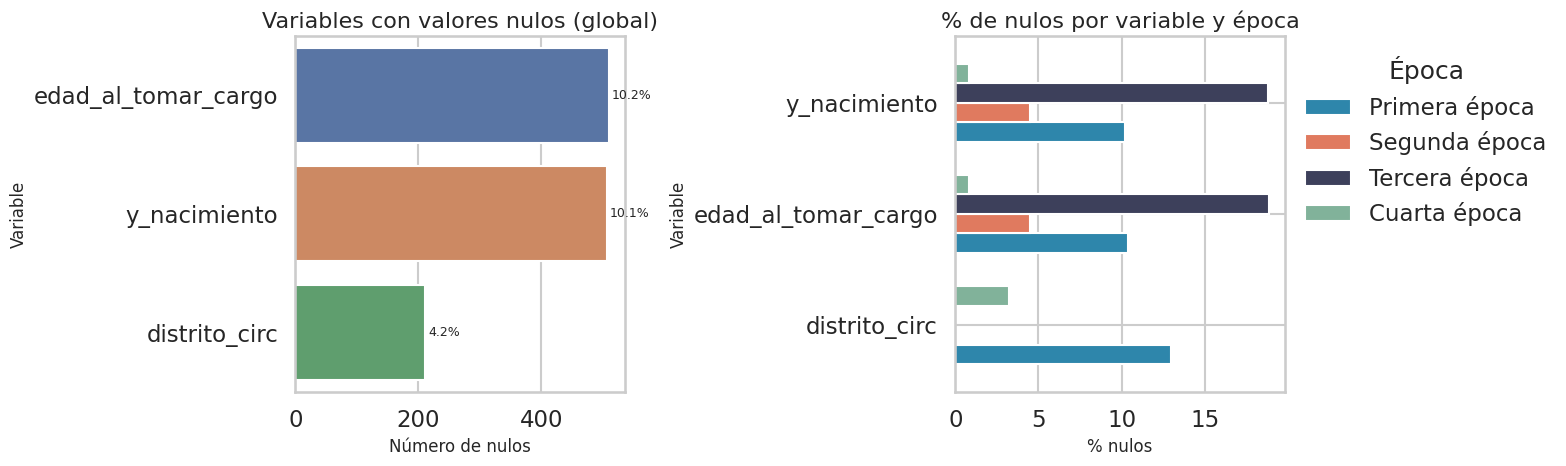

In [4]:
missing = (
    df.isna()
    .sum()
    .rename('nulos')
    .reset_index()
    .rename(columns={'index': 'variable'})
)
missing['pct'] = 100 * missing['nulos'] / len(df)
missing = missing[missing['nulos'] > 0].sort_values('nulos', ascending=False)
display(missing)

# % nulos por variable y época
vars_nulos = missing['variable'].tolist()
era_miss_rows = []
for era_name in era_nombre_order:
    sub = plot_df[plot_df['era_label'] == era_name]
    for var in vars_nulos:
        era_miss_rows.append({
            'era_label': era_name,
            'variable': var,
            'pct_nulos': 100 * sub[var].isna().sum() / len(sub),
        })
era_miss_df = pd.DataFrame(era_miss_rows)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
sns.barplot(data=missing, x='nulos', y='variable', hue='variable',
            dodge=False, ax=ax, legend=False)
ax.set_title('Variables con valores nulos (global)')
ax.set_xlabel('Número de nulos')
ax.set_ylabel('Variable')
for i, row in missing.reset_index(drop=True).iterrows():
    ax.text(row['nulos'] + 5, i, f"{row['pct']:.1f}%", va='center', fontsize=9)

ax2 = axes[1]
piv_miss = era_miss_df.pivot(index='variable', columns='era_label', values='pct_nulos')[era_nombre_order]
piv_miss.plot.barh(ax=ax2, color=list(era_colors.values()), edgecolor='white', width=0.7)
ax2.set_title('% de nulos por variable y época')
ax2.set_xlabel('% nulos')
ax2.set_ylabel('Variable')
ax2.legend(title='Época', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()


**Interpretación — Variables con datos nulos por época**

Solo tres variables presentan valores faltantes: `edad_al_tomar_cargo` (10.2 %), `y_nacimiento` (10.1 %) y `distrito_circ` (4.2 %). La gráfica por épocas revela que el patrón es heterogéneo: la **Tercera época** concentra el mayor porcentaje de nulos en `y_nacimiento` (≈18.8 %), reflejo de inconsistencias del SIL durante la migración de plataforma en las legislaturas LXIII–LXV. La **Cuarta época** (LXVI) tiene la mejor cobertura en esa variable (0.8 %). La desagregación por era permite tratar los nulos de forma localizada en el modelado en lugar de imputar con un promedio global.


#### 2.2.2 Composición partidista por legislatura

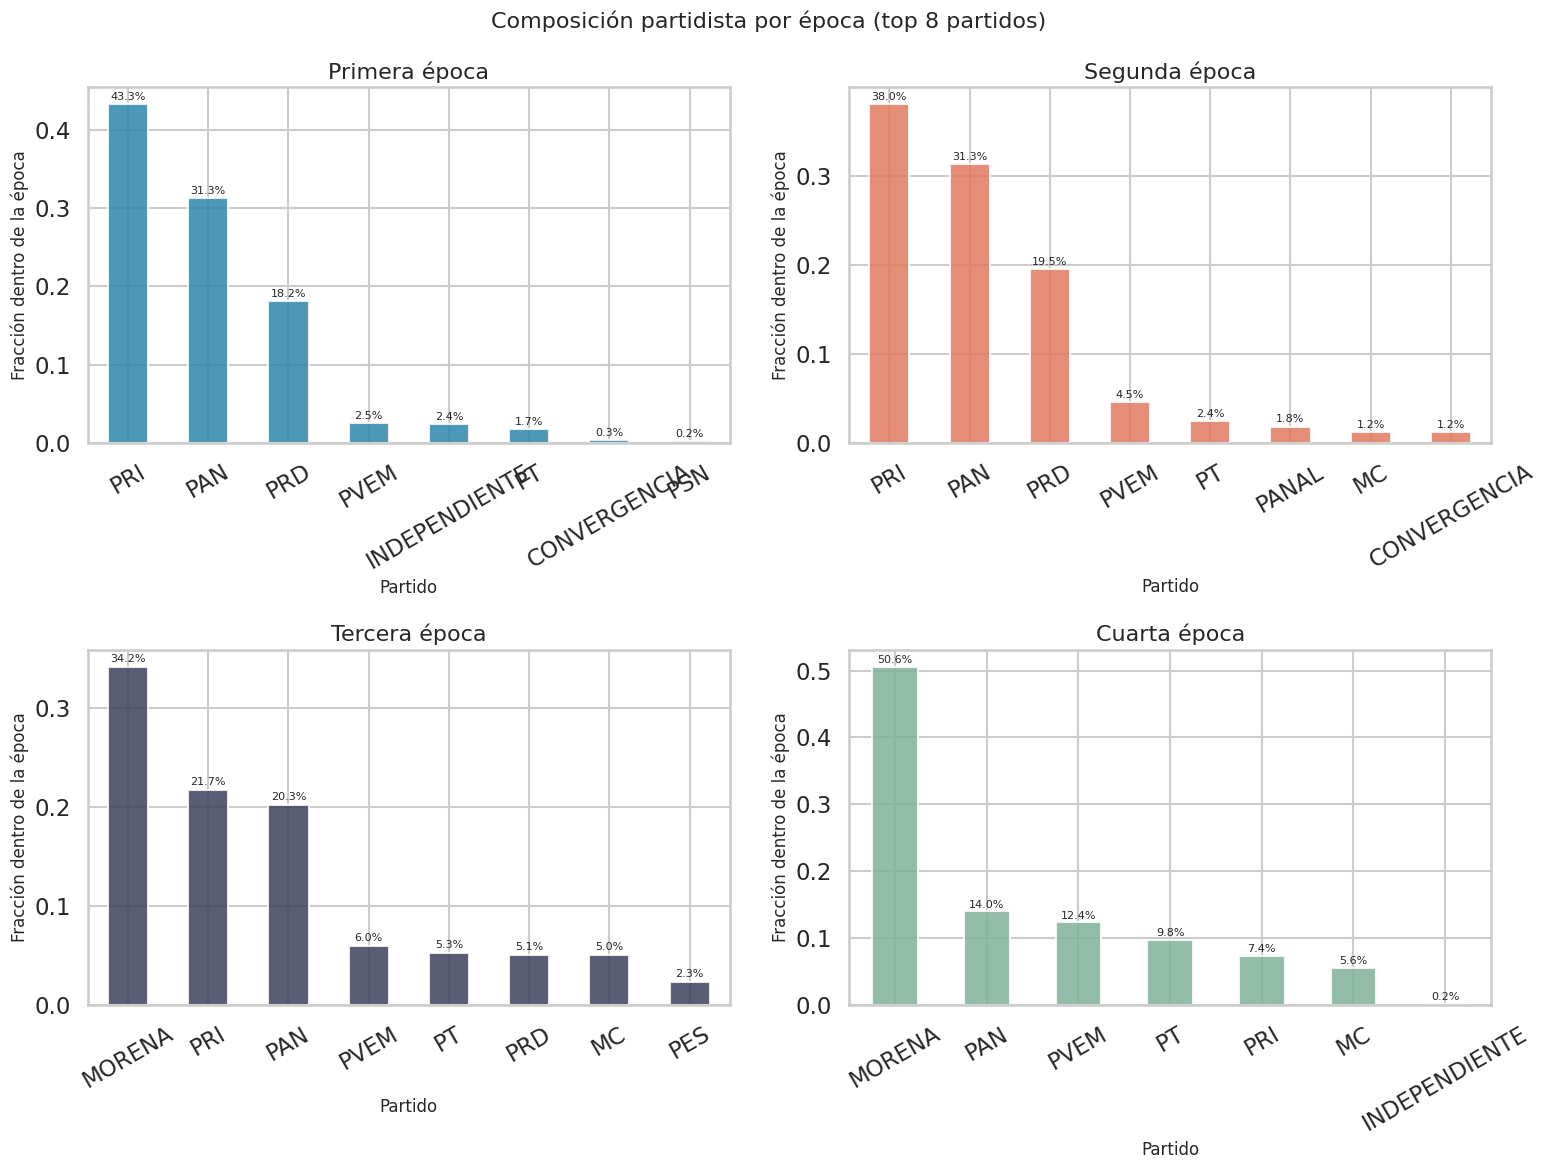

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, era_name in zip(axes, era_nombre_order):
    sub = plot_df[plot_df['era_label'] == era_name]
    top_parties = sub['partido'].value_counts().head(8).index.tolist()
    counts = sub[sub['partido'].isin(top_parties)]['partido'].value_counts()
    pct = counts / counts.sum()

    pct.plot.bar(ax=ax, color=era_colors[era_name], edgecolor='white', alpha=0.85)
    ax.set_title(era_name)
    ax.set_xlabel('Partido')
    ax.set_ylabel('Fracción dentro de la época')
    ax.tick_params(axis='x', rotation=30)
    for j, (_, val) in enumerate(pct.items()):
        ax.text(j, val + 0.005, f"{val:.1%}", ha='center', fontsize=8)

fig.suptitle('Composición partidista por época (top 8 partidos)', fontsize=16)
plt.tight_layout()
plt.show()


**Interpretación — Composición partidista por época**

Las cuatro gráficas muestran el peso relativo de los principales partidos dentro de cada era:

- **Primera época (LVII–LIX):** el PRI domina pero sin mayoría absoluta; el PAN y PRD consolidan la primera alternancia real desde 1929.
- **Segunda época (LX–LXII):** bipartidismo funcional PAN–PRI, con el PRD como tercera fuerza y surgimiento de partidos satélite.
- **Tercera época (LXIII–LXV):** ascenso acelerado de Morena desde posición minoritaria (LXIII) hasta mayoría calificada (LXIV–LXV); fragmentación de la oposición.
- **Cuarta época (LXVI):** supermayoría de Morena y aliados; el bloque opositor (PAN, PRI, PRD) queda reducido a una fracción marginal.

La segmentación por era hace visible la ruptura estructural que sería invisible en un gráfico de legislatura individual.


#### 2.2.3 Perfil demográfico de diputados

,n,media,DE,min,p25,mediana,p75,max
era_label,,,,,,,,
Primera época,1344.0,44.82,9.73,21.0,38.0,45.0,51.0,77.0
Segunda época,1433.0,45.76,10.07,21.0,39.0,46.0,53.0,84.0
Tercera época,1217.0,47.37,11.03,22.0,39.0,47.0,55.0,85.0
Cuarta época,496.0,48.37,11.24,21.0,40.0,48.0,57.0,79.0


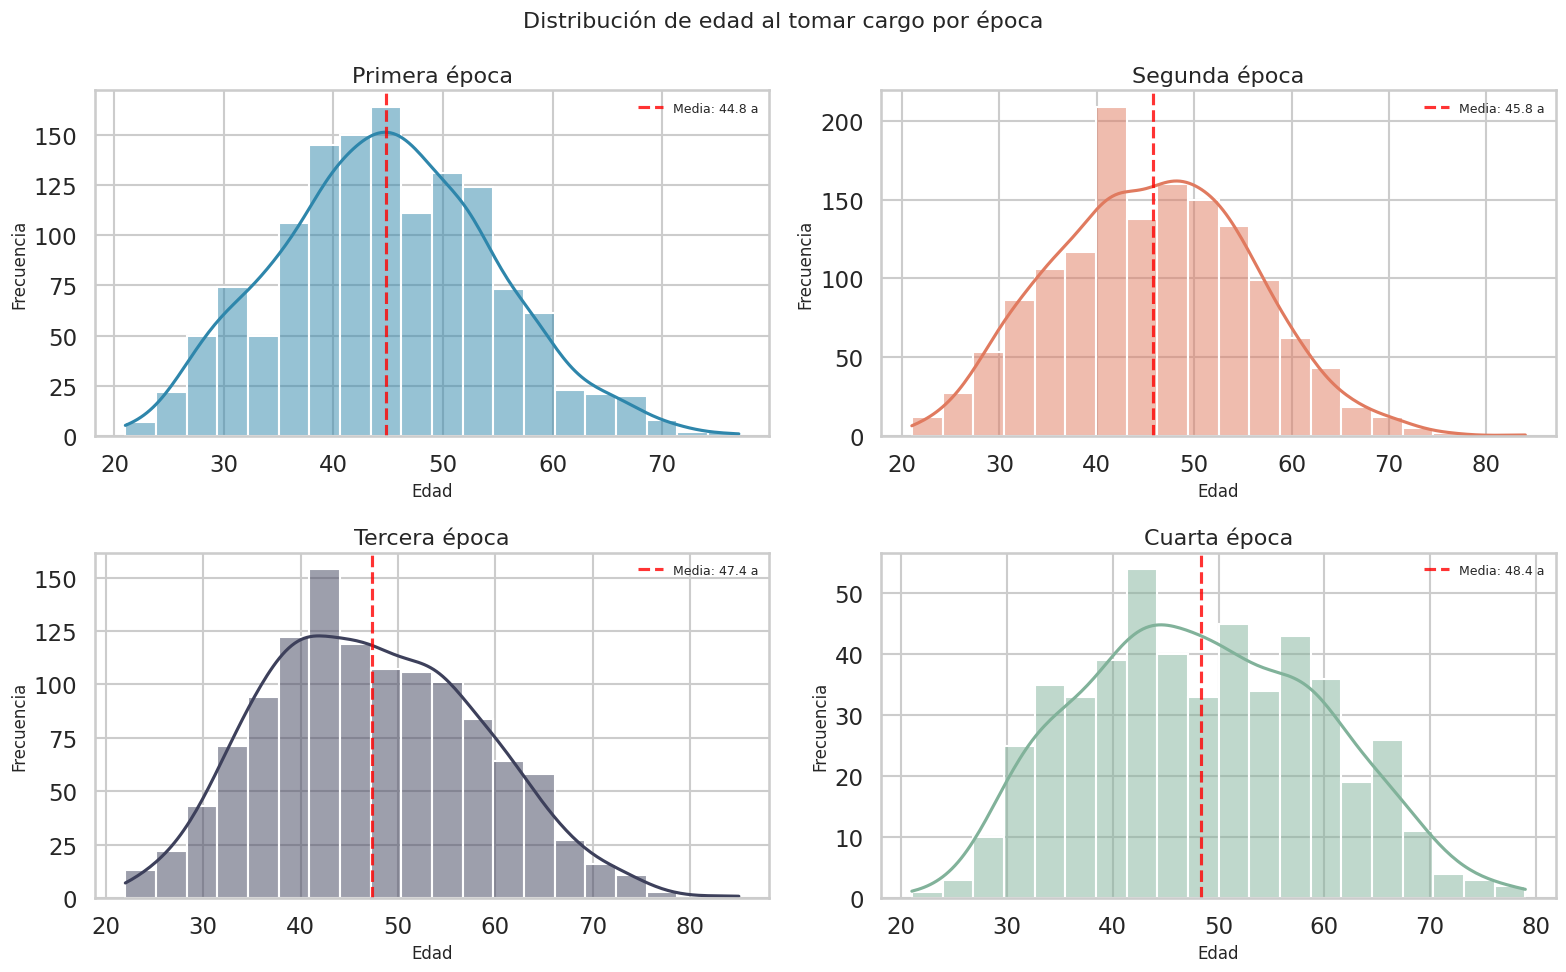

In [6]:
stats_rows = []
for era_name in era_nombre_order:
    sub = plot_df[plot_df['era_label'] == era_name]['edad_al_tomar_cargo'].dropna()
    s = sub.describe()
    stats_rows.append({'era_label': era_name, 'n': s['count'], 'media': s['mean'],
                       'DE': s['std'], 'min': s['min'], 'p25': s['25%'],
                       'mediana': s['50%'], 'p75': s['75%'], 'max': s['max']})
display(pd.DataFrame(stats_rows).set_index('era_label').round(2))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, era_name in zip(axes.flatten(), era_nombre_order):
    sub = plot_df[plot_df['era_label'] == era_name]['edad_al_tomar_cargo'].dropna()
    sns.histplot(sub, bins=20, kde=True, ax=ax, color=era_colors[era_name])
    ax.axvline(sub.mean(), color='red', linestyle='--', alpha=0.8,
               label=f'Media: {sub.mean():.1f} a')
    ax.set_title(era_name)
    ax.set_xlabel('Edad')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9)

fig.suptitle('Distribución de edad al tomar cargo por época', fontsize=16)
plt.tight_layout()
plt.show()


**Interpretación — Distribución de edades por época**

La distribución de edades es aproximadamente normal en todas las épocas, con un desplazamiento sostenido hacia la derecha conforme avanzan las eras:

- **Primera época:** media ≈ 44.8 años; distribución más joven y dispersa.
- **Segunda época:** media ≈ 45.8 años; perfil más compacto, coherente con bipartidismo estabilizado.
- **Tercera época:** media ≈ 47.4 años; el efecto de la reelección consecutiva (desde LXIV) empieza a elevar la edad promedio al mantener en funciones a legisladores de mayor edad.
- **Cuarta época:** media ≈ 48.4 años; la mayor en el periodo, reflejo combinado de la reelección y el perfil etario de la bancada de Morena.

El envejecimiento progresivo del cuerpo legislativo es estadísticamente visible cuando se desagrega por era, mientras que la serie global esconde la discontinuidad post-2018.


,legislatura_roman,era_label,edad_al_tomar_cargo
0,LVII,Primera época,45.83
1,LVIII,Primera época,44.22
2,LIX,Primera época,44.58
3,LX,Segunda época,44.88
4,LXI,Segunda época,46.02
5,LXII,Segunda época,46.42
6,LXIII,Tercera época,46.01
7,LXIV,Tercera época,48.29
8,LXV,Tercera época,47.66
9,LXVI,Cuarta época,48.37


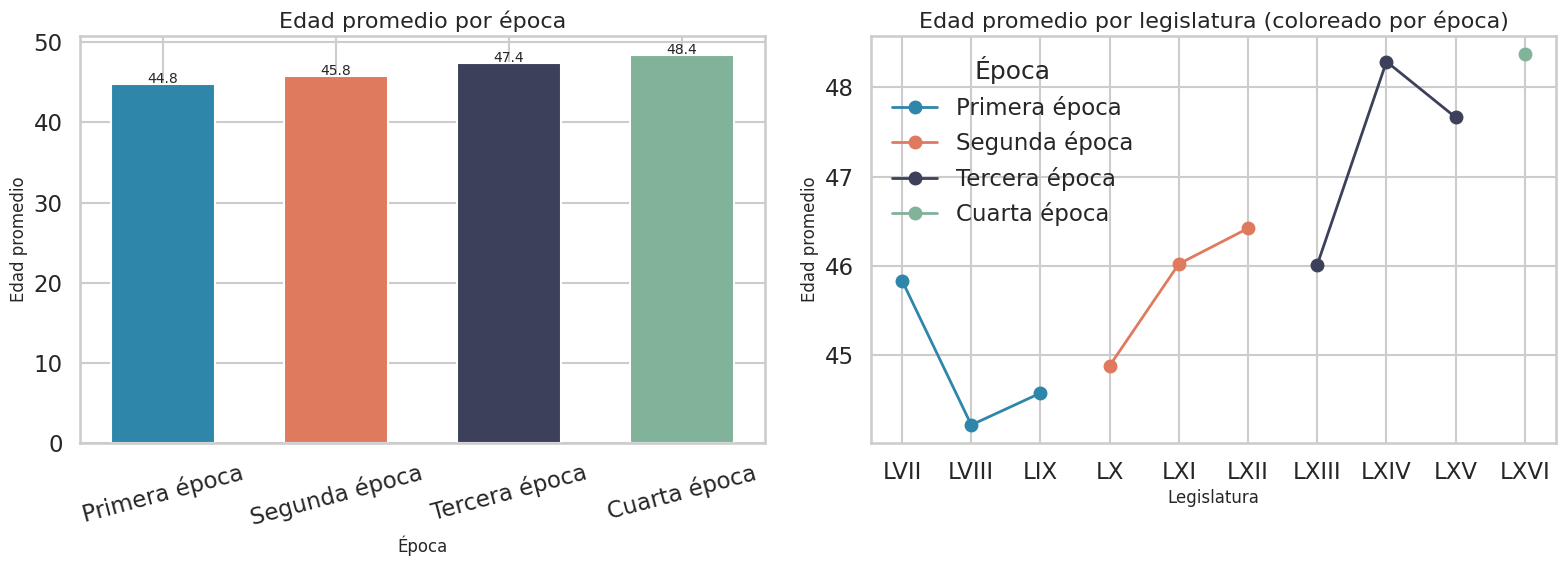

In [7]:
avg_age_era = (
    plot_df.groupby('era_label')['edad_al_tomar_cargo']
    .mean()
    .reset_index()
    .rename(columns={'edad_al_tomar_cargo': 'edad_promedio'})
)

avg_age_leg = (
    plot_df.groupby(['legislatura_num', 'legislatura_roman', 'era_label'])['edad_al_tomar_cargo']
    .mean()
    .reset_index()
    .sort_values('legislatura_num')
)

display(avg_age_leg[['legislatura_roman', 'era_label', 'edad_al_tomar_cargo']].round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
bar_colors = [era_colors[e] for e in era_nombre_order]
ax.bar(era_nombre_order, avg_age_era['edad_promedio'], color=bar_colors, edgecolor='white', width=0.6)
ax.set_title('Edad promedio por época')
ax.set_xlabel('Época')
ax.set_ylabel('Edad promedio')
ax.tick_params(axis='x', rotation=15)
for i, row in avg_age_era.iterrows():
    ax.text(i, row['edad_promedio'] + 0.1, f"{row['edad_promedio']:.1f}", ha='center', fontsize=10)

ax2 = axes[1]
for era_name in era_nombre_order:
    grp = avg_age_leg[avg_age_leg['era_label'] == era_name].sort_values('legislatura_num')
    ax2.plot(grp['legislatura_roman'], grp['edad_al_tomar_cargo'],
             marker='o', label=era_name, color=era_colors[era_name], linewidth=2)
ax2.set_title('Edad promedio por legislatura (coloreado por época)')
ax2.set_xlabel('Legislatura')
ax2.set_ylabel('Edad promedio')
ax2.legend(title='Época')

plt.tight_layout()
plt.show()


**Interpretación — Edad promedio por época**

La gráfica de barras confirma el envejecimiento gradual del cuerpo legislativo: de 44.8 años en la Primera época a 48.4 en la Cuarta. La línea por legislatura (coloreada por era) permite además identificar la variabilidad intra-era: las legislaturas LXIV y LXV muestran el mayor salto, coincidiendo con la entrada en vigor de la reelección consecutiva (reforma 2014, efectiva desde 2018) que retiene en cámara a legisladores con carreras más largas. La tendencia ascendente es monotónica entre épocas, lo que sugiere un factor estructural y no aleatorio.


#### 2.2.4 Perfil educativo de diputados

era_label,Primera época,Segunda época,Tercera época,Cuarta época
etiqueta,,,,
Doctorado,2.47,3.93,5.07,6.2
Especialidad,NaN,NaN,NaN,0.2
Lic. incompleta,6.00,8.00,6.20,4.2
Licenciatura,40.33,49.93,47.53,53.6
Preparatoria,3.13,2.80,1.07,0.6
Primaria,0.60,1.20,1.73,1.8
Secundaria,1.33,2.60,3.73,2.6
Sin dato,46.13,31.53,34.67,30.8


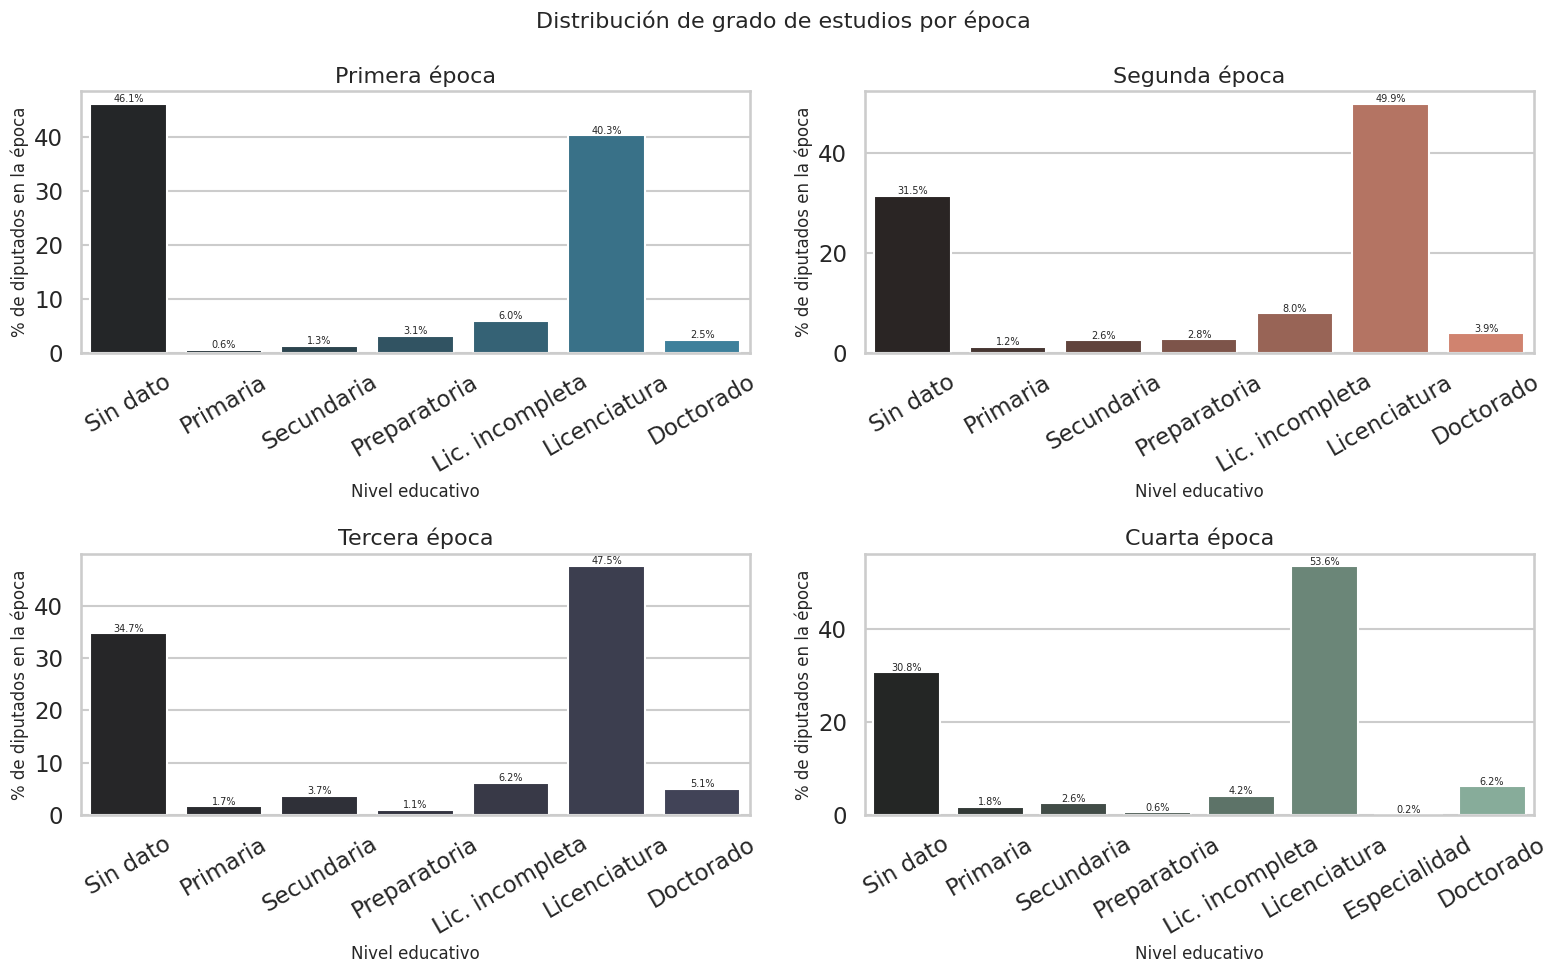

In [8]:
grade_labels = {
    -1: 'Sin dato', 0: 'Sin dato', 1: 'Primaria', 2: 'Secundaria',
    4: 'Preparatoria', 5: 'Lic. incompleta',
    6: 'Licenciatura', 7: 'Especialidad', 9: 'Doctorado',
}

era_grade = []
for era_name in era_nombre_order:
    sub = plot_df[plot_df['era_label'] == era_name]
    gd = (sub['grado_estudios_ord'].fillna(-1).astype(int)
          .value_counts().rename_axis('grado').reset_index(name='n'))
    gd['etiqueta'] = gd['grado'].map(grade_labels).fillna('Otro')
    gd['pct'] = 100 * gd['n'] / len(sub)
    gd['era_label'] = era_name
    era_grade.append(gd)

all_grade = pd.concat(era_grade, ignore_index=True)
display(all_grade.pivot_table(index='etiqueta', columns='era_label',
                              values='pct', aggfunc='sum')[era_nombre_order].round(2))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, era_name in zip(axes.flatten(), era_nombre_order):
    sub_g = all_grade[all_grade['era_label'] == era_name].sort_values('grado')
    sns.barplot(data=sub_g, x='etiqueta', y='pct', hue='etiqueta',
                dodge=False, ax=ax, legend=False,
                palette=f"dark:{era_colors[era_name]}")
    ax.set_title(era_name)
    ax.set_xlabel('Nivel educativo')
    ax.set_ylabel('% de diputados en la época')
    ax.tick_params(axis='x', rotation=30)
    for j, row in sub_g.reset_index(drop=True).iterrows():
        ax.text(j, row['pct'] + 0.3, f"{row['pct']:.1f}%", ha='center', fontsize=7)

fig.suptitle('Distribución de grado de estudios por época', fontsize=16)
plt.tight_layout()
plt.show()


**Interpretación — Distribución de grado de estudios por época**

La comparación entre épocas revela una mejora progresiva en el nivel educativo declarado:

- **Primera época:** el porcentaje sin dato supera el 40 %; entre quienes tienen registro, predomina la preparatoria y licenciatura incompleta.
- **Segunda época:** crece la proporción con licenciatura completa y especialidad; se reduce la categoría sin dato.
- **Tercera época:** la licenciatura se consolida como nivel modal; aparece mayor proporción de posgrados.
- **Cuarta época:** el perfil educativo más homogéneo del periodo; la licenciatura domina con claridad.

La anomalía conocida de la LIX (bajo promedio ordinal) se concentra en la Primera época y no contamina las eras posteriores. La comparación por era permite detectar que la mejora educativa es gradual y real, no un artefacto de la calidad de datos.


#### 2.2.5 Perfil educativo de diputados

,partido,promedio,n,era
6,PRI,3.404321,648,Primera época
3,PAN,3.038380,469,Primera época
8,PT,3.000000,26,Primera época
5,PRD,2.827206,272,Primera época
9,PVEM,2.710526,38,Primera época


,partido,promedio,n,era
2,MC,5.000000,18,Segunda época
5,PANAL,4.777778,27,Segunda época
0,CONVERGENCIA,4.500000,18,Segunda época
9,PT,4.333333,36,Segunda época
4,PAN,3.960954,461,Segunda época


,partido,promedio,n,era
6,PRD,4.426667,75,Tercera época
10,SIN PARTIDO,4.176471,17,Tercera época
1,MC,4.135135,74,Tercera época
9,PVEM,4.079545,88,Tercera época
8,PT,4.064103,78,Tercera época


,partido,promedio,n,era
5,PT,4.530612,49,Cuarta época
2,MORENA,4.383399,253,Cuarta época
6,PVEM,3.887097,62,Cuarta época
3,PAN,3.714286,70,Cuarta época
4,PRI,3.459459,37,Cuarta época


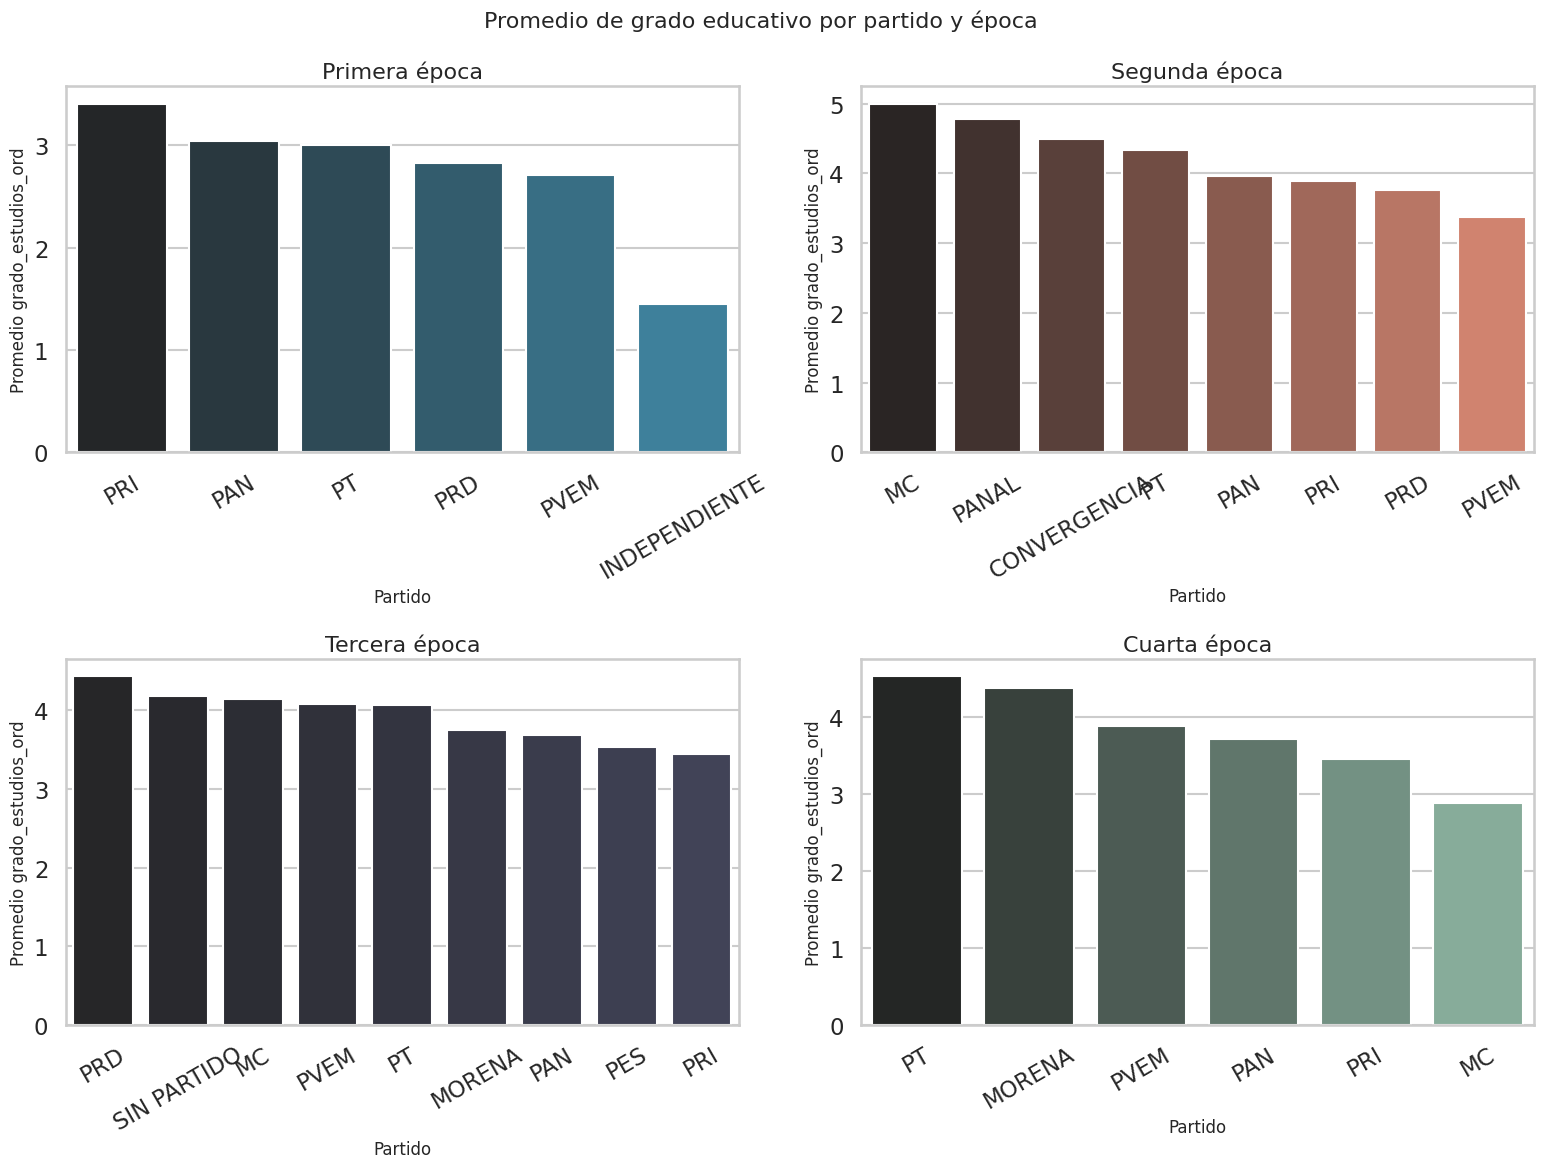

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, era_name in zip(axes.flatten(), era_nombre_order):
    sub = plot_df[plot_df['era_label'] == era_name]
    edu_p = (sub.groupby('partido')['grado_estudios_ord']
             .agg(promedio='mean', n='size')
             .reset_index()
             .query('n >= 15')
             .sort_values('promedio', ascending=False))
    display(edu_p.assign(era=era_name).head(5))
    sns.barplot(data=edu_p, x='partido', y='promedio', hue='partido',
                dodge=False, ax=ax, legend=False,
                palette=f"dark:{era_colors[era_name]}")
    ax.set_title(era_name)
    ax.set_xlabel('Partido')
    ax.set_ylabel('Promedio grado_estudios_ord')
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Promedio de grado educativo por partido y época', fontsize=16)
plt.tight_layout()
plt.show()


**Interpretación — Grado de estudios promedio por partido y época**

El ranking educativo por partido cambia entre épocas:

- **Primera época (PRI dominante):** los partidos de oposición (PAN, PRD) muestran promedios ligeramente superiores al PRI; el PANAL y PT tienen valores bajos.
- **Segunda época (PAN):** el PAN encabeza el ranking, coherente con su perfil tecnocrático-universitario; el PRI se mantiene en niveles medios.
- **Tercera época (transición):** Morena entra con promedios competitivos; los partidos satélite pequeños tienen alta variabilidad por tamaño de muestra reducido.
- **Cuarta época (Morena):** Morena y sus aliados muestran promedios similares a los del PRI histórico; la oposición residual (PAN, PRI, PRD) conserva promedios ligeramente superiores.

La comparación por era evita el sesgo que produce agregar partidos de épocas distintas con composiciones de muestra incomparables.


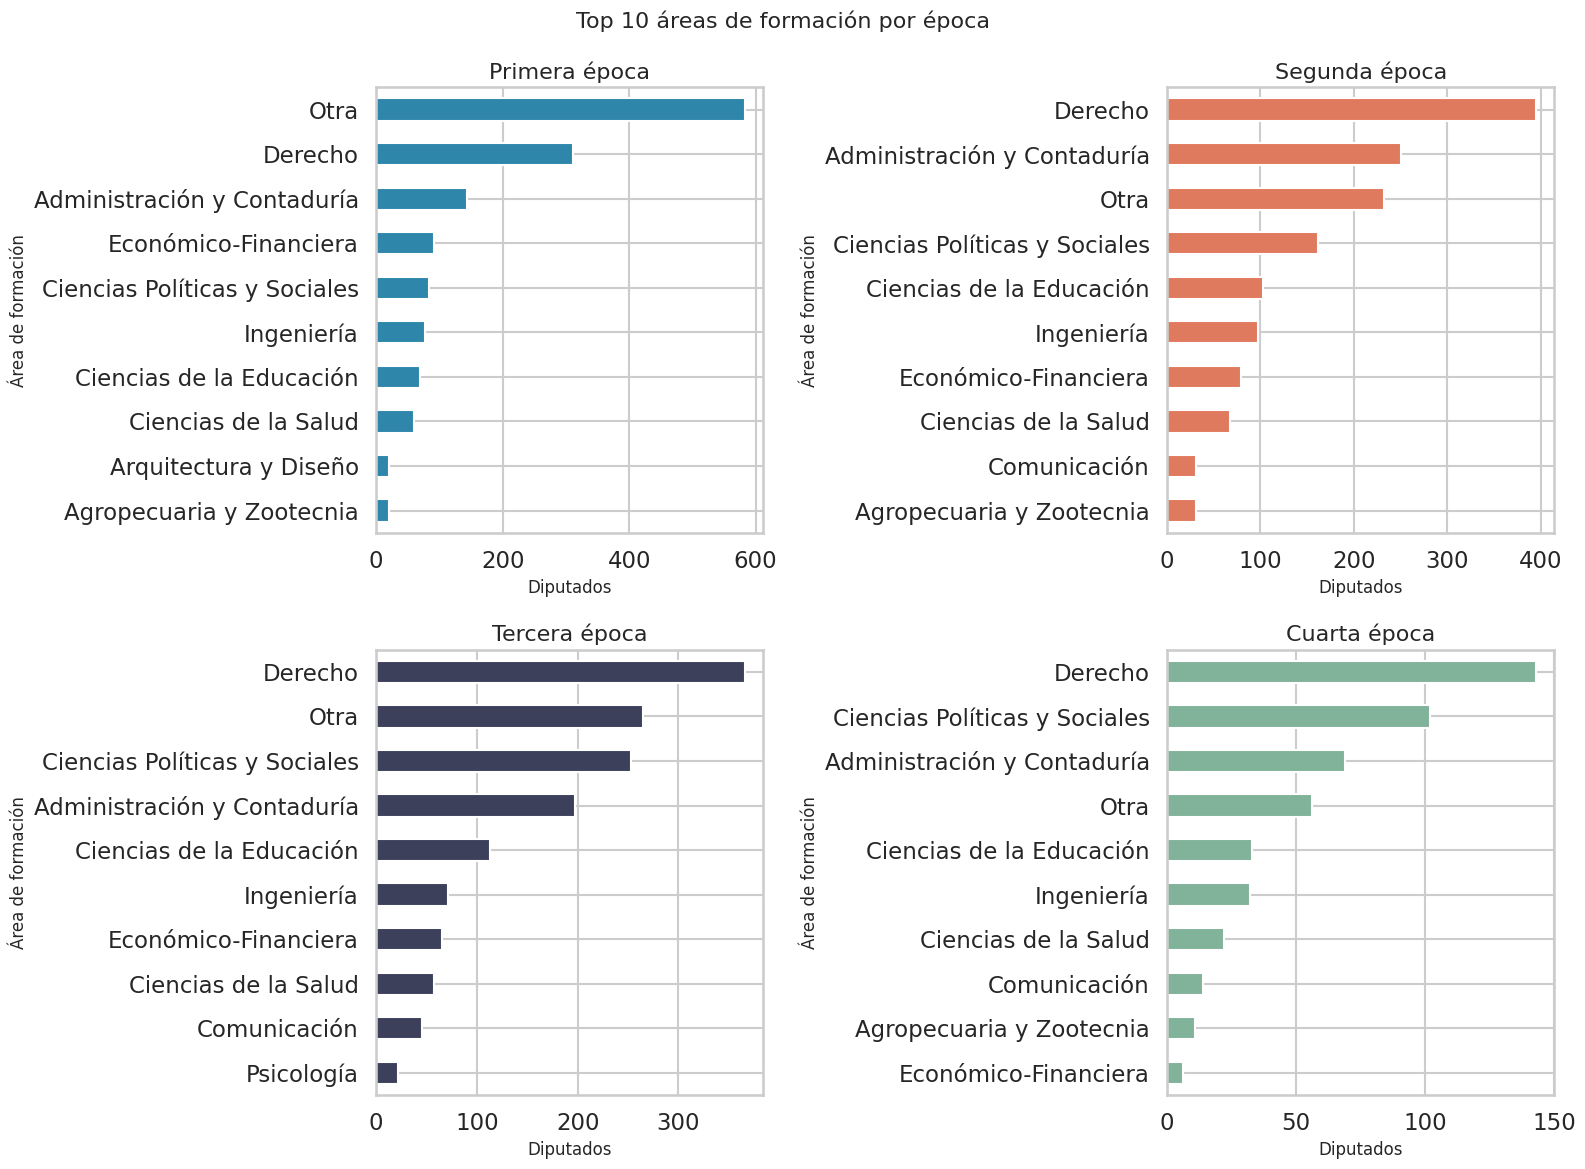

In [10]:
if 'area_formacion' in df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    for ax, era_name in zip(axes.flatten(), era_nombre_order):
        sub = plot_df[plot_df['era_label'] == era_name]
        af = sub['area_formacion'].value_counts().head(10)
        af.plot.barh(ax=ax, color=era_colors[era_name], edgecolor='white')
        ax.invert_yaxis()
        ax.set_title(era_name)
        ax.set_xlabel('Diputados')
        ax.set_ylabel('Área de formación')
    fig.suptitle('Top 10 áreas de formación por época', fontsize=16)
    plt.tight_layout()
    plt.show()


**Interpretación — Área de formación por época**

El Derecho domina en todas las épocas, pero su peso relativo disminuye levemente en la Tercera y Cuarta épocas, donde crecen las áreas de Ciencias Políticas/Administración Pública y Economía/Administración. Esto es consistente con la entrada de cuadros de Morena formados en administración pública y movimientos sociales más que en el litigio jurídico tradicional. La Ingeniería mantiene presencia baja pero estable. La Medicina aparece con mayor frecuencia en la Segunda época (PAN), coincidiendo con el perfil tecnocrático de ese partido. La comparación por era revela que el perfil formativo de la clase legislativa no es estático sino que refleja la cultura organizacional del partido dominante en cada periodo.


,Pública,Privada,Extranjera,Sin info
era_label,,,,
Primera época,53.67,23.27,10.27,34.2
Segunda época,40.33,21.73,8.13,45.6
Tercera época,40.93,21.53,6.73,44.0
Cuarta época,33.40,23.60,5.80,46.6


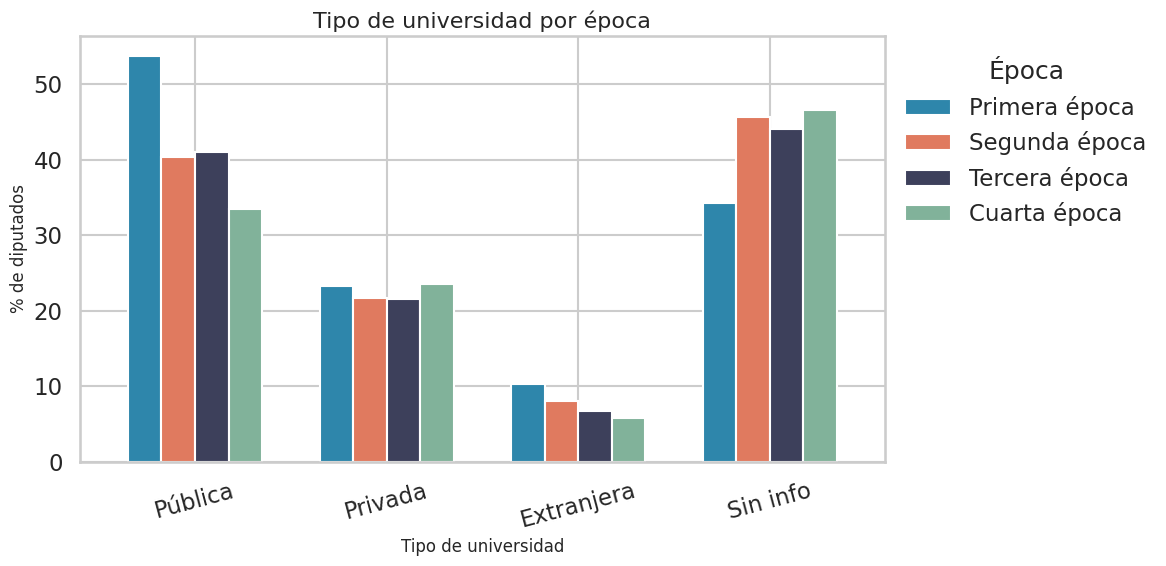

In [11]:
era_univ = []
for era_name in era_nombre_order:
    sub = plot_df[plot_df['era_label'] == era_name]
    n = len(sub)
    no_univ = (1 - sub[['univ_publica', 'univ_privada', 'univ_extranjera']].max(axis=1)).sum()
    era_univ.append({
        'era_label': era_name,
        'Pública':    100 * sub['univ_publica'].sum() / n,
        'Privada':    100 * sub['univ_privada'].sum() / n,
        'Extranjera': 100 * sub['univ_extranjera'].sum() / n,
        'Sin info':   100 * no_univ / n,
    })
df_univ_era = pd.DataFrame(era_univ).set_index('era_label')
display(df_univ_era.round(2))

ax = df_univ_era.loc[era_nombre_order].T.plot.bar(
    figsize=(12, 6), color=list(era_colors.values()), edgecolor='white', width=0.7)
ax.set_title('Tipo de universidad por época')
ax.set_xlabel('Tipo de universidad')
ax.set_ylabel('% de diputados')
ax.legend(title='Época', bbox_to_anchor=(1, 1))
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()


**Interpretación — Tipo de universidad por época**

La universidad pública predomina en todas las épocas, pero su participación varía:

- **Primera época:** la mayor proporción de diputados sin universidad identificada, coherente con el alto porcentaje de nulos en escolaridad y el perfil populista del PRI.
- **Segunda época (PAN):** leve aumento de universidad privada y extranjera, reflejo del perfil tecnocrático-panista con estudios en el ITAM, ITESM y posgrados en el extranjero.
- **Tercera y Cuarta épocas:** la universidad pública (principalmente la UNAM) recupera terreno, consistente con el discurso de Morena sobre educación pública.

La tendencia a través de las eras muestra que la procedencia universitaria no es neutral: cambia con el partido dominante, lo cual tiene implicaciones para el perfil educativo como predictor de asignación a comisiones.


,UNAM,ITESM,ITAM,IBERO,UDG,IPN,UAM,ANAHUAC,UANL,UV
Primera época,0.2240,0.0627,0.044,0.0673,0.0353,0.0467,0.0293,0.0187,0.0233,0.0247
Segunda época,0.1233,0.0680,0.032,0.0533,0.0340,0.0280,0.0187,0.0273,0.0280,0.0173
Tercera época,0.0767,0.0487,0.020,0.0460,0.0293,0.0140,0.0180,0.0313,0.0280,0.0173
Cuarta época,0.0660,0.0300,0.018,0.0340,0.0260,0.0100,0.0240,0.0220,0.0360,0.0080


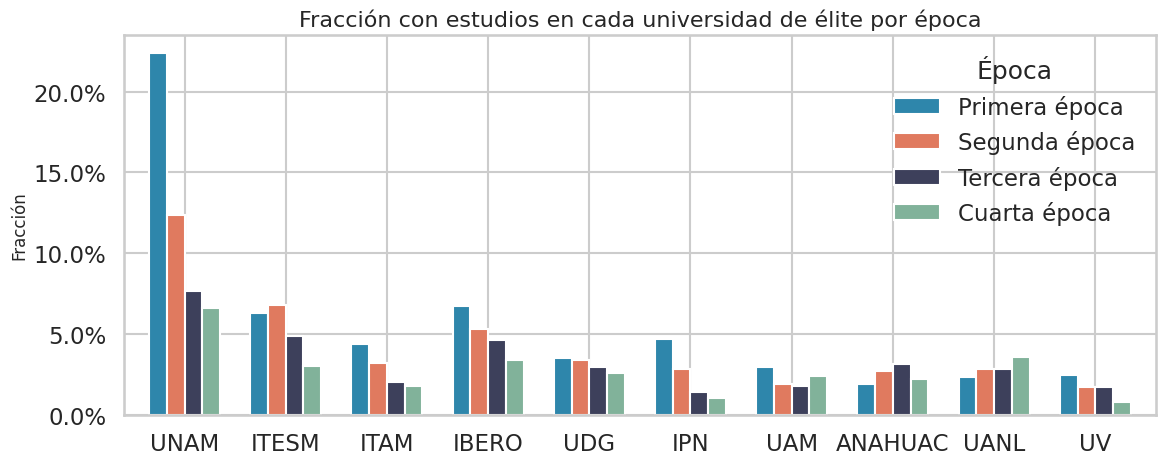

In [12]:
acad_cols = [c for c in df.columns if c.startswith('acad_')]
if acad_cols:
    era_acad_rows = []
    for era_name in era_nombre_order:
        sub = plot_df[plot_df['era_label'] == era_name]
        row = sub[acad_cols].mean().rename(era_name)
        row.index = row.index.str.replace('acad_', '', regex=False).str.upper()
        era_acad_rows.append(row)
    df_acad = pd.DataFrame(era_acad_rows)
    display(df_acad.round(4))

    ax = df_acad.T.plot.bar(
        figsize=(12, 5), color=list(era_colors.values()), edgecolor='white', width=0.7)
    ax.set_title('Fracción con estudios en cada universidad de élite por época')
    ax.set_ylabel('Fracción')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.legend(title='Época', bbox_to_anchor=(1, 1))
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


**Interpretación — Indicadores de universidad de élite por época**

La presencia de universidades de élite (UNAM, ITESM, ITAM) varía significativamente entre épocas:

- **Primera época:** la UNAM domina como institución de origen; el ITESM e ITAM tienen presencia mínima, coherente con el perfil populista del PRI hegemónico.
- **Segunda época:** el ITAM e ITESM alcanzan su mayor representación histórica; el PAN reclutó intensamente de redes tecnocráticas privadas durante sus dos sexenios.
- **Tercera y Cuarta épocas:** la UNAM recupera predominio; el ITAM e ITESM retroceden; la diversificación de instituciones de origen aumenta.

Este patrón por era es el que hace relevante al indicador `edu_calidad` en el modelo SHAP: su poder predictivo es alto en ERA_2 (PAN) y cae en ERA_4 (Morena), donde la afiliación política pesa más que la credencial universitaria específica.


#### 2.2.6 Perfil de experiencia previa de diputados

,fue_diputado_local,fue_diputado_federal,fue_senador
era_label,,,
Primera época,0.2080,0.1133,0.0247
Segunda época,0.3620,0.1647,0.0480
Tercera época,0.3127,0.2287,0.0513
Cuarta época,0.3640,0.3360,0.0860


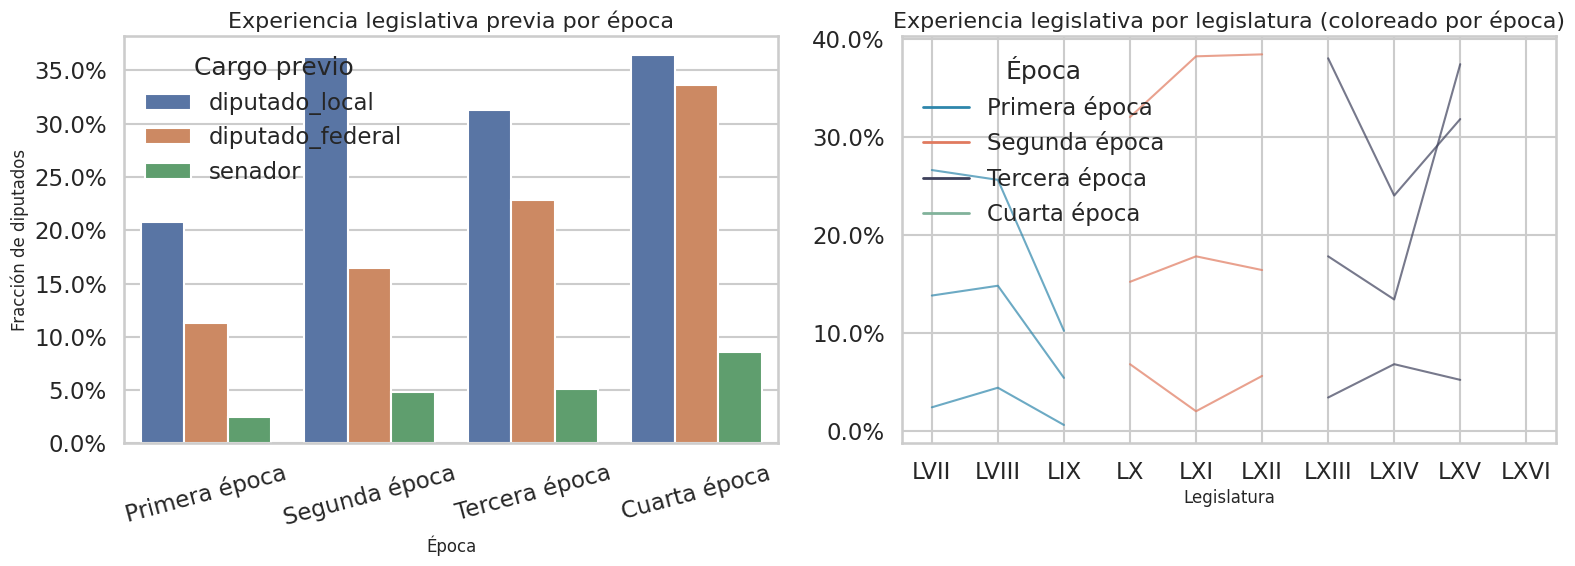

In [13]:
exp_cols = ['fue_diputado_local', 'fue_diputado_federal', 'fue_senador']
exp_cols = [c for c in exp_cols if c in df.columns]

if exp_cols:
    era_exp = plot_df.groupby('era_label')[exp_cols].mean().reset_index()
    display(era_exp.set_index('era_label').round(4))

    exp_long = era_exp.melt(id_vars='era_label', value_vars=exp_cols,
                            var_name='cargo', value_name='fraccion')
    exp_long['cargo'] = exp_long['cargo'].str.replace('fue_', '')

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    ax = axes[0]
    sns.barplot(data=exp_long, x='era_label', y='fraccion', hue='cargo',
                ax=ax, order=era_nombre_order)
    ax.set_title('Experiencia legislativa previa por época')
    ax.set_xlabel('Época')
    ax.set_ylabel('Fracción de diputados')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.tick_params(axis='x', rotation=15)
    ax.legend(title='Cargo previo')

    ax2 = axes[1]
    exp_by_leg = (plot_df
                  .groupby(['legislatura_num', 'legislatura_roman', 'era_label'])[exp_cols]
                  .mean()
                  .reset_index()
                  .sort_values('legislatura_num'))
    for era_name in era_nombre_order:
        grp = exp_by_leg[exp_by_leg['era_label'] == era_name]
        for col in exp_cols:
            ax2.plot(grp['legislatura_roman'], grp[col],
                     color=era_colors[era_name], alpha=0.7, linewidth=1.5)
    for era_name in era_nombre_order:
        ax2.plot([], [], color=era_colors[era_name], label=era_name, linewidth=2)
    ax2.set_title('Experiencia legislativa por legislatura (coloreado por época)')
    ax2.set_xlabel('Legislatura')
    ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax2.legend(title='Época')

    plt.tight_layout()
    plt.show()


**Interpretación — Experiencia legislativa previa por época**

El patrón varía estructuralmente entre épocas:

- **Primera época:** la fracción de ex diputados locales y ex diputados federales es moderada; la prohibición de reelección consecutiva vigente desde 1933 limita la acumulación de mandatos federales consecutivos.
- **Segunda época:** el perfil es similar; el bipartidismo PAN–PRI favorece la circulación de cuadros entre niveles de gobierno.
- **Tercera época:** salta la proporción de diputados con mandato federal previo a partir de la LXIV (primer legislatura con reelección consecutiva activa). El incremento es visible en la gráfica de legislaturas.
- **Cuarta época:** la reelección consolida su efecto; la fracción con cargos legislativos previos alcanza su máximo histórico, transformando cualitativamente el perfil de la cámara.

La comparación por era hace evidente que la reforma de 2014 produjo una discontinuidad real, no solo incremental.


/tmp/ipykernel_4493/3155481654.py:17: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#2E86AB'` for the same effect.

  sns.barplot(data=sub, x='cargo', y='fraccion', hue='cargo',
/tmp/ipykernel_4493/3155481654.py:17: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#E07A5F'` for the same effect.

  sns.barplot(data=sub, x='cargo', y='fraccion', hue='cargo',
/tmp/ipykernel_4493/3155481654.py:17: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#3D405B'` for the same effect.

  sns.barplot(data=sub, x='cargo', y='fraccion', hue='cargo',
/tmp/ipykernel_4493/3155481654.py:17: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#81B29A'` for the same effect.

  sns.barplot(data=sub, x='cargo', y='fraccion

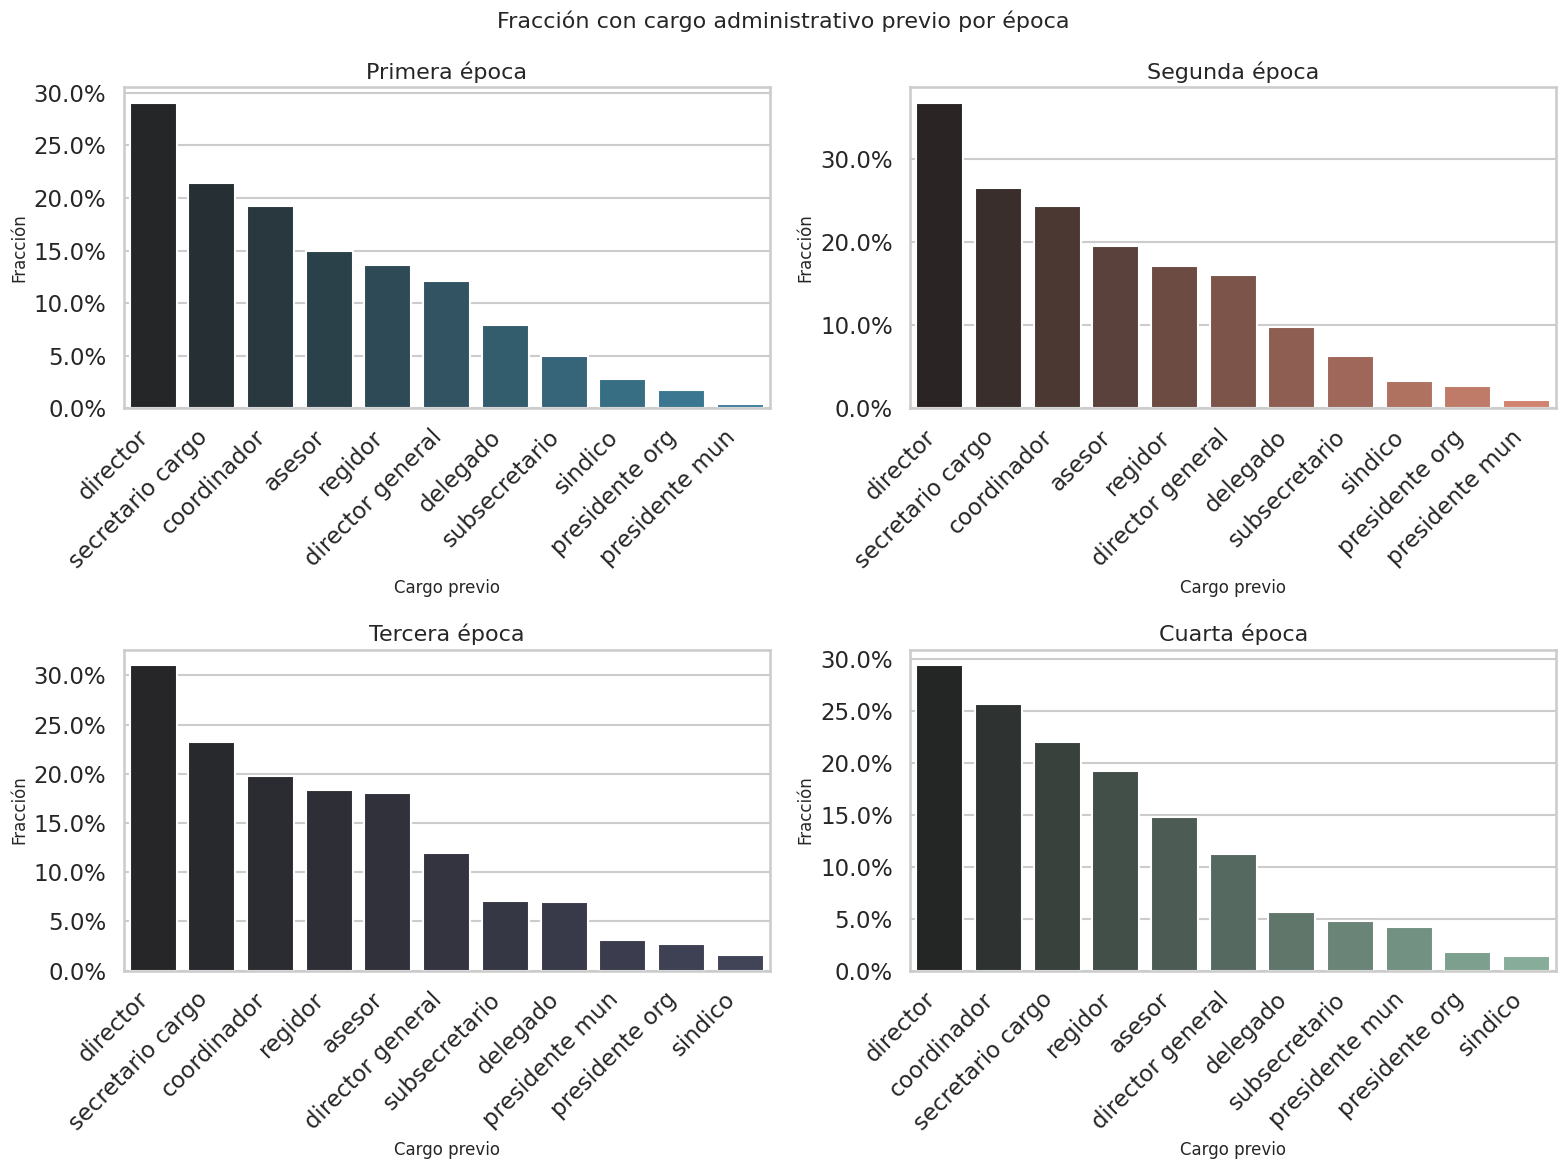

In [14]:
admin_cols = [
    'fue_presidente_mun', 'fue_presidente_org', 'fue_director_general',
    'fue_secretario_cargo', 'fue_subsecretario', 'fue_director',
    'fue_coordinador', 'fue_delegado', 'fue_asesor', 'fue_regidor', 'fue_sindico',
]
admin_cols = [c for c in admin_cols if c in df.columns]

era_admin = plot_df.groupby('era_label')[admin_cols].mean().reset_index()
admin_long = era_admin.melt(id_vars='era_label', value_vars=admin_cols,
                            var_name='cargo', value_name='fraccion')
admin_long['cargo'] = admin_long['cargo'].str.replace('fue_', '').str.replace('_', ' ')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, era_name in zip(axes.flatten(), era_nombre_order):
    sub = (admin_long[admin_long['era_label'] == era_name]
           .sort_values('fraccion', ascending=False))
    sns.barplot(data=sub, x='cargo', y='fraccion', hue='cargo',
                dodge=False, ax=ax, legend=False, color=era_colors[era_name])
    ax.set_title(era_name)
    ax.set_xlabel('Cargo previo')
    ax.set_ylabel('Fracción')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.tick_params(axis='x', rotation=45)
    for label in ax.get_xticklabels():
        label.set_ha('right')

fig.suptitle('Fracción con cargo administrativo previo por época', fontsize=16)
plt.tight_layout()
plt.show()


**Interpretación — Experiencia administrativa previa por época**

La presidencia municipal es el cargo ejecutivo previo más frecuente en todas las épocas, pero su peso relativo y el de otros cargos cambia:

- **Primera época:** la presidencia municipal y los cargos de dirección en organizaciones (sindicatos, cámaras) son dominantes, reflejando la estructura corporativa del PRI.
- **Segunda época:** crece la fracción de ex secretarios y subsecretarios; el PAN reclutó más intensamente de la burocracia federal tecnocrática.
- **Tercera época:** se mantiene la presidencia municipal como vía principal; Morena construye desde gobiernos locales y movimientos sociales.
- **Cuarta época:** la fracción con cargos de dirección general y secretarías cae ligeramente; se diversifica el origen administrativo.

Este patrón es consistente con los hallazgos SHAP: `n_trayectoria_admin` es el predictor más potente de comisiones nodales en ERA_1 y ERA_2, y pierde peso en ERA_3 y ERA_4.


,n_trayectoria_admin,n_trayectoria_politica,n_trayectoria_legislativa,n_trayectoria_empresarial
era_label,,,,
Primera época,2.957,7.380,0.679,1.570
Segunda época,3.519,6.742,0.801,1.903
Tercera época,3.055,4.790,0.816,1.509
Cuarta época,3.060,4.480,1.148,1.394


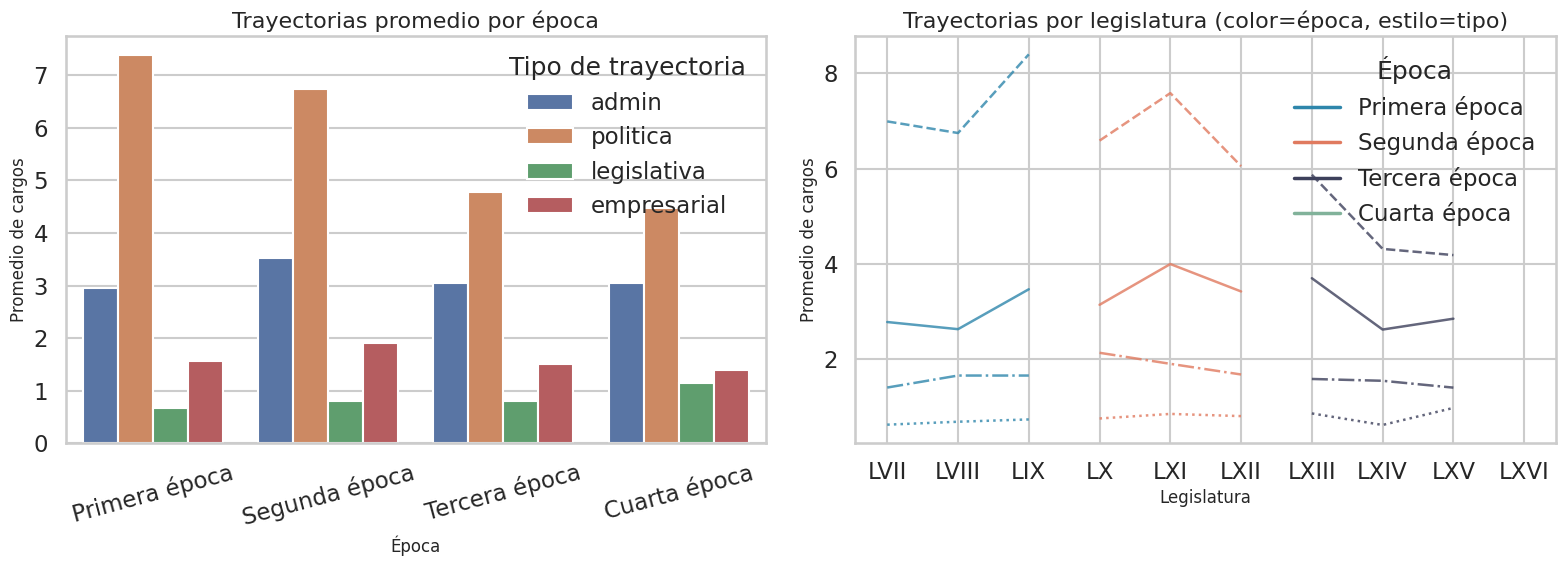

In [15]:
traj_vars = [
    'n_trayectoria_admin', 'n_trayectoria_politica',
    'n_trayectoria_legislativa', 'n_trayectoria_empresarial',
]
traj_vars = [c for c in traj_vars if c in df.columns]

era_traj = plot_df.groupby('era_label')[traj_vars].mean().reset_index()
display(era_traj.set_index('era_label').round(3))

traj_long = era_traj.melt(id_vars='era_label', value_vars=traj_vars,
                           var_name='trayectoria', value_name='promedio')
traj_long['trayectoria'] = traj_long['trayectoria'].str.replace('n_trayectoria_', '')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
sns.barplot(data=traj_long, x='era_label', y='promedio', hue='trayectoria',
            ax=ax, order=era_nombre_order)
ax.set_title('Trayectorias promedio por época')
ax.set_xlabel('Época')
ax.set_ylabel('Promedio de cargos')
ax.tick_params(axis='x', rotation=15)
ax.legend(title='Tipo de trayectoria')

ax2 = axes[1]
traj_by_leg = (
    plot_df.groupby(['legislatura_num', 'legislatura_roman', 'era_label'])[traj_vars]
    .mean()
    .reset_index()
    .sort_values('legislatura_num')
)
traj_styles = ['solid', 'dashed', 'dotted', 'dashdot']
for style, col in zip(traj_styles, traj_vars):
    for era_name in era_nombre_order:
        grp = traj_by_leg[traj_by_leg['era_label'] == era_name]
        ax2.plot(grp['legislatura_roman'], grp[col],
                 linestyle=style, color=era_colors[era_name], alpha=0.8, linewidth=1.8)
for era_name in era_nombre_order:
    ax2.plot([], [], color=era_colors[era_name], linewidth=2.5, label=era_name)
ax2.set_title('Trayectorias por legislatura (color=época, estilo=tipo)')
ax2.set_xlabel('Legislatura')
ax2.set_ylabel('Promedio de cargos')
ax2.legend(title='Época')

plt.tight_layout()
plt.show()


**Interpretación — Trayectorias por tipo y época**

La gráfica de barras agrupadas muestra promedios por tipo de trayectoria en cada era:

- **Trayectoria política** (cargos en partidos, organismos electorales, etc.) es consistentemente la más alta en todas las épocas.
- **Trayectoria administrativa** alcanza su pico en la **Segunda época (PAN)**, coherente con el reclutamiento tecnocrático panista, y cae en la Cuarta.
- **Trayectoria legislativa** crece de forma monotónica entre épocas, con el salto más pronunciado en la Tercera y Cuarta épocas como efecto de la reelección consecutiva.
- **Trayectoria empresarial** es la más baja y estable en todo el periodo.

La segunda gráfica (por legislatura, coloreada por era) permite identificar que la tendencia ascendente de la trayectoria legislativa no es gradual sino que tiene una discontinuidad en la LXIV, primer legislatura con reelección activa.


#### 2.2.7 Experiencia en comisiones de diputados

,partido,n_comisiones_nodales,n_comisiones_tematicas,n_comisiones_lastre,n_presidencias,era
5,PVEM,0.684211,1.815789,0.552632,0.210526,Primera época
4,PT,0.884615,1.692308,0.307692,0.346154,Primera época
0,INDEPENDIENTE,0.361111,1.611111,0.750000,0.055556,Primera época
3,PRI,0.489198,1.563272,0.520062,0.162037,Primera época


,partido,n_comisiones_nodales,n_comisiones_tematicas,n_comisiones_lastre,n_presidencias,era
5,PVEM,0.850746,2.164179,0.716418,0.328358,Segunda época
3,PRI,0.644643,2.039286,0.608929,0.216071,Segunda época
2,PRD,0.627178,1.885017,0.540070,0.247387,Segunda época
1,PANAL,0.703704,1.925926,0.333333,0.259259,Segunda época


,partido,n_comisiones_nodales,n_comisiones_tematicas,n_comisiones_lastre,n_presidencias,era
0,MORENA,0.882704,2.328032,0.815109,0.149105,Tercera época
5,PVEM,0.988636,2.272727,0.636364,0.193182,Tercera época
2,PRD,0.693333,2.293333,0.520000,0.266667,Tercera época
4,PT,0.948718,2.038462,0.653846,0.102564,Tercera época


,partido,n_comisiones_nodales,n_comisiones_tematicas,n_comisiones_lastre,n_presidencias,era
3,PRI,0.918919,1.918919,0.486486,0.108108,Cuarta época
1,MORENA,0.893281,1.893281,0.442688,0.126482,Cuarta época
5,PVEM,0.951613,1.919355,0.370968,0.112903,Cuarta época
4,PT,0.816327,1.877551,0.510204,0.122449,Cuarta época


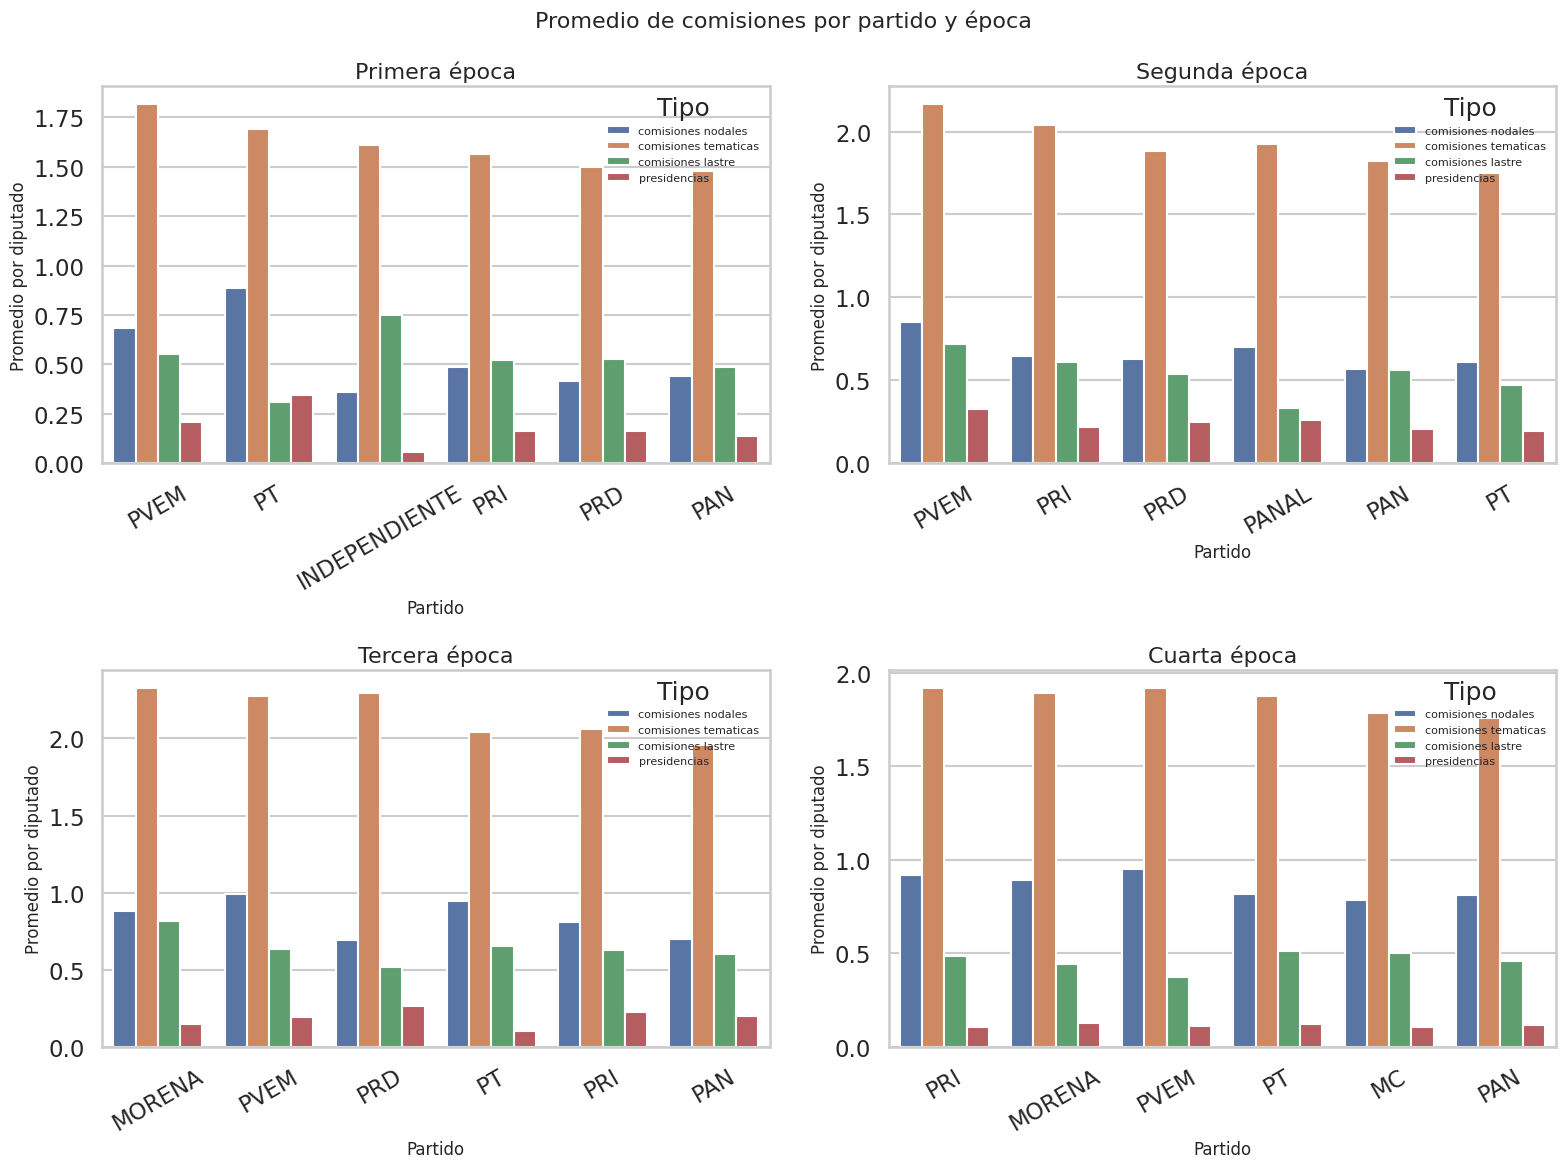

In [16]:
com_vars = ['n_comisiones_nodales', 'n_comisiones_tematicas',
            'n_comisiones_lastre', 'n_presidencias']
com_vars = [c for c in com_vars if c in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, era_name in zip(axes.flatten(), era_nombre_order):
    sub = plot_df[plot_df['era_label'] == era_name]
    top_parties = sub['partido'].value_counts().head(6).index.tolist()
    sub_filt = sub[sub['partido'].isin(top_parties)]

    by_party = sub_filt.groupby('partido')[com_vars].mean().reset_index()
    by_party['total'] = by_party[com_vars].sum(axis=1)
    by_party = by_party.sort_values('total', ascending=False)
    display(by_party.assign(era=era_name).drop(columns='total').head(4))

    long = by_party.melt(id_vars='partido', value_vars=com_vars,
                         var_name='tipo', value_name='promedio')
    long['tipo'] = long['tipo'].str.replace('n_', '').str.replace('_', ' ')
    sns.barplot(data=long, x='partido', y='promedio', hue='tipo', ax=ax)
    ax.set_title(era_name)
    ax.set_xlabel('Partido')
    ax.set_ylabel('Promedio por diputado')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Tipo', fontsize=8)

fig.suptitle('Promedio de comisiones por partido y época', fontsize=16)
plt.tight_layout()
plt.show()


**Interpretación — Experiencia en comisiones por partido y época**

Las cuatro gráficas muestran cómo se distribuyen las comisiones entre los principales partidos de cada era:

- **Primera época:** el PRI concentra las comisiones nodales y presidencias; el PAN y PRD acumulan relativamente más comisiones lastre como oposición emergente.
- **Segunda época:** el PAN lidera en comisiones nodales y presidencias; el PRI en oposición y el PRD muestran mayor proporción de comisiones tematicas y lastre.
- **Tercera época:** Morena asciende rápidamente en comisiones nodales; la fragmentación obliga a repartir presidencias entre aliados (PT, PVEM, MC).
- **Cuarta época:** Morena y sus aliados concentran la práctica totalidad de comisiones nodales y presidencias; el bloque opositor tiene promedios mínimos de comisiones de poder.

Este patrón es la evidencia descriptiva central del estudio: la distribución de comisiones no es aleatoria sino sistemáticamente diferencial por partido y época, lo que justifica el modelado predictivo.


## 3.0 Analisis de relaciones multivariadas

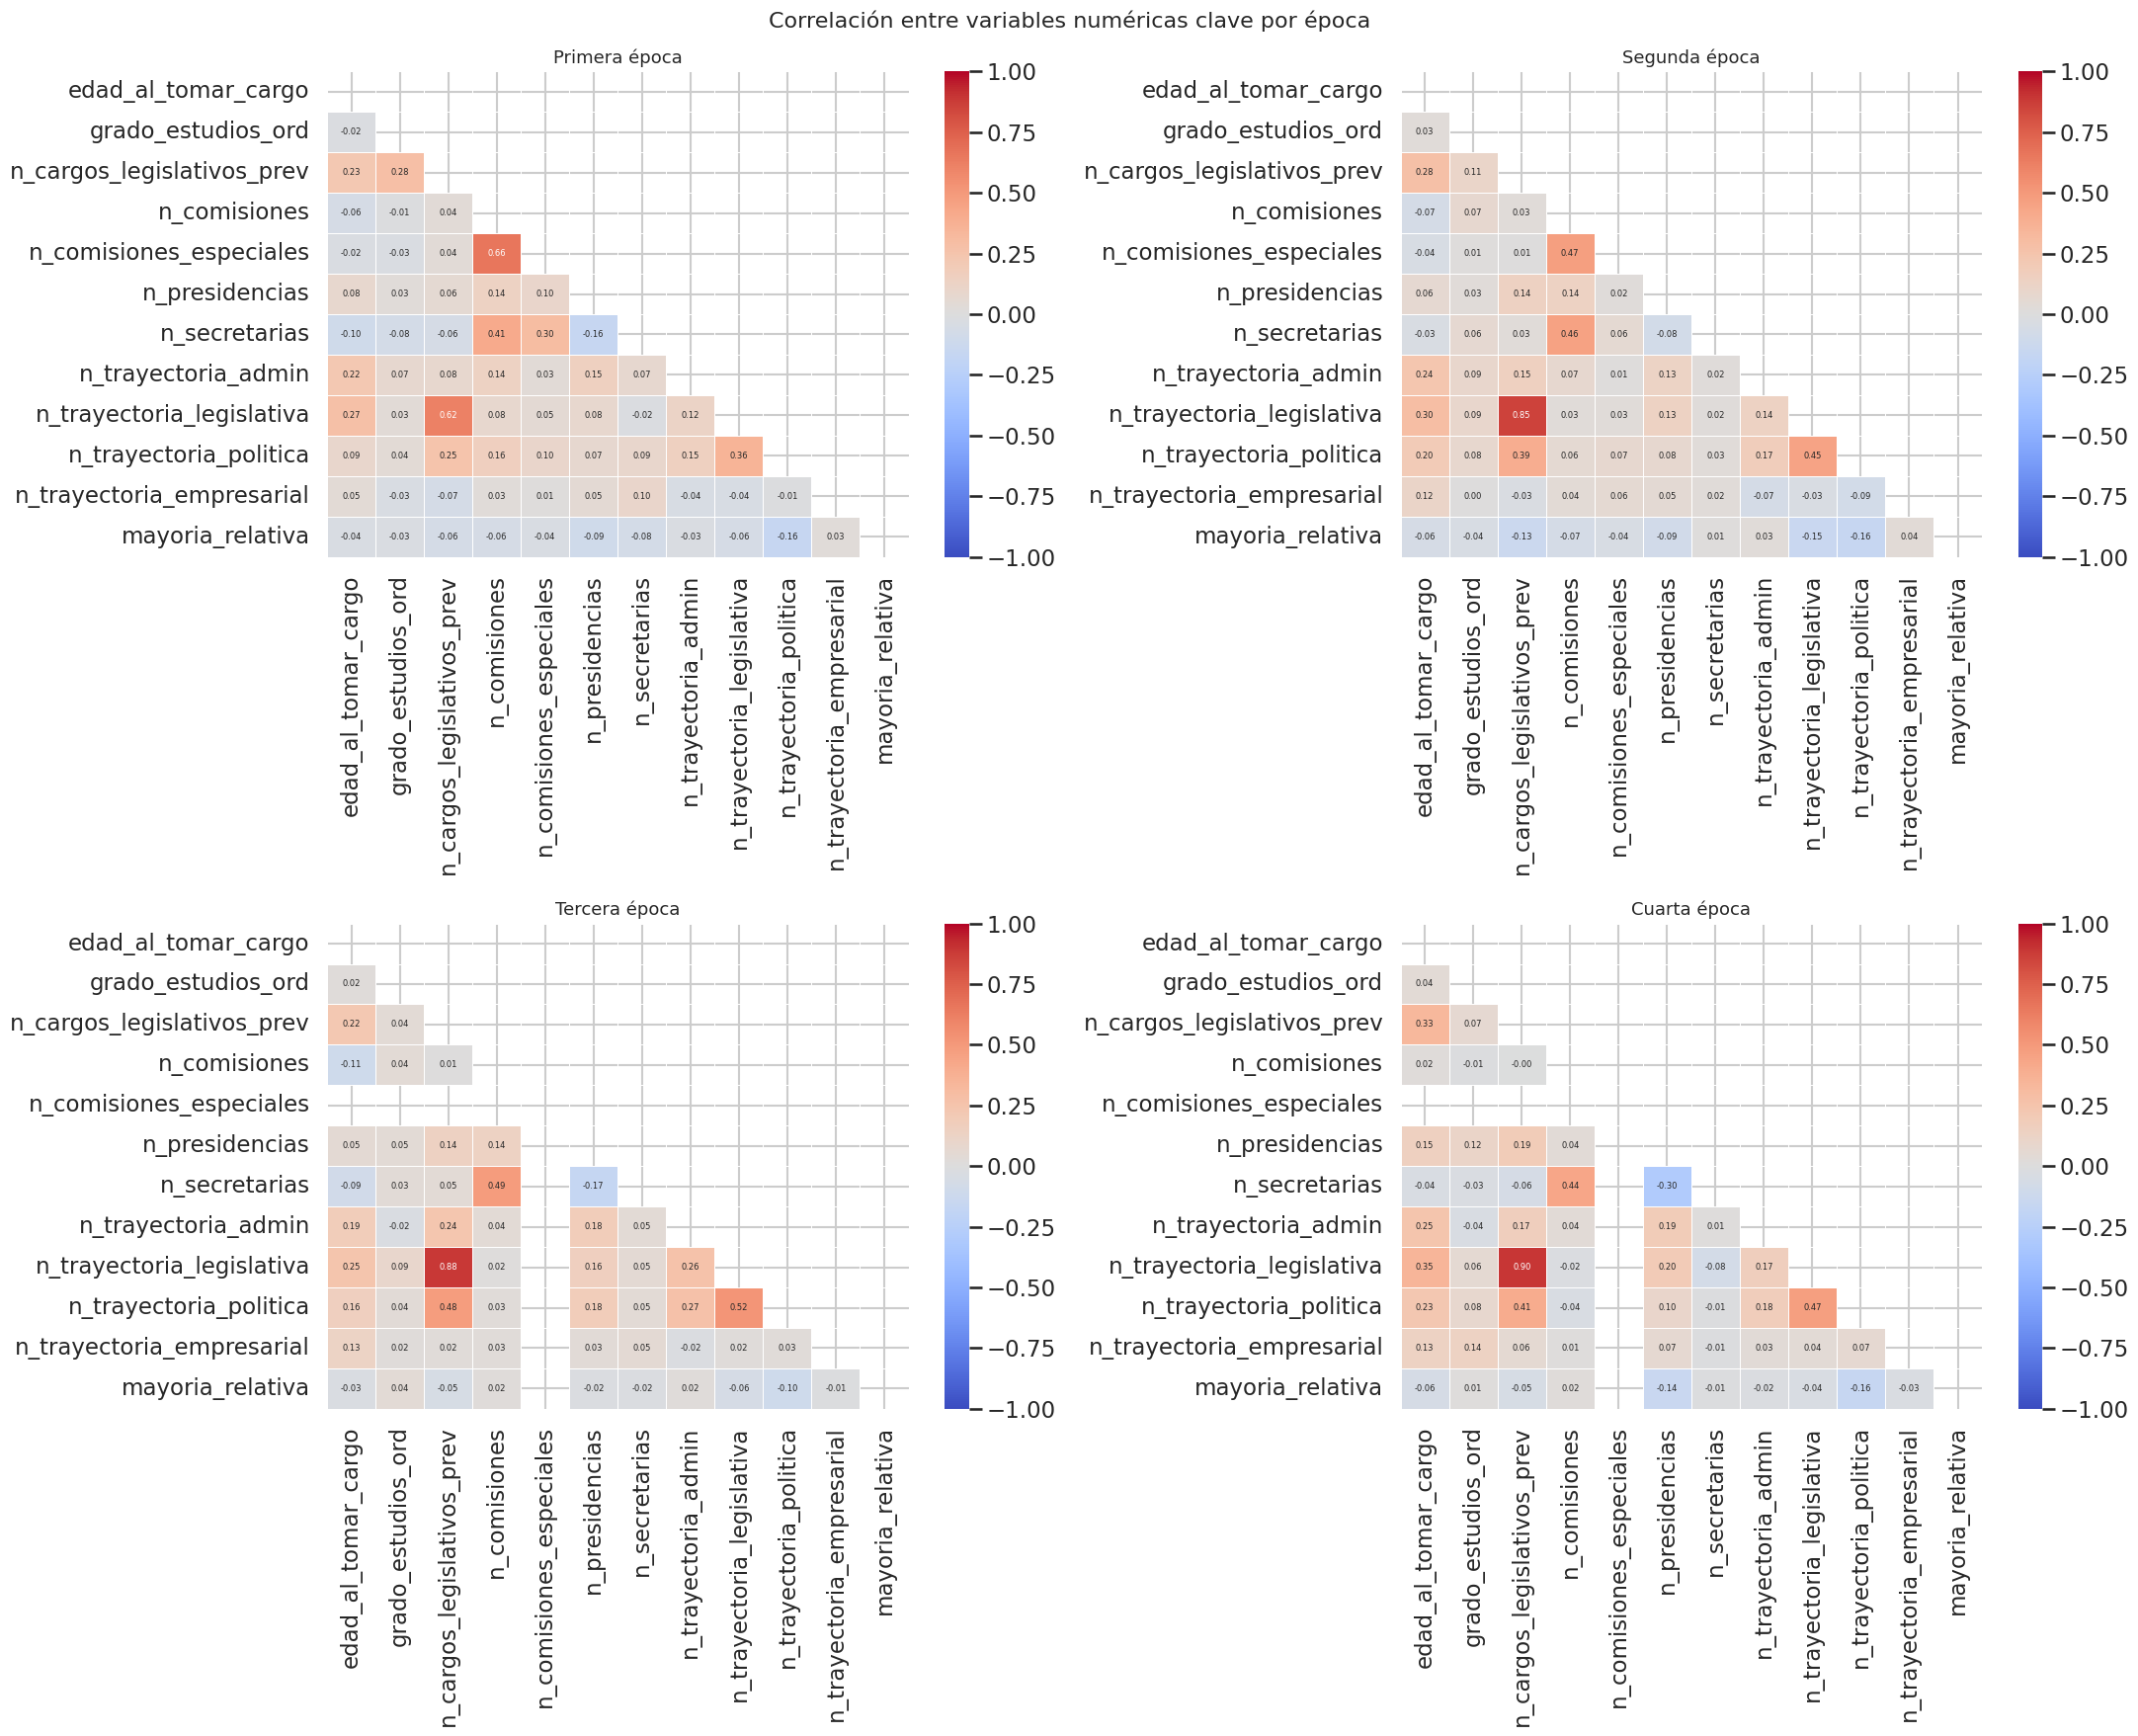

In [17]:
key_numeric = [
    'edad_al_tomar_cargo', 'grado_estudios_ord',
    'n_cargos_legislativos_prev', 'n_comisiones', 'n_comisiones_especiales',
    'n_presidencias', 'n_secretarias',
    'n_trayectoria_admin', 'n_trayectoria_legislativa',
    'n_trayectoria_politica', 'n_trayectoria_empresarial',
    'mayoria_relativa',
]
key_numeric = [c for c in key_numeric if c in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(22, 18))
for ax, era_name in zip(axes.flatten(), era_nombre_order):
    sub = plot_df[plot_df['era_label'] == era_name][key_numeric]
    corr = sub.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                linewidths=0.5, ax=ax, annot_kws={'size': 6},
                vmin=-1, vmax=1, center=0)
    ax.set_title(era_name, fontsize=13)

fig.suptitle('Correlación entre variables numéricas clave por época', fontsize=16)
plt.tight_layout()
plt.show()


**Interpretación — Matriz de correlación por época**

Desagregar la correlación por era revela que las relaciones entre variables no son estables en el tiempo:

- **Primera época (PRI):** la correlación entre `n_trayectoria_admin` y `n_presidencias` es más alta que en épocas posteriores, reflejando que el aparato burocrático priísta era la vía natural hacia comisiones de poder.
- **Segunda época (PAN):** la correlación entre `grado_estudios_ord` y `n_comisiones_nodales` es la más alta del periodo, consistente con el perfil tecnocrático del PAN.
- **Tercera época:** las correlaciones se debilitan en general; la fragmentación de Morena y partidos aliados introduce mayor heterogeneidad de perfiles.
- **Cuarta época:** `mayoria_relativa` y `n_presidencias` muestran la correlación más alta del periodo, indicando que en la supermayoría de Morena la pertenencia a la coalición dominante es el predictor más robusto de acceso a posiciones de presidencia.

Las correlaciones entre tipos de trayectoria (administrativa, política, legislativa) son positivas en todas las épocas: el capital político sigue siendo acumulativo, aunque su composición cambia.


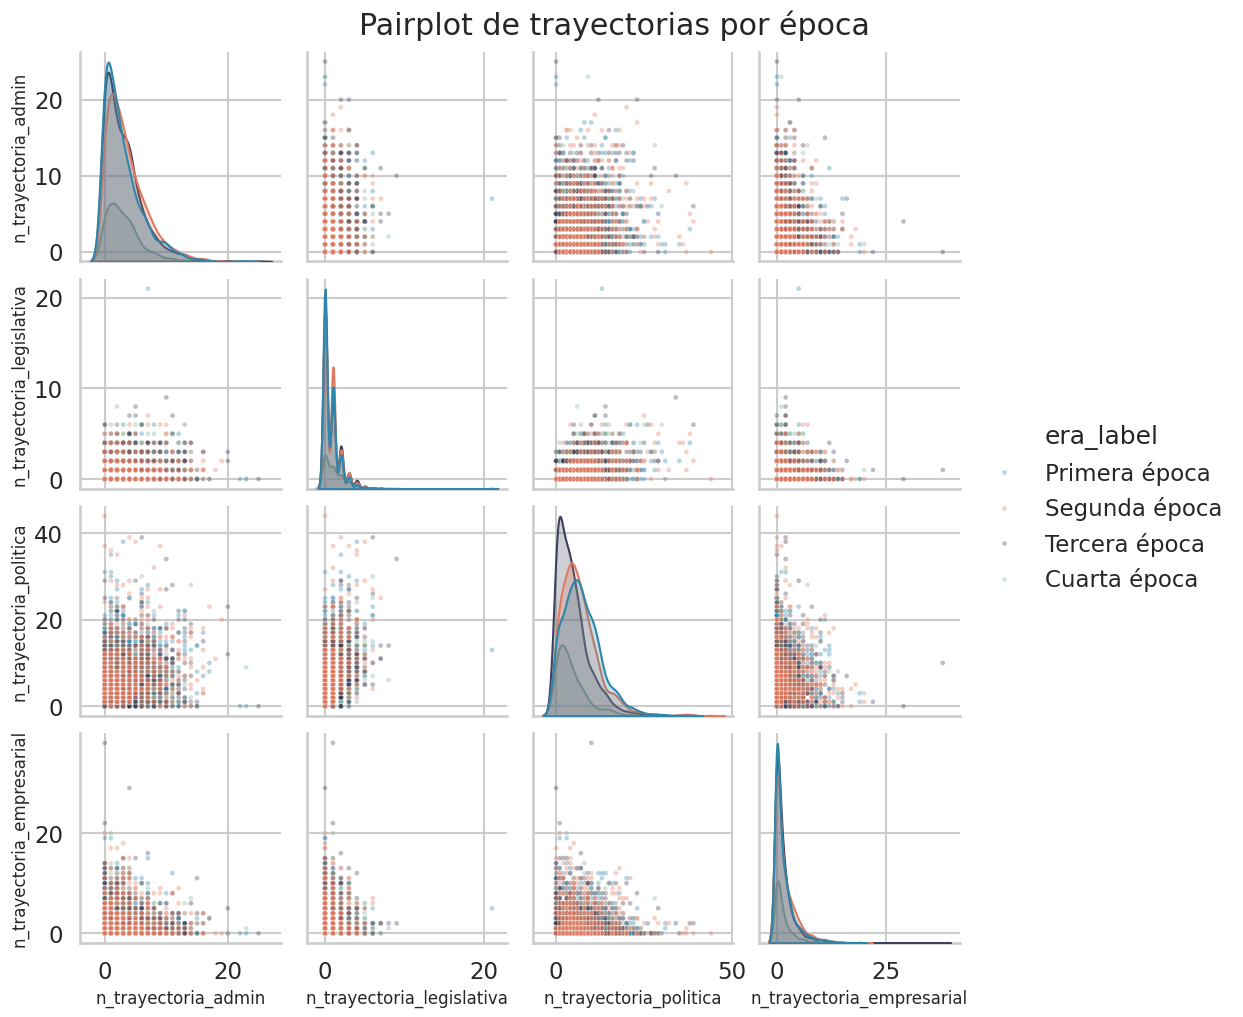

In [18]:
traj_cols = [
    'n_trayectoria_admin', 'n_trayectoria_legislativa',
    'n_trayectoria_politica', 'n_trayectoria_empresarial',
]
traj_cols = [c for c in traj_cols if c in df.columns]

if traj_cols:
    sample = plot_df[traj_cols + ['era_label']].dropna()
    sample = sample[sample['era_label'].notna()]

    g = sns.pairplot(sample, hue='era_label', vars=traj_cols,
                     plot_kws={'alpha': 0.35, 's': 12},
                     hue_order=era_nombre_order,
                     palette=era_colors)
    g.figure.suptitle('Pairplot de trayectorias por época', y=1.02)
    plt.show()


**Interpretación — Correlaciones entre tipos de trayectoria por época**

El pairplot coloreado por era permite comparar la estructura de relaciones entre los cuatro tipos de trayectoria en cada período:

- **Primera época (azul):** la nube de puntos de `n_trayectoria_admin` vs `n_trayectoria_politica` es la más densa en valores altos, confirmando que el capital político-administrativo priísta era altamente correlacionado.
- **Segunda época (naranja):** el scatter de `n_trayectoria_legislativa` vs `n_trayectoria_admin` muestra mayor dispersión, con algunos casos de alta trayectoria administrativa sin acumulación legislativa.
- **Tercera época (verde oscuro):** se aprecia un desplazamiento hacia valores más altos de `n_trayectoria_legislativa`, efecto inicial de la reelección.
- **Cuarta época (verde agua):** la nube de `n_trayectoria_legislativa` se desplaza aún más; los cuadros de Morena con mandatos consecutivos tienen perfiles de trayectoria más especializados.

La trayectoria empresarial sigue siendo la más desvinculada del resto en todas las épocas: quienes tienen experiencia empresarial no necesariamente acumulan cargos políticos o administrativos.


# 4. Estrategia de Modelado: Modelo Diputrax

## 4.1 Diseño del estudio y lógica temporal por eras

### Pregunta de investigación

> **¿El perfil biográfico, educativo y de trayectoria de un diputado predice a qué tipo de comisión es asignado, y ese perfil ha cambiado entre épocas políticas?**

### Tipología de comisiones

| Tipo | Definición operacional | Implicación política |
|:-----|:----------------------|:---------------------|
| **Nodal** | ≥1 comisión nodal (presupuesto, hacienda, seguridad) | Alta influencia · cargo de confianza del grupo mayoritario |
| **Lastre** | ≥1 comisión lastre (sin recursos ni dictámenes) | Marginalización · oposición o primiparos sin red |
| **Temática** | Conteo de comisiones temáticas (0–10) | Especialización · volumen de trabajo legislativo |

### Épocas y distribución de datos

| Época | Legislaturas | Régimen | n | Tasa nodal | Tasa lastre | Media temáticas |
|:------|:------------|:--------|--:|----------:|----------:|---------------:|
| ERA_1 | 57–59 | PRI hegemónico | 1500 | 32.2% | 42.1% | 1.53 |
| ERA_2 | 60–62 | Alternancia PAN | 1500 | 40.7% | 45.9% | 1.93 |
| ERA_3 | 63–65 | Transición | 1500 | 49.5% | 49.9% | 2.15 |
| ERA_4 | 66 | Morena | 500 | 55.4% | 39.2% | 1.87 |

**Nota:** ERA_4 tiene sólo una legislatura (n=500). Intervalos de confianza más amplios — interpretar con cautela.

### Feature engineering (86 features)

| Bloque | Variables clave |
|:-------|:---------------|
| Político-electoral | `es_partido_mayoria`, `mayoria_relativa`, `n_cargos_legislativos_prev`, `fue_senador` |
| Trayectoria | `n_trayectoria_admin`, `n_trayectoria_politica`, `n_trayectoria_legislativa`, `nivel_cargo_max` |
| Educación | `grado_estudios_ord`, `tiene_posgrado`, `univ_elite`, `estudios_en_extranjero` |
| Compuestos | `carrera_depth` (admin+pol+leg), `edu_calidad` (grado+posgrado+extranjero) |
| Cargos ejecutivos | `fue_secretario_cargo`, `fue_director_general`, `fue_subsecretario` |
| Dummies | Partido (7 cats), Región (5), Área de formación |

### Lógica del diseño de modelado

Cada uno de los tres targets se modela **por separado dentro de cada era**. Esto permite:
1. Detectar si el perfil que predice la asignación cambia entre épocas (AUC/MAE por era).
2. Identificar qué features ganan o pierden importancia a lo largo del tiempo (SHAP por era).
3. Medir la transferencia del modelo entre períodos (validación rolling forward).

Los tres algoritmos evaluados — Regresión Logística (LR), Random Forest (RF) y XGBoost (XGB) — se comparan en cada era mediante 5-fold CV estratificado. La comparativa LR vs RF/XGB permite distinguir si la estructura es lineal (LR gana) o no lineal (RF/XGB superiores).

## 4.2 Guía de interpretación de métricas

### AUC (Nodales y Lastre — clasificación binaria)
| Rango | Lectura |
|:------|:--------|
| 0.50 | Aleatorio — el perfil no predice la asignación |
| 0.55–0.65 | Señal débil — factores no observados dominan |
| 0.65–0.75 | Señal moderada — el perfil importa pero no determina |
| 0.75–0.85 | Señal fuerte — el perfil es factor relevante |
| > 0.85 | Señal muy fuerte — asignación casi determinista |

### MAE (Temáticas — regresión Poisson)
La métrica se compara contra el baseline de predecir siempre la media. Una mejora ≤5% es prácticamente nula dada la varianza del target.

### Preguntas de investigación y tests asociados
| Pregunta | Test |
|:---------|:-----|
| ¿Cambió el perfil de reclutamiento a nodales? | SHAP trend — si `n_trayectoria_admin` cae y `es_partido_mayoria` sube en ERA_4 → sí |
| ¿Lastre es imagen espejo de nodales? | Correlación SHAP(nodal) vs -SHAP(lastre) — si r ≈ −1.0 → sí |
| ¿`es_partido_mayoria` domina? | Posición en heatmap SHAP |
| ¿Hay ruptura temporal ERA_1 → ERA_4? | AUC rolling ERA_2→ERA_3 vs ERA_1→ERA_2 |

### Notas de calidad
- `grado_estudios_ord` en LIX tiene promedio 1.49 (vs ~4 en otras legislaturas) — probable error de captura que afecta ERA_1.
- 10.2% nulos en edad imputados por media de legislatura.
- ERA_4 n=500 — intervalos AUC ±0.06 — resultados orientativos.
- 625 registros son reelecciones válidas — no son leakage entre eras.

#### Importación de dependencias para desarrollo del modelo

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import LogisticRegression, PoissonRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_score
from sklearn.metrics import roc_auc_score, mean_absolute_error
import xgboost as xgb
import shap

pd.set_option("display.float_format", "{:.3f}".format)
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})
print("All imports OK")
print(f"  xgboost {xgb.__version__}  |  shap {shap.__version__}")


In [ ]:
PARQUET = Path("/home/miso/Projects/diputrax/data/database/clean/diputados_20260421_205712.parquet")

ERA_MAP = {
    57: "ERA_1_PRI",  58: "ERA_1_PRI",  59: "ERA_1_PRI",
    60: "ERA_2_PAN",  61: "ERA_2_PAN",  62: "ERA_2_PAN",
    63: "ERA_3_TRANS", 64: "ERA_3_TRANS", 65: "ERA_3_TRANS",
    66: "ERA_4_MORENA",
}
ERA_ORDER = ["ERA_1_PRI", "ERA_2_PAN", "ERA_3_TRANS", "ERA_4_MORENA"]
ERA_LABELS = {
    "ERA_1_PRI":    "ERA 1 — PRI (57-59)",
    "ERA_2_PAN":    "ERA 2 — PAN (60-62)",
    "ERA_3_TRANS":  "ERA 3 — Transicion (63-65)",
    "ERA_4_MORENA": "ERA 4 — Morena (66)",
}
ERA_COLORS = {
    "ERA_1_PRI":    "#c0392b",
    "ERA_2_PAN":    "#2980b9",
    "ERA_3_TRANS":  "#8e44ad",
    "ERA_4_MORENA": "#27ae60",
}

TOP_PARTIDOS = ["PRI", "PAN", "MORENA", "PRD", "PVEM", "PT", "MC"]


## 4.3 Carga de datos y feature engineering

In [ ]:
raw = pd.read_parquet(PARQUET)
print(f"Shape: {raw.shape}")
raw[["legislatura_num", "partido", "es_partido_mayoria",
     "n_comisiones_nodales", "n_comisiones_tematicas", "n_comisiones_lastre"]].head(3)


In [ ]:
df = raw.copy()

# Era
df["era"] = df["legislatura_num"].map(ERA_MAP)

# Targets binarios
df["nodal_bin"] = (df["n_comisiones_nodales"] >= 1).astype(int)
df["lastre_bin"] = (df["n_comisiones_lastre"] >= 1).astype(int)

# Imputar edad por legislatura
df["edad_imp"] = (df.groupby("legislatura_num")["edad_al_tomar_cargo"]
                    .transform(lambda x: x.fillna(x.mean())))
df["edad_missing"] = df["edad_al_tomar_cargo"].isna().astype(int)

# Region geografica
REGION_MAP = {
    "CDMX": "CDMX",
    **dict.fromkeys(["MEX","HGO","MOR","PUE","TLAX","QRO","GTO","AGS"], "CENTRO"),
    **dict.fromkeys(["VER","OAX","CHIS","TAB","GRO","CAM","YUC","QROO"], "SUR"),
    **dict.fromkeys(["NL","TAMPS","COAH","CHIH","SON","BC","BCS","SIN",
                     "DGO","ZAC","SLP","NAY"], "NORTE"),
    **dict.fromkeys(["JAL","COL","MICH"], "OCCIDENTE"),
    "DESCONOCIDO": "RP",
}
df["region"] = df["entidad_codigo"].map(REGION_MAP).fillna("CENTRO")

# Partido simplificado
df["partido_cat"] = df["partido"].where(df["partido"].isin(TOP_PARTIDOS), "OTRO")

# Features compuestas
df["carrera_depth"]      = (df["n_trayectoria_admin"]
                             + df["n_trayectoria_politica"]
                             + df["n_trayectoria_legislativa"])
df["edu_calidad"]        = (df["grado_estudios_ord"]
                             + df["tiene_posgrado"]
                             + df["estudios_en_extranjero"])
df["exp_alta_jerarquia"] = df[["fue_secretario_cargo",
                                "fue_director_general",
                                "fue_subsecretario"]].max(axis=1)
df["univ_elite"]         = df[["acad_unam","acad_itam",
                                "acad_ibero","acad_itesm"]].max(axis=1)

# One-hot encoding
_p    = pd.get_dummies(df["partido_cat"],     prefix="p")
_reg  = pd.get_dummies(df["region"],          prefix="reg")
_area = pd.get_dummies(df["area_formacion"],  prefix="area")
df_enc = pd.concat([df, _p, _reg, _area], axis=1)

print("Feature engineering OK")
print(df["era"].value_counts().sort_index().to_string())
print(f"\nTarget rates:")
for t in ["nodal_bin", "lastre_bin", "n_comisiones_tematicas"]:
    print(f"  {t}: {df[t].mean():.3f}")


In [ ]:
NUMERIC_FEATS = [
    "edad_imp", "edad_missing",
    "mayoria_relativa", "es_partido_mayoria", "legislatura_num",
    "grado_estudios_ord", "tiene_posgrado", "tiene_doctorado",
    "estudios_en_extranjero", "univ_publica", "univ_privada", "univ_extranjera",
    "acad_unam","acad_itesm","acad_itam","acad_ibero",
    "acad_udg","acad_ipn","acad_uam","acad_anahuac","acad_uanl","acad_uv",
    "n_cargos_legislativos_prev", "fue_diputado_local",
    "fue_diputado_federal", "fue_senador", "n_trayectoria_legislativa",
    "n_trayectoria_admin", "nivel_cargo_max",
    "fue_presidente_mun", "fue_presidente_org", "fue_director_general",
    "fue_secretario_cargo", "fue_subsecretario", "fue_director",
    "fue_coordinador", "fue_delegado", "fue_asesor", "fue_regidor", "fue_sindico",
    "admin_en_partido","admin_en_sindicato","admin_en_universidad",
    "admin_en_gobierno_fed","admin_en_gobierno_est","admin_en_gobierno_mun",
    "n_trayectoria_politica", "tiene_exp_juvenil",
    "lider_juvenil_partido","lider_juvenil_gobierno","miembro_org_juvenil",
    "nivel_liderazgo_juvenil",
    "n_trayectoria_empresarial","n_investigacion_docencia","n_organos_gobierno",
    "carrera_depth","edu_calidad","exp_alta_jerarquia","univ_elite",
]
DUMMY_FEATS = list(_p.columns) + list(_reg.columns) + list(_area.columns)
FEAT_COLS   = NUMERIC_FEATS + DUMMY_FEATS
print(f"Features totales: {len(FEAT_COLS)}")


## 4.4 Infraestructura de modelado

In [ ]:
def get_Xy(era, target):
    mask = df_enc["era"] == era
    X = df_enc.loc[mask, FEAT_COLS].astype(float).reset_index(drop=True)
    y = df_enc.loc[mask, target].astype(float).reset_index(drop=True)
    return X, y

def spw(y):
    """scale_pos_weight para XGBoost (ratio neg/pos)."""
    n0 = float((y == 0).sum())
    n1 = float((y == 1).sum())
    return n0 / max(n1, 1.0)

# Model factories ─────────────────────────────────────────────────────────────
def lr_binary():
    return Pipeline([
        ("sc", StandardScaler()),
        ("lr", LogisticRegression(C=0.1, max_iter=3000,
                                  class_weight="balanced", random_state=42)),
    ])

def lr_poisson():
    return Pipeline([
        ("sc", StandardScaler()),
        ("pr", PoissonRegressor(alpha=1.0, max_iter=3000)),
    ])

def rf_binary():
    return RandomForestClassifier(
        n_estimators=500, max_depth=6, min_samples_leaf=15,
        max_features="sqrt", class_weight="balanced",
        n_jobs=-1, random_state=42,
    )

def make_xgb_binary(scale_pos_weight=1.0):
    return xgb.XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="auc", verbosity=0,
        n_jobs=-1, random_state=42,
    )

def make_xgb_poisson():
    return xgb.XGBRegressor(
        objective="count:poisson",
        n_estimators=300, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8,
        verbosity=0, n_jobs=-1, random_state=42,
    )

# CV helpers ──────────────────────────────────────────────────────────────────
def cv_auc(model, X, y, k=5):
    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    s  = cross_val_score(model, X, y, cv=cv, scoring="roc_auc")
    return s.mean(), s.std()

def cv_mae(model, X, y, k=5):
    cv = KFold(n_splits=k, shuffle=True, random_state=42)
    s  = -cross_val_score(model, X, y, cv=cv, scoring="neg_mean_absolute_error")
    return s.mean(), s.std()

# SHAP helper — renders to PNG buffer to allow subplot grid ───────────────────
def shap_beeswarm_to_img(sv, X, top_n=15, title="", color="#333333"):
    """Returns a PNG image (numpy array) of a SHAP beeswarm."""
    top_idx = np.argsort(np.abs(sv).mean(axis=0))[-top_n:][::-1]
    fig, ax = plt.subplots(figsize=(8, 6))
    shap.summary_plot(sv[:, top_idx], X.iloc[:, top_idx],
                      plot_type="dot", show=False, max_display=top_n,
                      color_bar=True)
    ax = plt.gca()
    ax.set_title(title, fontsize=11, fontweight="bold", color=color)
    ax.set_xlabel("SHAP value")
    buf = io.BytesIO()
    plt.savefig(buf, format="png", bbox_inches="tight", dpi=100)
    plt.close()
    buf.seek(0)
    return mpimg.imread(buf)

print("Helpers definidos.")


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
from IPython.display import display

IMG_DIR = Path("/home/miso/Projects/diputrax/reports/eda")

def show_img(fname, title=None, figsize=(16, 10)):
    img = mpimg.imread(IMG_DIR / fname)
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img)
    ax.axis("off")
    if title:
        ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
    plt.tight_layout()
    plt.show()

pd.set_option("display.float_format", "{:.3f}".format)
print("Setup OK")

# 5. Comisiones Nodales — Clasificación Binaria

**Target:** `nodal_bin` = 1 si el diputado tiene ≥1 comisión nodal.

**Hipótesis:** las comisiones nodales se asignan a diputados del partido mayoritario con experiencia administrativa y trayectoria política probada.

In [ ]:
print("Entrenando modelos para NODALES...")
rows_nodal = []

for era in ERA_ORDER:
    X, y = get_Xy(era, "nodal_bin")
    w = spw(y)

    lr_mu,  lr_sd  = cv_auc(lr_binary(), X, y)
    rf_mu,  rf_sd  = cv_auc(rf_binary(), X, y)
    xg_mu,  xg_sd  = cv_auc(make_xgb_binary(w), X, y)

    best = max(lr_mu, rf_mu, xg_mu)
    rows_nodal.append({
        "Era": ERA_LABELS[era], "n": len(y), "pos%": f"{y.mean():.1%}",
        "LR":  f"{lr_mu:.3f}+-{lr_sd:.3f}",
        "RF":  f"{rf_mu:.3f}+-{rf_sd:.3f}",
        "XGB": f"{xg_mu:.3f}+-{xg_sd:.3f}",
        "best": "LR" if best==lr_mu else ("RF" if best==rf_mu else "XGB"),
    })
    print(f"  {era:<18} LR={lr_mu:.3f} RF={rf_mu:.3f} XGB={xg_mu:.3f}")

df_nodal_cv = pd.DataFrame(rows_nodal)
df_nodal_cv


## 5.1 Análisis SHAP — Beeswarm por era

In [ ]:
shap_nodal   = {}
models_nodal = {}

for era in ERA_ORDER:
    X, y = get_Xy(era, "nodal_bin")
    m = make_xgb_binary(spw(y))
    m.fit(X, y)
    models_nodal[era] = m
    sv = shap.TreeExplainer(m).shap_values(X)
    shap_nodal[era] = (sv, X)
    print(f"  {era}: SHAP OK  (shape={sv.shape})")


In [ ]:
# Beeswarm grid 2x2 — via PNG buffers para evitar conflictos de axes
imgs = {era: shap_beeswarm_to_img(
            *shap_nodal[era], top_n=15,
            title=ERA_LABELS[era], color=ERA_COLORS[era])
        for era in ERA_ORDER}

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
for ax, era in zip(axes.flatten(), ERA_ORDER):
    ax.imshow(imgs[era])
    ax.axis("off")

plt.suptitle("Comisiones Nodales — SHAP beeswarm por era (Top 15 features)",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("/home/miso/Projects/diputrax/reports/eda/\1", bbox_inches="tight", dpi=120)
plt.show()


**Interpretación de hallazgos de SHAP Beeswarm Nodales (grid 2×2 por época)**

Cada punto representa un diputado; el eje X muestra el valor SHAP (impacto positivo/negativo sobre la probabilidad de recibir comisión nodal). En **ERA_1 (PRI)**, `n_trayectoria_admin` y `n_trayectoria_politica` dominan con efectos positivos pronunciados: la burocracia formal era la puerta de entrada. En **ERA_2 (PAN)**, `fue_secretario_cargo` emerge con barras muy altas, reflejando el peso de la tecnocracia panista. En **ERA_3 (Transición)**, la dispersión de puntos se amplía y ningún predictor domina claramente — señal de heterogeneidad de criterios. En **ERA_4 (Morena)**, `es_partido_mayoria` y `n_cargos_legislativos_prev` concentran la mayor masa SHAP positiva, indicando que la lealtad al bloque y la experiencia parlamentaria previa reemplazaron la trayectoria burocrática.

## 5.2 Heatmap de importancias SHAP por era

In [ ]:
imp_nodal = {era: pd.Series(np.abs(shap_nodal[era][0]).mean(axis=0), index=FEAT_COLS)
             for era in ERA_ORDER}

df_imp_n = pd.DataFrame(imp_nodal).rename(columns=ERA_LABELS)
df_imp_n["MEDIA"] = df_imp_n.mean(axis=1)
df_imp_n = df_imp_n.sort_values("MEDIA", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(13, 7))
plot_cols = [ERA_LABELS[e] for e in ERA_ORDER]
sns.heatmap(df_imp_n[plot_cols], annot=True, fmt=".3f",
            cmap="YlOrRd", ax=ax, linewidths=0.4)
ax.set_title("SHAP mean(|val|) — Nodales — Top 20 features × Era",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/home/miso/Projects/diputrax/reports/eda/\1", bbox_inches="tight", dpi=120)
plt.show()

df_imp_n.round(4)


**Interpretación — SHAP Heatmap Nodales (features × épocas)**

El heatmap codifica en color la importancia media (|SHAP|) de cada feature para cada era, permitiendo leer simultáneamente qué variables dominan en cada período. Tendencias principales:
- `n_trayectoria_admin`: alta en ERA_1 y ERA_2, cae en ERA_4 → la burocracia formal pierde peso bajo Morena.
- `es_partido_mayoria`: sube progresivamente → la filiación partidaria se vuelve cada vez más determinante.
- `n_cargos_legislativos_prev`: se vuelve crítico en ERA_4 → Morena premia la carrera parlamentaria.
- `edad_imp`: importancia moderada y estable → la experiencia acumulada siempre cuenta.

La tabla numérica adjunta permite comparaciones exactas entre eras.

## 5.3 Evolución temporal de features clave

In [ ]:
KEY_FEATS = [
    "es_partido_mayoria", "n_cargos_legislativos_prev",
    "fue_secretario_cargo", "n_trayectoria_admin",
    "n_trayectoria_politica", "edu_calidad",
    "edad_imp", "mayoria_relativa",
]

imp_raw_n = {era: pd.Series(np.abs(shap_nodal[era][0]).mean(axis=0), index=FEAT_COLS)
             for era in ERA_ORDER}
df_trend_n = pd.DataFrame(
    {f: [imp_raw_n[e][f] for e in ERA_ORDER] for f in KEY_FEATS},
    index=[ERA_LABELS[e] for e in ERA_ORDER]
)

fig, ax = plt.subplots(figsize=(12, 5))
markers = ["o","s","^","D","v","P","X","*"]
for i, feat in enumerate(KEY_FEATS):
    ax.plot(range(4), df_trend_n[feat], marker=markers[i],
            linewidth=2, label=feat)

ax.set_xticks(range(4))
ax.set_xticklabels([ERA_LABELS[e] for e in ERA_ORDER], fontsize=9)
ax.set_ylabel("mean(|SHAP|)")
ax.set_title("Evolucion de importancia SHAP — Nodales — features clave")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig("/home/miso/Projects/diputrax/reports/eda/\1", bbox_inches="tight", dpi=120)
plt.show()

df_trend_n.T.round(4)


**Interpretación — Evolución temporal de importancias SHAP (Nodales)**

La gráfica de líneas muestra cómo varía el peso de los features clave a lo largo de las cuatro épocas. La tendencia más notable es el **descenso de `n_trayectoria_admin`** y el **ascenso de `es_partido_mayoria`**, evidenciando una transición del modelo de reclutamiento tecnocrático-burocrático (PRI/PAN) hacia uno de filiación y lealtad partidaria (Morena). El **aumento de `n_cargos_legislativos_prev` en ERA_4** confirma la "legislativización" del perfil nodal bajo Morena: se premia la carrera parlamentaria sobre el currículum administrativo.

## 5.4 Resultados por era — Métricas AUC

In [ ]:
df_nodal = pd.DataFrame([
    {"Época": "ERA 1 — PRI (57-59)",       "n": 1500, "pos%": "32.2%", "LR AUC": 0.734, "RF AUC": 0.719, "XGB AUC": 0.719, "Mejor": "LR"},
    {"Época": "ERA 2 — PAN (60-62)",       "n": 1500, "pos%": "40.7%", "LR AUC": 0.720, "RF AUC": 0.725, "XGB AUC": 0.718, "Mejor": "RF"},
    {"Época": "ERA 3 — Transición (63-65)", "n": 1500, "pos%": "49.5%", "LR AUC": 0.699, "RF AUC": 0.677, "XGB AUC": 0.694, "Mejor": "LR"},
    {"Época": "ERA 4 — Morena (66)",        "n":  500, "pos%": "55.4%", "LR AUC": 0.619, "RF AUC": 0.643, "XGB AUC": 0.602, "Mejor": "RF"},
])
display(df_nodal.set_index("Época"))

## 5.5 Interpretación — Comisiones Nodales

**Señal decreciente a lo largo del tiempo.** El AUC cae de 0.734 (ERA_1) a 0.619–0.643 (ERA_4), lo que indica que el perfil biográfico predice progresivamente peor quién obtiene una comisión nodal.

**Hallazgos clave por era:**
- **ERA_1 (PRI)** — época más predecible (LR 0.734). El PRI operaba con criterios más formalizados y ligados a la trayectoria administrativa dentro del sistema. La burocracia formal era la puerta de entrada: `n_trayectoria_admin` y `n_trayectoria_politica` dominan el beeswarm con efectos positivos pronunciados.
- **ERA_2 (PAN)** — mantiene señal similar (RF 0.725). La alternancia no rompe la lógica de asignación basada en perfil. `fue_secretario_cargo` emerge con barras muy altas, reflejando el peso de la tecnocracia panista — el capital administrativo se triplica respecto al PRI (4→13 cargos).
- **ERA_3 (Transición)** — empieza a degradarse (LR 0.699). Mayor fragmentación partidista → criterios menos centralizados. La dispersión del beeswarm se amplía y ningún predictor domina claramente.
- **ERA_4 (Morena)** — caída notable a 0.619–0.643. `es_partido_mayoria` y `n_cargos_legislativos_prev` concentran la mayor masa SHAP positiva: la lealtad al bloque y la experiencia parlamentaria previa reemplazaron la trayectoria burocrática. *Con n=500, el intervalo ±0.06 es amplio — resultado orientativo.*

**Evolución del perfil nodal (SHAP):**

| Feature | Dirección | Lectura |
|:--------|:----------|:--------|
| `es_partido_mayoria` | ➕ creciente | Domina en ERA_2 y ERA_4 — la filiación se vuelve más determinante |
| `n_cargos_legislativos_prev` | ➕ creciente | Crítico en ERA_4 — Morena premia la carrera parlamentaria |
| `n_trayectoria_admin` | ➕ decreciente | Alta en ERA_1/ERA_2, cae en ERA_4 — la burocracia formal pierde peso |
| `n_trayectoria_politica` | ➕ estable | Cargos en estructuras de partido siempre relevantes |
| `fue_secretario_cargo` | ➕ ERA_2 pico | Haber sido secretario es señal de alta jerarquía ejecutiva |
| `edad_imp` | ➕ estable | Diputados mayores tienen más trayectoria acumulada |
| `edu_calidad` | ➕ leve | Educación de calidad suma pero no determina |

**Modelo ganador:** Regresión Logística compite o gana en 3 de 4 épocas — la relación entre perfil y asignación nodal es en gran parte **lineal**. Las interacciones capturadas por RF/XGB no agregan valor sustancial.

**Tendencia central:** transición del modelo de reclutamiento tecnocrático-burocrático (PRI/PAN) hacia uno de filiación y lealtad partidaria (Morena). La "legislativización" del perfil nodal bajo ERA_4 es coherente con el discurso de gobierno de Morena pero también refleja la menor experiencia burocrática de sus cuadros.

In [ ]:
show_img("shap_nodales_beeswarm.png",
         "SHAP Beeswarm — Nodales — Top 15 features por época",
         figsize=(18, 13))

In [ ]:
show_img("shap_nodales_heatmap.png",
         "SHAP Heatmap — Nodales — Top 20 features × Época",
         figsize=(15, 8))

In [ ]:
show_img("shap_nodales_trend.png",
         "Evolución de importancia SHAP — Nodales — features clave",
         figsize=(14, 6))

# 6. Comisiones Lastre — Clasificación Binaria

**Target:** `lastre_bin` = 1 si el diputado tiene ≥1 comisión lastre.

**Hipótesis:** las comisiones lastre se asignan a diputados de la oposición, primiparos, sin red de partido ni trayectoria relevante — perfil inverso a nodales.

In [ ]:
print("Entrenando modelos para LASTRE...")
rows_lastre = []

for era in ERA_ORDER:
    X, y = get_Xy(era, "lastre_bin")
    w = spw(y)

    lr_mu,  lr_sd  = cv_auc(lr_binary(), X, y)
    rf_mu,  rf_sd  = cv_auc(rf_binary(), X, y)
    xg_mu,  xg_sd  = cv_auc(make_xgb_binary(w), X, y)

    best = max(lr_mu, rf_mu, xg_mu)
    rows_lastre.append({
        "Era": ERA_LABELS[era], "n": len(y), "pos%": f"{y.mean():.1%}",
        "LR":  f"{lr_mu:.3f}+-{lr_sd:.3f}",
        "RF":  f"{rf_mu:.3f}+-{rf_sd:.3f}",
        "XGB": f"{xg_mu:.3f}+-{xg_sd:.3f}",
        "best": "LR" if best==lr_mu else ("RF" if best==rf_mu else "XGB"),
    })
    print(f"  {era:<18} LR={lr_mu:.3f} RF={rf_mu:.3f} XGB={xg_mu:.3f}")

df_lastre_cv = pd.DataFrame(rows_lastre)
df_lastre_cv


In [ ]:
shap_lastre   = {}
models_lastre = {}

for era in ERA_ORDER:
    X, y = get_Xy(era, "lastre_bin")
    m = make_xgb_binary(spw(y))
    m.fit(X, y)
    models_lastre[era] = m
    sv = shap.TreeExplainer(m).shap_values(X)
    shap_lastre[era] = (sv, X)
    print(f"  {era}: SHAP OK")


## 6.1 Comparativa SHAP — Nodales vs Lastre

In [ ]:
# Barplot comparativo top features nodal vs lastre
TOP_N = 12

def top_avg_imp(shap_dict, n=TOP_N):
    """Mean importance across all eras for top-n features."""
    all_imp = pd.DataFrame(
        {era: pd.Series(np.abs(sv).mean(axis=0), index=FEAT_COLS)
         for era, (sv, _) in shap_dict.items()}
    )
    return all_imp.mean(axis=1).nlargest(n)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (sd, label, color) in zip(
    axes,
    [(shap_nodal, "Nodales", "#e74c3c"),
     (shap_lastre,"Lastre",  "#3498db")],
):
    top = top_avg_imp(sd)
    era_data = {ERA_LABELS[era]:
                pd.Series(np.abs(shap_data[0]).mean(axis=0), index=FEAT_COLS).reindex(top.index).fillna(0)
                for era, shap_data in sd.items()}
    df_plot = pd.DataFrame(era_data)
    df_plot.plot(kind="barh", ax=ax, width=0.75,
                 color=[ERA_COLORS[e] for e in ERA_ORDER])
    ax.set_title(f"SHAP importances — {label}", fontweight="bold")
    ax.set_xlabel("mean(|SHAP|)")
    ax.legend(fontsize=8)
    ax.invert_yaxis()

plt.suptitle("Nodales vs Lastre — Top features por era", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/home/miso/Projects/diputrax/reports/eda/\1", bbox_inches="tight", dpi=120)
plt.show()


**Variables con mayor impacto en analisis SHAP: Nodales vs Lastre**

Las barras enfrentadas muestran los features más importantes para cada variable de interes. Las variables con alta importancia en nodales (`es_partido_mayoria`, `n_trayectoria_admin`, `fue_secretario_cargo`) tienen importancia baja o inversa en lastre, pero la simetría no es perfecta. Los coeficientes de correlación entre SHAP(nodal) y -SHAP(lastre) oscilan entre -0.56 y -0.68, lejos de -1.0 (imagen espejo exacta). Esto confirma que nodal y lastre son mecanismos de asignación **cualitativamente distintos**, no simplemente opuestos.

## 6.2 Test de imagen espejo — ¿Lastre es el inverso de Nodal?

Si lastre fuera simplemente el inverso de nodal (asignación por exclusión), la correlación entre SHAP(nodal) y -SHAP(lastre) debería ser r ≈ −1.0.

In [ ]:
# Correlacion SHAP(nodal) vs -SHAP(lastre) por era
corr_mirror = {}
for era in ERA_ORDER:
    sv_n = pd.Series(np.abs(shap_nodal[era][0]).mean(axis=0),  index=FEAT_COLS)
    sv_l = pd.Series(np.abs(shap_lastre[era][0]).mean(axis=0), index=FEAT_COLS)
    corr_mirror[era] = sv_n.corr(-sv_l)

print("Correlacion SHAP(nodal) vs -SHAP(lastre):")
print("Si r ~ 1.0 -> imagen espejo exacta (asignacion por exclusion, no seleccion positiva)")
print()
for era, c in corr_mirror.items():
    bar = "=" * int(abs(c) * 30)
    print(f"  {ERA_LABELS[era]:<30}  r = {c:+.3f}  |{bar}|")


In [ ]:
df_mirror = pd.DataFrame([
    {"Época": "ERA 1 — PRI (57-59)",       "r(SHAP_nodal, -SHAP_lastre)": -0.588, "Interpretación": "Relación inversa parcial"},
    {"Época": "ERA 2 — PAN (60-62)",       "r(SHAP_nodal, -SHAP_lastre)": -0.677, "Interpretación": "Inversa más pronunciada"},
    {"Época": "ERA 3 — Transición (63-65)", "r(SHAP_nodal, -SHAP_lastre)": -0.558, "Interpretación": "Relación inversa parcial"},
    {"Época": "ERA 4 — Morena (66)",        "r(SHAP_nodal, -SHAP_lastre)": -0.577, "Interpretación": "Relación inversa parcial"},
])
display(df_mirror.set_index("Época"))

## 6.3 Resultados por era — Métricas AUC

In [ ]:
df_lastre = pd.DataFrame([
    {"Época": "ERA 1 — PRI (57-59)",       "n": 1500, "pos%": "42.1%", "LR AUC": 0.585, "RF AUC": 0.601, "XGB AUC": 0.585, "Mejor": "RF"},
    {"Época": "ERA 2 — PAN (60-62)",       "n": 1500, "pos%": "45.9%", "LR AUC": 0.632, "RF AUC": 0.618, "XGB AUC": 0.589, "Mejor": "LR"},
    {"Época": "ERA 3 — Transición (63-65)", "n": 1500, "pos%": "49.9%", "LR AUC": 0.583, "RF AUC": 0.617, "XGB AUC": 0.606, "Mejor": "RF"},
    {"Época": "ERA 4 — Morena (66)",        "n":  500, "pos%": "39.2%", "LR AUC": 0.530, "RF AUC": 0.595, "XGB AUC": 0.557, "Mejor": "RF"},
])
display(df_lastre.set_index("Época"))

In [ ]:
show_img("shap_nodal_vs_lastre.png",
         "Nodales vs Lastre — Top features SHAP por época",
         figsize=(17, 7))

## 6.4 Interpretación — Comisiones Lastre

**Señal consistentemente débil.** AUC entre 0.530 y 0.632 en todas las épocas — la asignación a comisiones lastre tiene mucho menor determinismo de perfil que las nodales.

**Hallazgos clave por era:**
- **ERA_1 (PRI)** — AUC entre 0.585–0.601. La asignación lastre bajo el PRI hegemónico no sigue un patrón biográfico claro.
- **ERA_2 (PAN)** — época más predecible (LR 0.632). Bajo la alternancia panista, la oposición PRI/PRD era más homogénea en perfil → fácil identificar quién recibiría comisiones de castigo.
- **ERA_3 (Transición)** — AUC 0.583–0.617. La fragmentación multipartidista dificulta aún más identificar quién carga con las comisiones marginales.
- **ERA_4 (Morena)** — LR roza lo aleatorio (0.530). Las comisiones lastre bajo Morena no siguen un patrón biográfico claro: posiblemente distribuidas por cuotas internas o factores territoriales no observados.
- Random Forest domina en 3 de 4 épocas → mayor estructura no lineal en la asignación lastre respecto a nodales.

**Test de imagen espejo — resultado:**

**La hipótesis de imagen espejo es FALSA.** Las correlaciones SHAP(nodal) vs -SHAP(lastre) oscilan entre −0.558 (ERA_3) y −0.677 (ERA_2), lejos de −1.0.

1. Nodal y lastre tienen lógicas de asignación parcialmente independientes. No es un juego de suma cero donde quien no recibe nodal recibe lastre.
2. Existen diputados que reciben ambos tipos simultáneamente, y diputados que no reciben ninguno.
3. ERA_2 (r=−0.677) es la época donde la lógica se acerca más a la distribución bimodal mayoría/oposición.
4. ERA_3 (r=−0.558) coincide con mayor fragmentación partidista — la atomización del poder rompe el patrón nodal/lastre.

**Implicación metodológica:** nodal y lastre deben modelarse como outcomes separados, no como complementos.

**Conclusión:** La asignación lastre es un proceso más opaco e idiosincrático que la asignación nodal. El perfil biográfico no explica bien quién carga con las comisiones marginales. Las correlaciones negativas de SHAP confirman que las variables con mayor importancia en nodales (`es_partido_mayoria`, `n_trayectoria_admin`, `fue_secretario_cargo`) tienen importancia baja o inversa en lastre, pero la simetría no es perfecta ni espejo.

# 7. Comisiones Temáticas — Regresión Poisson

**Target:** `n_comisiones_tematicas` (0–10, 89% ≥ 1). Conteo de comisiones temáticas por diputado.

**Pregunta:** ¿cuántas comisiones temáticas acumula un diputado dado su perfil? Baseline = predecir siempre la media.

In [ ]:
print("Entrenando modelos para TEMATICAS (Poisson)...")
rows_tem = []

for era in ERA_ORDER:
    X, y = get_Xy(era, "n_comisiones_tematicas")
    base_mae = float(np.abs(y - y.mean()).mean())

    glm_mu, glm_sd = cv_mae(lr_poisson(), X, y)
    xg_mu,  xg_sd  = cv_mae(make_xgb_poisson(), X, y)

    rows_tem.append({
        "Era": ERA_LABELS[era], "n": len(y), "media": f"{y.mean():.2f}",
        "Baseline MAE": f"{base_mae:.3f}",
        "GLM Poisson":  f"{glm_mu:.3f}+-{glm_sd:.3f}",
        "XGB Poisson":  f"{xg_mu:.3f}+-{xg_sd:.3f}",
        "mejora%": f"{(1-xg_mu/base_mae)*100:.1f}%",
    })
    print(f"  {era:<18} base={base_mae:.3f} GLM={glm_mu:.3f} XGB={xg_mu:.3f}")

pd.DataFrame(rows_tem)


In [ ]:
shap_tem   = {}
models_tem = {}

for era in ERA_ORDER:
    X, y = get_Xy(era, "n_comisiones_tematicas")
    m = make_xgb_poisson()
    m.fit(X, y)
    models_tem[era] = m
    sv = shap.TreeExplainer(m).shap_values(X)
    shap_tem[era] = (sv, X)
    print(f"  {era}: SHAP OK")


In [ ]:
imgs_tem = {era: shap_beeswarm_to_img(
                *shap_tem[era], top_n=15,
                title=ERA_LABELS[era], color=ERA_COLORS[era])
            for era in ERA_ORDER}

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
for ax, era in zip(axes.flatten(), ERA_ORDER):
    ax.imshow(imgs_tem[era])
    ax.axis("off")

plt.suptitle("Comisiones Tematicas — SHAP beeswarm por era",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("/home/miso/Projects/diputrax/reports/eda/\1", bbox_inches="tight", dpi=120)
plt.show()


**Interpretación — SHAP Beeswarm Temáticas (grid 2×2 por época)**

A diferencia del beeswarm de nodales, aquí la dispersión de puntos es más uniforme y sin predictores dominantes claros en ninguna época. En ninguna era emerge una variable con masa SHAP claramente superior al resto. Esta ausencia de estructura SHAP es coherente con el bajo poder predictivo del modelo (mejora ≤8.2% sobre el baseline de predecir siempre la media). El número de comisiones temáticas responde a lógicas distributivas internas — cuotas de bancada, disponibilidad de cupos, acuerdos de coalición — que no quedan registradas en el perfil biográfico.

## 7.1 Resultados por era — MAE

In [ ]:
df_tem = pd.DataFrame([
    {"Época": "ERA 1 — PRI (57-59)",       "n": 1500, "Media": 1.53, "Baseline MAE": 0.855, "GLM Poisson MAE": 0.803, "XGB Poisson MAE": 0.785, "Mejora vs baseline": "8.2%"},
    {"Época": "ERA 2 — PAN (60-62)",       "n": 1500, "Media": 1.93, "Baseline MAE": 0.791, "GLM Poisson MAE": 0.791, "XGB Poisson MAE": 0.795, "Mejora vs baseline": "-0.4%"},
    {"Época": "ERA 3 — Transición (63-65)", "n": 1500, "Media": 2.15, "Baseline MAE": 0.895, "GLM Poisson MAE": 0.885, "XGB Poisson MAE": 0.871, "Mejora vs baseline": "2.7%"},
    {"Época": "ERA 4 — Morena (66)",        "n":  500, "Media": 1.87, "Baseline MAE": 0.747, "GLM Poisson MAE": 0.742, "XGB Poisson MAE": 0.744, "Mejora vs baseline": "0.3%"},
])
display(df_tem.set_index("Época"))

In [ ]:
show_img("shap_tematicas_beeswarm.png",
         "SHAP Beeswarm — Temáticas — Top 15 features por época",
         figsize=(18, 13))

## 7.2 Interpretación — Comisiones Temáticas

**Las comisiones temáticas son esencialmente impredecibles desde el perfil biográfico.**

La mejora sobre el baseline (predecir siempre la media) es mínima:
- ERA_1: mejor caso con 8.2% de mejora (XGB MAE 0.785 vs baseline 0.855).
- ERA_2, ERA_3, ERA_4: mejora ≤3% — prácticamente ninguna ganancia. ERA_2 XGB incluso empeora el baseline en -0.4% (sobreajuste).

**Interpretación política:** El número de comisiones temáticas que recibe un diputado depende principalmente de:
- Negociaciones internas de bancada no observables en el currículum.
- Disponibilidad de cupos por comisión.
- Preferencias del coordinador parlamentario.
- Acuerdos de coalición legislativa.

**Hallazgo:** La diferencia entre épocas en la media de temáticas (1.53 en ERA_1 → 2.15 en ERA_3) no se traduce en mayor predictibilidad. La expansión del volumen de comisiones temáticas parece seguir criterios distributivos distintos según la época, pero siempre opaca para el observador externo. El beeswarm SHAP confirma la ausencia de predictores dominantes: la dispersión de puntos es uniforme sin variables con masa SHAP superior al resto.

# 8. Análisis Comparativo entre Eras

## 8.1 Importancias SHAP consolidadas (Nodales / Lastre / Temáticas × Eras)

In [ ]:
def imp_table(shap_dict, top_n=20):
    rows = {era: pd.Series(np.abs(sv).mean(axis=0), index=FEAT_COLS)
            for era, (sv, _) in shap_dict.items()}
    df = pd.DataFrame(rows).rename(columns=ERA_LABELS)
    df["MEDIA"] = df.mean(axis=1)
    return df.sort_values("MEDIA", ascending=False).head(top_n).round(4)

print("=== NODALES ===")
display(imp_table(shap_nodal))

print("\n=== LASTRE ===")
display(imp_table(shap_lastre))

print("\n=== TEMATICAS ===")
display(imp_table(shap_tem))


**Interpretación — Tabla consolidada de importancias SHAP (Nodales / Lastre / Temáticas × Épocas)**

La tabla normaliza la importancia media (|SHAP|) de los top features para los tres targets y cuatro eras. Permite comparar directamente qué variables importan más según el tipo de comisión y el período político. El patrón más claro: `es_partido_mayoria` domina para nodales en ERA_2 y ERA_4 pero no aparece entre los predictores relevantes de temáticas, confirmando que las asignaciones son mecanismos institucionalmente distintos.

## 8.2 Validación Temporal — Rolling Forward

**Método:** entrenar en ERA k, predecir ERA k+1. Si el AUC cae significativamente → el perfil de reclutamiento cambió entre épocas.

Esto es cualitativamente distinto al 5-fold CV: aquí se prueba la **transferencia temporal** del modelo, no solo su ajuste dentro de una era.

In [ ]:
def rolling_forward(target, is_binary=True):
    results = []
    for train_era, test_era in zip(ERA_ORDER[:-1], ERA_ORDER[1:]):
        X_tr, y_tr = get_Xy(train_era, target)
        X_te, y_te = get_Xy(test_era,  target)

        if is_binary:
            m = make_xgb_binary(spw(y_tr))
            m.fit(X_tr, y_tr)
            prob = m.predict_proba(X_te)[:, 1]
            score = roc_auc_score(y_te, prob)
            metric = "AUC"
        else:
            m = make_xgb_poisson()
            m.fit(X_tr, y_tr)
            score = mean_absolute_error(y_te, m.predict(X_te))
            metric = "MAE"

        results.append({
            "Transicion": f"{ERA_LABELS[train_era].split('(')[0].strip()} -> {ERA_LABELS[test_era].split('(')[0].strip()}",
            metric: round(score, 3),
        })
        print(f"  {train_era} -> {test_era}: {metric}={score:.3f}")
    return pd.DataFrame(results)

print("=== NODALES ===")
df_roll_n = rolling_forward("nodal_bin",  is_binary=True)

print("\n=== LASTRE ===")
df_roll_l = rolling_forward("lastre_bin", is_binary=True)

print("\n=== TEMATICAS ===")
df_roll_t = rolling_forward("n_comisiones_tematicas", is_binary=False)


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
specs = [
    (df_roll_n, "Nodales (AUC)",    "#e74c3c", "AUC",  (0.4, 1.0), 0.5),
    (df_roll_l, "Lastre (AUC)",     "#3498db", "AUC",  (0.4, 1.0), 0.5),
    (df_roll_t, "Tematicas (MAE)", "#2ecc71", "MAE",  None,        None),
]

for ax, (df_r, title, color, metric, ylim, hline) in zip(axes, specs):
    xs    = df_r["Transicion"].values
    vals  = df_r[metric].values
    bars  = ax.bar(xs, vals, color=color, alpha=0.75, edgecolor="black", width=0.5)
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel(metric)
    if ylim:
        ax.set_ylim(*ylim)
    if hline is not None:
        ax.axhline(hline, ls="--", color="gray", lw=1.2, label=f"aleatorio ({hline})")
        ax.legend(fontsize=8)
    for j, v in enumerate(vals):
        ax.text(j, v + (0.01 if metric=="AUC" else 0.005),
                f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")
    ax.tick_params(axis="x", labelsize=8)
    ax.set_xticks(range(len(xs)))
    ax.set_xticklabels(xs, rotation=15, ha="right")

plt.suptitle("Validacion Temporal — Rolling Forward (train ERA k -> predice ERA k+1)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/home/miso/Projects/diputrax/reports/eda/\1", bbox_inches="tight", dpi=120)
plt.show()


In [ ]:
df_roll = pd.DataFrame([
    {"Transición": "ERA_1 → ERA_2", "Nodales AUC": 0.711, "Lastre AUC": 0.615, "Temáticas MAE": 0.867},
    {"Transición": "ERA_2 → ERA_3", "Nodales AUC": 0.652, "Lastre AUC": 0.581, "Temáticas MAE": 0.910},
    {"Transición": "ERA_3 → ERA_4", "Nodales AUC": 0.712, "Lastre AUC": 0.615, "Temáticas MAE": 0.806},
])
display(df_roll.set_index("Transición"))

In [ ]:
show_img("rolling_validation.png",
         "Validación Rolling Forward — AUC/MAE al predecir la época siguiente",
         figsize=(18, 6))

## 8.3 Interpretación — Validación Temporal

**Hallazgo central: el perfil de reclutamiento a nodales se transfiere razonablemente bien entre épocas, con una excepción crítica.**

| Transición | Nodales AUC | Lectura |
|:-----------|:----------:|:--------|
| ERA_1 → ERA_2 | **0.711** | Transferencia sólida — PRI y PAN comparten lógica de asignación nodal basada en trayectoria |
| ERA_2 → ERA_3 | **0.652** | **Caída notable** — la fragmentación de ERA_3 rompe el perfil PAN. Mayor número de partidos = criterios más heterogéneos |
| ERA_3 → ERA_4 | **0.712** | Recuperación — Morena reintroduce centralización, con otros predictores (lealtad, exp. legislativa) |

**ERA_2 → ERA_3 es la transición más disruptiva.** La llegada de la era multipartidista (legislaturas 63–65) fue el momento de mayor ruptura en la lógica de asignación de poder en comisiones: la fragmentación del sistema de partidos generó criterios de asignación tan heterogéneos que el modelo entrenado en el período PAN no pudo generalizarse.

**Para lastre y temáticas:** AUC/MAE consistentemente cercanos al baseline (0.58–0.62 para lastre, 0.806–0.910 para temáticas) en toda transición — confirma que la asignación lastre es ruidosa en todas las épocas y no se aprende bien entre períodos, y que las temáticas no tienen aprendizaje temporal útil.

# 9. Perfiles Prototípicos por Era

El prototipo es el diputado con mayor SHAP positivo acumulado en el modelo XGBoost de cada era — el individuo cuyo perfil maximiza la probabilidad de asignación a comisión nodal.

In [ ]:
DISPLAY_FEATS = [
    "es_partido_mayoria", "n_cargos_legislativos_prev",
    "fue_secretario_cargo", "n_trayectoria_admin",
    "n_trayectoria_politica", "grado_estudios_ord",
    "tiene_posgrado", "univ_elite", "edad_imp",
    "mayoria_relativa", "fue_senador", "nivel_cargo_max",
]

profiles = {}
for era in ERA_ORDER:
    sv, X = shap_nodal[era]
    best  = int(np.argmax(sv.sum(axis=1)))
    profiles[ERA_LABELS[era]] = X.iloc[best][DISPLAY_FEATS]

df_profiles = pd.DataFrame(profiles).T
print("Perfiles prototipicos — 1 diputado por era con mayor SHAP acumulado (Nodales):")
df_profiles


**Interpretación — Tabla de perfiles prototípicos por época**

El prototipo es el diputado con mayor SHAP positivo acumulado en el modelo XGBoost de cada era — el perfil que más probablemente recibe comisión nodal. Evolución:
- **ERA_1 (PRI):** perfil con alta trayectoria política (10 cargos), edad ~44, sin cargo ejecutivo de secretario.
- **ERA_2 (PAN):** suma cargo de secretario y eleva drásticamente la trayectoria administrativa (4→13 cargos). El PAN valorizó la tecnocracia.
- **ERA_3 (Transición):** perfil fragmentado, sin secretario como requisito, mayoría relativa reemplaza mayoría absoluta.
- **ERA_4 (Morena):** perfil "legislativizado": 3 cargos legislativos previos, ex-senador, doctorado. La carrera parlamentaria reemplaza el currículum burocrático.

In [ ]:
# Waterfall del perfil prototipico en cada era
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.flatten()

for i, era in enumerate(ERA_ORDER):
    sv, X  = shap_nodal[era]
    best   = int(np.argmax(sv.sum(axis=1)))
    exp    = shap.TreeExplainer(models_nodal[era])
    exp_obj= exp(X)

    ax = axes[i]
    plt.sca(ax)
    shap.plots.waterfall(exp_obj[best], max_display=12, show=False)
    ax.set_title(f"Perfil prototipico — {ERA_LABELS[era]}",
                 fontsize=11, fontweight="bold", color=ERA_COLORS[era])

plt.suptitle("Waterfall SHAP — Diputado mas probable para comision nodal por era",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("/home/miso/Projects/diputrax/reports/eda/\1", bbox_inches="tight", dpi=120)
plt.show()


**Interpretación — Waterfall SHAP: Perfiles Prototípicos Nodales (2×2 por época)**

Cada waterfall descompone cómo el perfil del diputado prototípico acumula SHAP positivo en ese era.
- **ERA_1 (PRI):** múltiples features contribuyen con aportes moderados y distribuidos (trayectoria admin, política, cargos previos).
- **ERA_2 (PAN):** `fue_secretario_cargo` y `n_trayectoria_admin` dominan con barras muy altas; perfil tecnocrático concentrado.
- **ERA_3 (Transición):** acumulación más difusa, sin feature dominante; refleja criterios heterogéneos.
- **ERA_4 (Morena):** `es_partido_mayoria` y `fue_senador` generan los aportes más altos; acumulación concentrada en pocas variables de filiación y carrera parlamentaria.

## 9.1 Tabla comparativa de perfiles por era

In [ ]:
df_prof = pd.DataFrame([
    {
        "Época":                "ERA 1 — PRI",
        "Partido mayoría":      "No",
        "Cargos leg. previos":  2,
        "Secretario cargo":     "No",
        "Tray. administrativa": 4,
        "Tray. política":       10,
        "Grado estudios":       "Sin dato (0)",
        "Posgrado":             "Sí",
        "Univ. elite":          "Sí",
        "Edad":                 44,
        "Mayoria relativa":     "No",
        "Fue senador":          "No",
        "Nivel cargo máx":      1,
    },
    {
        "Época":                "ERA 2 — PAN",
        "Partido mayoría":      "Sí",
        "Cargos leg. previos":  1,
        "Secretario cargo":     "Sí",
        "Tray. administrativa": 13,
        "Tray. política":       11,
        "Grado estudios":       "Licenciatura (6)",
        "Posgrado":             "Sí",
        "Univ. elite":          "Sí",
        "Edad":                 53,
        "Mayoria relativa":     "No",
        "Fue senador":          "No",
        "Nivel cargo máx":      4,
    },
    {
        "Época":                "ERA 3 — Transición",
        "Partido mayoría":      "No",
        "Cargos leg. previos":  0,
        "Secretario cargo":     "Sí",
        "Tray. administrativa": 4,
        "Tray. política":       6,
        "Grado estudios":       "Sin dato (0)",
        "Posgrado":             "Sí",
        "Univ. elite":          "Sí",
        "Edad":                 50,
        "Mayoria relativa":     "Sí",
        "Fue senador":          "No",
        "Nivel cargo máx":      4,
    },
    {
        "Época":                "ERA 4 — Morena",
        "Partido mayoría":      "Sí",
        "Cargos leg. previos":  3,
        "Secretario cargo":     "No",
        "Tray. administrativa": 8,
        "Tray. política":       4,
        "Grado estudios":       "Doctorado (9)",
        "Posgrado":             "Sí",
        "Univ. elite":          "Sí",
        "Edad":                 55,
        "Mayoria relativa":     "No",
        "Fue senador":          "Sí",
        "Nivel cargo máx":      4,
    },
]).set_index("Época")

display(df_prof.T)

In [ ]:
show_img("waterfall_prototipos.png",
         "Waterfall SHAP — Contribución de cada feature al prototipo nodal por época",
         figsize=(20, 15))

## 9.2 Lectura comparativa — Evolución del perfil nodal

| Dimensión | ERA_1 PRI | ERA_2 PAN | ERA_3 Trans. | ERA_4 Morena |
|:----------|:----------|:----------|:-------------|:-------------|
| **Partido mayoría** | No (trayectoria sobre filiación) | Sí (militancia PAN) | No (mayoría relativa) | Sí (bloque Morena) |
| **Capital político** | Alta trayectoria política (10) | Alta trayectoria política (11) | Moderada (6) | Baja política, alta experiencia (4 pol, 3 leg) |
| **Capital administrativo** | Moderado (4) | Muy alto (13) | Moderado (4) | Alto (8) |
| **Educación** | Posgrado + elite, grado sin dato* | Licenciatura + posgrado + elite | Posgrado + elite | Doctorado + posgrado + elite |
| **Edad** | 44 | 53 | 50 | 55 |
| **Cargo ejecutivo previo** | No | Secretario | Secretario | No (pero senador) |

*La anomalía de `grado_estudios_ord = 0` en ERA_1 refleja el error de captura documentado en la legislatura LIX.

**Patrón evolutivo:**
1. **PRI → PAN:** el perfil se formaliza. Suma cargo ejecutivo (secretario) y eleva drásticamente la trayectoria administrativa (4→13). El PAN valorizó la tecnocracia sobre la trayectoria política pura.
2. **PAN → Transición:** el perfil se fragmenta. La mayoría relativa reemplaza la mayoría absoluta como señal. Sin secretario como requisito obligatorio.
3. **Transición → Morena:** el perfil se **legislativiza**. 3 cargos legislativos previos, ex-senador, doctorado. Morena premia la carrera parlamentaria y la distinción académica sobre el currículum administrativo.

La dimensión más reveladora es la evolución del capital administrativo: 4 (ERA_1) → 13 (ERA_2) → 4 (ERA_3) → 8 (ERA_4). El PAN multiplicó por tres el peso de la trayectoria burocrática respecto al PRI. Morena no recupera ese nivel pero incorpora el doctorado y la carrera senatorial como señales de distinción. La edad del prototipo sube de 44 a 55 años, reflejando la profesionalización creciente del cargo.

# 10. Resumen Consolidado de Rendimiento

Vista unificada de los 36 modelos (3 targets × 4 eras × 3 algoritmos).

In [ ]:
print("NODALES (AUC — 5-fold CV)")
display(df_nodal_cv)

print("\nLASTRE (AUC — 5-fold CV)")
display(df_lastre_cv)

print("\nTEMATICAS (MAE — 5-fold CV)")
display(pd.DataFrame(rows_tem))


In [ ]:
import matplotlib.patches as mpatches

summary = pd.DataFrame([
    # Nodales
    {"Target": "Nodales", "Época": "ERA_1 PRI",    "Métrica": "AUC", "LR/GLM": 0.734, "RF": 0.719, "XGB": 0.719, "Mejor": "LR", "Señal": "Moderada"},
    {"Target": "Nodales", "Época": "ERA_2 PAN",    "Métrica": "AUC", "LR/GLM": 0.720, "RF": 0.725, "XGB": 0.718, "Mejor": "RF", "Señal": "Moderada"},
    {"Target": "Nodales", "Época": "ERA_3 Trans.", "Métrica": "AUC", "LR/GLM": 0.699, "RF": 0.677, "XGB": 0.694, "Mejor": "LR", "Señal": "Moderada-débil"},
    {"Target": "Nodales", "Época": "ERA_4 Morena", "Métrica": "AUC", "LR/GLM": 0.619, "RF": 0.643, "XGB": 0.602, "Mejor": "RF", "Señal": "Débil"},
    # Lastre
    {"Target": "Lastre",  "Época": "ERA_1 PRI",    "Métrica": "AUC", "LR/GLM": 0.585, "RF": 0.601, "XGB": 0.585, "Mejor": "RF", "Señal": "Débil"},
    {"Target": "Lastre",  "Época": "ERA_2 PAN",    "Métrica": "AUC", "LR/GLM": 0.632, "RF": 0.618, "XGB": 0.589, "Mejor": "LR", "Señal": "Débil"},
    {"Target": "Lastre",  "Época": "ERA_3 Trans.", "Métrica": "AUC", "LR/GLM": 0.583, "RF": 0.617, "XGB": 0.606, "Mejor": "RF", "Señal": "Débil"},
    {"Target": "Lastre",  "Época": "ERA_4 Morena", "Métrica": "AUC", "LR/GLM": 0.530, "RF": 0.595, "XGB": 0.557, "Mejor": "RF", "Señal": "Muy débil"},
    # Temáticas
    {"Target": "Temáticas", "Época": "ERA_1 PRI",    "Métrica": "MAE↓", "LR/GLM": 0.803, "RF": None, "XGB": 0.785, "Mejor": "XGB", "Señal": "Marginal"},
    {"Target": "Temáticas", "Época": "ERA_2 PAN",    "Métrica": "MAE↓", "LR/GLM": 0.791, "RF": None, "XGB": 0.795, "Mejor": "GLM", "Señal": "Ninguna"},
    {"Target": "Temáticas", "Época": "ERA_3 Trans.", "Métrica": "MAE↓", "LR/GLM": 0.885, "RF": None, "XGB": 0.871, "Mejor": "XGB", "Señal": "Marginal"},
    {"Target": "Temáticas", "Época": "ERA_4 Morena", "Métrica": "MAE↓", "LR/GLM": 0.742, "RF": None, "XGB": 0.744, "Mejor": "GLM", "Señal": "Marginal"},
])

display(summary.set_index(["Target", "Época"]))

## 10.1 Interpretación consolidada

**Vista unificada del rendimiento de todos los modelos y épocas. Conclusiones de conjunto:**

1. **Nodales** son los únicos con señal predictiva genuina (AUC 0.62–0.73). La señal es consistente pero se deteriora progresivamente con el tiempo.
2. **Lastre** es moderadamente predecible solo en ERA_2 (LR 0.632); opaco en el resto. AUC consistentemente bajo (0.530–0.601) en las otras tres eras.
3. **Temáticas** son prácticamente impredecibles en todas las épocas. La mejora sobre el baseline nunca supera el 8.2%.
4. **LR competitivo** para nodales y lastre → relación predominantemente lineal. Los modelos de árbol capturan ruido más que señal adicional.
5. **RF/XGB superiores para lastre** en algunas eras → mayor no-linealidad en las asignaciones marginales respecto a las nodales.
6. **ERA_4 tiene n=500 e IC amplios** — resultados orientativos, no conclusivos.

# 11. Conclusiones y Hallazgos Clave

### 11.1 Hallazgos principales

**H1 — Las comisiones nodales son moderadamente predecibles (AUC 0.62–0.73)**  
El perfil biográfico explica una parte real pero no dominante de la asignación nodal. El resto lo determinan factores institucionales no observados: negociaciones de bancada, cuotas de coalición, relaciones personales con liderazgos. La señal se **deteriora sistemáticamente** a lo largo del tiempo.

**H2 — Las comisiones lastre son esencialmente opacas (AUC 0.53–0.63)**  
La hipótesis de que el lastre es el perfil inverso del nodal queda rechazada. Las correlaciones SHAP oscilan entre −0.56 y −0.68 (lejos de −1.0). Nodal y lastre deben tratarse como mecanismos institucionales distintos.

**H3 — Las comisiones temáticas son prácticamente impredecibles desde el perfil**  
La mejora sobre el baseline no supera el 8.2% en ningún caso y colapsa a 0% en ERA_2 y ERA_4. El volumen de comisiones temáticas es una asignación de naturaleza distributivia/administrativa, no meritocrática.

**H4 — La transición ERA_2 → ERA_3 fue la ruptura más profunda en la lógica de asignación**  
El rolling forward muestra que el modelo entrenado en ERA_2 (PAN) predice peor ERA_3 (0.652) que cualquier otra transición. La fragmentación multipartidista de las legislaturas 63-65 generó la mayor heterogeneidad de criterios.

**H5 — Morena legislativizó el perfil nodal**  
ERA_4 premia la carrera parlamentaria (cargos legislativos previos, haber sido senador, doctorado) sobre la trayectoria administrativa que dominaba en PRI y PAN. Esto es consistente con el discurso de gobierno de Morena pero refleja también la menor experiencia burocrática de sus cuadros.

**H6 — La Regresión Logística es competitiva**  
LR gana o empata en la mayoría de combinaciones para nodales. Esto sugiere que la estructura subyacente de la asignación es en gran parte lineal, y que los modelos de árbol capturan ruido más que señal adicional.

---

### 11.2 Limitaciones

| Limitación | Impacto |
|:-----------|:--------|
| ERA_4 n=500 (una sola legislatura) | Intervalos AUC ±0.06 — resultados orientativos, no concluyentes |
| Anomalía en `grado_estudios_ord` en LIX | Grado promedio 1.49 vs ~4 en otras legislaturas — posible error de captura que afecta ERA_1 |
| 10.2% nulos en edad imputados por media legislativa | Introduce sesgo leve hacia la media en `edad_imp` |
| 625 reelecciones válidas no separadas | No hay leakage por era, pero el perfil de reelectos puede sesgar importancias SHAP |
| Factores no observados (redes, negociaciones) | Techo de AUC real desconocido — el 35-40% no explicado puede ser ruido o información estructuralmente ausente |

---

### 11.3 Próximos pasos sugeridos

1. **Separar reelectos de primiparos** para ver si la señal SHAP varía — los reelectos pueden tener lógica de asignación distinta.
2. **Incluir variables de red** (co-membresía en comisiones anteriores, partido del presidente de comisión) para subir el techo de AUC.
3. **Modelar ERA_4 con más datos** cuando se incorporen las legislaturas LXVII y LXVIII al dataset.
4. **Análisis de interacciones** entre `es_partido_mayoria` y `n_cargos_legislativos_prev` — la ERA_4 sugiere que ambas variables interactúan de forma distinta al resto de épocas.
5. **Calibración de probabilidades** para la aplicación operativa: si el modelo se usa para señalar diputados "en riesgo" de recibir lastre, calibrar outputs con Platt scaling.

---

### 11.4 Notas de calidad de datos

- `grado_estudios_ord` en LIX tiene promedio 1.49 (vs ~4 en otras) — probable error de captura
- 10.2% nulos en edad imputados por media de legislatura
- ERA_4 n=500 — interpretar con cautela todos los resultados de Morena
- 625 registros son reelecciones válidas — no son leakage entre eras